Cell 1 — Mount Drive & Install

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install librosa scikit-learn tensorflow pandas -q

Cell 2 — Imports + Seed

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve)
from sklearn.preprocessing    import label_binarize
from scipy.signal             import butter, filtfilt
from tensorflow.keras         import layers, models, callbacks, regularizers

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

Cell 3 — Paths


In [ ]:
DATA_PATH  = "/content/drive/MyDrive/Trial DSP/ESC-50-master"
AUDIO_PATH = os.path.join(DATA_PATH, "audio")
META_PATH  = os.path.join(DATA_PATH, "meta", "esc50.csv")

SAVE_DIR = os.path.join(DATA_PATH, "saved_models")
os.makedirs(SAVE_DIR, exist_ok=True)

meta = pd.read_csv(META_PATH)
print(f"Samples : {len(meta)}")
print(f"Classes : {meta['category'].nunique()}")

Samples : 2000
Classes : 50


Cell 4 — Settings

In [ ]:
SAMPLE_RATE = 22050
DURATION    = 5
MAX_LEN     = SAMPLE_RATE * DURATION   # 110 250 samples
BATCH_SIZE  = 32
MAX_EPOCHS  = 60
CV_PATIENCE = 7
LR_PATIENCE = 4

Cell 5 — Label Encoding

In [ ]:
le = LabelEncoder()
le.fit(meta["category"])
NUM_CLASSES = len(le.classes_)
print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 50



Cell 6 — Load Raw Waveform

In [ ]:
TARGET_RMS = 0.1   # same as the MFCC pipeline in this project

def rms_normalize(y, target_rms=TARGET_RMS):
    """Normalise a 1-D waveform to a fixed RMS level."""
    rms = np.sqrt(np.mean(y ** 2))
    if rms < 1e-9:          # silent clip: just return zeros
        return y
    return (y * target_rms / rms).astype(np.float32)

def load_wave(path):
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)))
    else:
        y = y[:MAX_LEN]
    y = rms_normalize(y)        # ← RMS norm (was peak norm)
    return y.astype(np.float32)

def build_dataset(df):
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(AUDIO_PATH, row["filename"])
        X.append(load_wave(path))
        y.append(row["category"])
    X = np.array(X, dtype=np.float32)[..., np.newaxis]
    y = np.array(le.transform(y), dtype=np.int32)
    return X, y

Cell 7 — Load All Folds

In [ ]:
TEST_FOLD = 5
DEV_FOLDS = [1, 2, 3, 4]

test_meta = meta[meta["fold"] == TEST_FOLD]
dev_meta  = meta[meta["fold"] != TEST_FOLD]

print("Loading test set (fold 5) ...")
X_test, y_test = build_dataset(test_meta)

print("Loading dev folds 1–4 ...")
fold_data = {}
for f in DEV_FOLDS:
    fold_data[f] = build_dataset(meta[meta["fold"] == f])
    print(f"  Fold {f} : {len(fold_data[f][0])} samples")

Loading test set (fold 5) ...
Loading dev folds 1–4 ...
  Fold 1 : 400 samples
  Fold 2 : 400 samples
  Fold 3 : 400 samples
  Fold 4 : 400 samples


Cell 8 — Model

In [ ]:
LABEL_SMOOTHING = 0.1   # ε — correct class gets 0.90 instead of 1.0

def squeeze_excite(x, ratio=8):
    c  = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(c // ratio, activation='relu')(se)
    se = layers.Dense(c, activation='sigmoid')(se)
    se = layers.Reshape((1, c))(se)
    return layers.Multiply()([x, se])

def conv_block(x, filters, kernel_size, strides=1, pool=True, dropout=0.30):
    # CHANGE: default dropout raised from 0.25 → 0.30
    x = layers.Conv1D(
        filters, kernel_size, strides=strides, padding='same',
        kernel_regularizer=regularizers.l2(1e-4), use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if pool:
        x = layers.MaxPooling1D(4)(x)
    x = squeeze_excite(x)
    x = layers.Dropout(dropout)(x)
    return x

def build_model():
    inp = layers.Input(shape=(MAX_LEN, 1))

    # Block 1: large kernel (160 samples ≈ 7 ms) — learns raw acoustic cycles
    x = conv_block(inp, filters=32,  kernel_size=160, strides=4, pool=True)

    # Block 2: mid kernel — learns short-range textures (roughness, hiss, buzz)
    x = conv_block(x,   filters=64,  kernel_size=16,  strides=1, pool=True)

    # Block 3: compact kernel — learns mid-range patterns (rhythm, repetition)
    x = conv_block(x,   filters=128, kernel_size=8,   strides=1, pool=True)

    # Block 4: CHANGE — kept at 128 (was 256) to reduce over-capacity
    #          Still learns high-level event structure, just with less memorisation room
    x = conv_block(x,   filters=128, kernel_size=4,   strides=1, pool=True)

    x = layers.GlobalAveragePooling1D()(x)

    # CHANGE: Dense(128) instead of Dense(256) — halves memorisation capacity
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)

    # CHANGE: dropout 0.40 → 0.50 at the decision layer
    x = layers.Dropout(0.50)(x)

    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inp, out, name="ESC50_1DCNN_raw_v2")

    # CHANGE: label_smoothing=0.1 — CategoricalCrossentropy requires one-hot labels
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy"]
    )
    return model

# Quick parameter count
_tmp = build_model()
print(f"Model parameters: {_tmp.count_params():,}")
_tmp.summary()
del _tmp

Model parameters: 203,198


Model: "ESC50_1DCNN_raw_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 110250, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 27563, 32) │      5,120 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 27563, 32) │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 27563, 32) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 6890, 32)  │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling1d[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 32)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 6890, 32)  │          0 │ max_pooling1d[0]… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 6890, 32)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 6890, 64)  │     32,768 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6890, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 6890, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 1722, 64)  │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling1d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        576 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1722, 64)  │          0 │ max_pooling1d_1[

 Total params: 203,198 (793.74 KB)

 Trainable params: 202,494 (790.99 KB)

 Non-trainable params: 704 (2.75 KB)

Cell 9 — Augmentation

In [ ]:
# ── 1. TIME SHIFT ──────────────────────────────────────
def aug_time_shift(x, max_shift_frac=0.10):

    sig   = x.squeeze()
    shift = int(np.random.uniform(-max_shift_frac, max_shift_frac) * len(sig))
    return np.roll(sig, shift).astype(np.float32)[..., np.newaxis]


# ── 2. AMPLITUDE SCALING  ───────────────────────────────────────────────
def aug_amplitude_scale(x, low=0.70, high=1.30):

    sig   = x.squeeze()
    scale = np.random.uniform(low, high)
    sig   = sig * scale
    sig   = rms_normalize(sig)   # keep input amplitude in training distribution
    return sig[..., np.newaxis]





# ── 4. TIME MASKING  (new — 1D analogue of SpecAugment's time mask) ──────────
def aug_time_mask(x, max_mask_frac=0.15, n_masks=2):

    sig      = x.squeeze().copy()
    L        = len(sig)
    max_len  = int(max_mask_frac * L)
    for _ in range(n_masks):
        mask_len   = np.random.randint(1, max_len + 1)
        mask_start = np.random.randint(0, L - mask_len + 1)
        sig[mask_start : mask_start + mask_len] = 0.0
    return sig.astype(np.float32)[..., np.newaxis]


# ── 5. WAVEFORM MIXUP  (new — batch-level) ────────────────────────────────────
def apply_mixup_batch(X, y_onehot, alpha=0.4, prob=0.5):

    if np.random.random() > prob:
        return X, y_onehot   # skip mixup for this call

    N    = len(X)
    lam  = np.clip(np.random.beta(alpha, alpha), 0.1, 0.9)
    perm = np.random.permutation(N)

    X_mix = lam * X + (1.0 - lam) * X[perm]
    y_mix = lam * y_onehot + (1.0 - lam) * y_onehot[perm]
    return X_mix.astype(np.float32), y_mix.astype(np.float32)


# ── COMBINED AUGMENTATION PIPELINE ───────────────────────────────────────────
def augment_sample(x):

    if np.random.random() < 0.5:
        x = aug_time_shift(x)
    if np.random.random() < 0.5:
        x = aug_amplitude_scale(x)
    # aug_noise_inject REMOVED — see comment above
    if np.random.random() < 0.5:
        x = aug_time_mask(x)
    return x


def augment_dataset(X, y_int):

    # Step 1-2: augmented copies
    X_aug = np.stack([augment_sample(x) for x in X], axis=0)

    # Step 3: stack
    X_out    = np.concatenate([X,   X_aug], axis=0)
    y_out_i  = np.concatenate([y_int, y_int], axis=0)

    # Step 4: one-hot  (required by CategoricalCrossentropy + Mixup)
    y_onehot = tf.keras.utils.to_categorical(y_out_i, num_classes=NUM_CLASSES).astype(np.float32)

    # Step 5: Mixup across full batch
    X_out, y_onehot = apply_mixup_batch(X_out, y_onehot, alpha=0.4, prob=0.5)

    return X_out, y_onehot


print("Augmentation suite defined:")
print("  Time shift     (±10%, circular roll)")
print("  Amplitude scale (×0.7–1.3, re-RMS-normed)")
#print("  ✘ Noise injection (DISABLED — unfair cross-model advantage)")
print("  Time masking   (2 × up to 15% of clip zeroed)")
print("  Waveform Mixup (batch-level, α=0.4, prob=0.5)")
print()
print("NOTE: All augmentations applied to TRAINING data ONLY.")
print("      Validation and test folds remain clean.")
print("      Noise robustness is evaluated at test time (Cell 15).")

Augmentation suite defined:
  Time shift     (±10%, circular roll)
  Amplitude scale (×0.7–1.3, re-RMS-normed)
  Time masking   (2 × up to 15% of clip zeroed)
  Waveform Mixup (batch-level, α=0.4, prob=0.5)

NOTE: All augmentations applied to TRAINING data ONLY.
      Validation and test folds remain clean.
      Noise robustness is evaluated at test time (Cell 15).


LOAD MODEL and test set: incase session restarts

In [ ]:
from tensorflow.keras.models import load_model

final_model = load_model("/content/drive/MyDrive/Trial DSP/ESC-50-master/saved_models/final_model_v2.keras")
print("Model loaded successfully!")
print(f"Model parameters: {final_model.count_params():,}")

Model loaded successfully!
Model parameters: 203,198


In [ ]:
#Load your test set
import pickle

# Load test set only — much faster than reloading all folds
meta = pd.read_csv(META_PATH)
TEST_FOLD = 5
test_meta = meta[meta["fold"] == TEST_FOLD]

print("Loading test set...")
X_test, y_test = build_dataset(test_meta)
print(f"Test set loaded: {len(X_test)} samples")

Loading test set...
Test set loaded: 400 samples


Cell 10 — MMSE-LSA Denoiser (Primary)

In [ ]:
from scipy.special import exp1
from scipy.signal  import stft, istft

# Hyperparameters
N_FFT          = 512
HOP_LENGTH     = 128
ALPHA          = 0.92       # reduced from 0.98 — more responsive to noise
NOISE_FRAMES   = 20         # increased from 15 — better noise estimate
BYPASS_SNR_DB  = 35.0       # raised from 18 — was skipping too many signals
MIN_GAIN       = 0.15       # raised from 0.10 — prevents over-suppression

def mmse_lsa_denoise(signal, sr=SAMPLE_RATE):
    signal = signal.astype(np.float64)

    f, t_frames, Y = stft(signal, fs=sr, nperseg=N_FFT, noverlap=N_FFT - HOP_LENGTH,
                          window='hann')
    Y_mag  = np.abs(Y)
    Y_phas = np.angle(Y)
    n_bins, n_frames = Y_mag.shape

    noise_frames_used = min(NOISE_FRAMES, n_frames // 4)
    noise_psd = np.mean(Y_mag[:, :noise_frames_used] ** 2, axis=1, keepdims=True)
    noise_psd = np.maximum(noise_psd, 1e-10)

    signal_power = np.mean(signal ** 2)
    noise_power  = np.mean(noise_psd)
    if noise_power < 1e-12:
        return signal.astype(np.float32)
    estimated_snr_db = 10 * np.log10(signal_power / noise_power + 1e-12)
    if estimated_snr_db > BYPASS_SNR_DB:
        return signal.astype(np.float32)

    # FIX: [:, 0] keeps S_prev_mag strictly 1D — prevents shape broadcast error
    S_prev_mag = np.sqrt(np.maximum(noise_psd[:, 0], 1e-10))
    S_enhanced = np.zeros_like(Y_mag)

    for t in range(n_frames):
        Y_t  = Y_mag[:, t]
        Y_t2 = Y_t ** 2

        gamma = Y_t2 / noise_psd[:, 0]

        xi_dd = (ALPHA * (S_prev_mag ** 2) / noise_psd[:, 0]
                 + (1.0 - ALPHA) * np.maximum(gamma - 1.0, 0.0))
        xi_dd = np.maximum(xi_dd, 1e-10)

        mu = xi_dd / (1.0 + xi_dd)
        v  = mu * gamma
        v  = np.maximum(v, 1e-10)

        G = mu * np.exp(0.5 * exp1(v))
        G = np.clip(G, MIN_GAIN, 1.0)

        S_t = G * Y_t
        S_enhanced[:, t] = S_t
        # FIX: reshape(-1) guarantees 1D — prevents ValueError on next iteration
        S_prev_mag = S_t.reshape(-1)

        inst_snr = np.mean(gamma)
        if inst_snr < 3.0:   # widened from 2.0
            noise_psd[:, 0] = 0.85 * noise_psd[:, 0] + 0.15 * Y_t2

    Y_enhanced = S_enhanced * np.exp(1j * Y_phas)
    _, enhanced = istft(Y_enhanced, fs=sr, nperseg=N_FFT,
                        noverlap=N_FFT - HOP_LENGTH, window='hann')

    enhanced = enhanced[:len(signal)]
    if len(enhanced) < len(signal):
        enhanced = np.pad(enhanced, (0, len(signal) - len(enhanced)))

    enhanced = rms_normalize(enhanced.astype(np.float32))
    return enhanced.astype(np.float32)


def dsp_pipeline(X):
    out = []
    for x in X:
        sig      = x.squeeze()
        denoised = mmse_lsa_denoise(sig)
        out.append(denoised[..., np.newaxis])
    return np.array(out, dtype=np.float32)

print("MMSE-LSA denoiser defined as primary dsp_pipeline().")
print(f"  N_FFT        = {N_FFT}")
print(f"  HOP_LENGTH   = {HOP_LENGTH}  (75% overlap)")
print(f"  ALPHA        = {ALPHA}  (decision-directed smoothing)")
print(f"  NOISE_FRAMES = {NOISE_FRAMES}  (frames for initial noise estimate)")
print(f"  BYPASS_SNR   = {BYPASS_SNR_DB} dB  (skip filter if SNR above this)")
print(f"  MIN_GAIN     = {MIN_GAIN}  (gain floor to prevent signal annihilation)")

MMSE-LSA denoiser defined as primary dsp_pipeline().
  N_FFT        = 512
  HOP_LENGTH   = 128  (75% overlap)
  ALPHA        = 0.92  (decision-directed smoothing)
  NOISE_FRAMES = 20  (frames for initial noise estimate)
  BYPASS_SNR   = 35.0 dB  (skip filter if SNR above this)
  MIN_GAIN     = 0.15  (gain floor to prevent signal annihilation)


Cell 11 — Alternative DSP: Butterworth + Spectral Subtraction

In [ ]:
from scipy.signal import wiener as scipy_wiener

# ── A) Original Wiener (reference only) ──────────────────────────────────────
def dsp_pipeline_wiener(X):
    """
    Original dsp_pipeline from v1 — time-domain Wiener smoother.
    NOT recommended. Kept for historical comparison only.
    """
    out = []
    for x in X:
        sig      = x.squeeze()
        denoised = scipy_wiener(sig, mysize=5).astype(np.float32)
        denoised = denoised / (np.max(np.abs(denoised)) + 1e-9)  # original peak norm
        out.append(denoised[..., np.newaxis])
    return np.array(out, dtype=np.float32)


# ── B) Butterworth + Spectral Subtraction ────────────────────────────────────
BUTTER_LOW            = 300
BUTTER_HIGH           = 8000
BUTTER_ORD            = 4
SPEC_SUB_NOISE_FRAMES = 10
SPEC_SUB_BETA         = 1.0


def _butterworth_bandpass(signal, sr=SAMPLE_RATE):
    nyq  = sr / 2.0
    low  = BUTTER_LOW  / nyq
    high = BUTTER_HIGH / nyq
    b, a = butter(BUTTER_ORD, [low, high], btype='band')
    return filtfilt(b, a, signal).astype(np.float32)


def _spectral_subtraction(signal, sr=SAMPLE_RATE, n_fft=512, hop=128,
                           n_noise=SPEC_SUB_NOISE_FRAMES, beta=SPEC_SUB_BETA):
    _, _, Y = stft(signal, fs=sr, nperseg=n_fft, noverlap=n_fft - hop,
                   window='hann')
    Y_mag  = np.abs(Y)
    Y_phas = np.angle(Y)
    noise_psd = np.mean(Y_mag[:, :min(n_noise, Y_mag.shape[1])] ** 2,
                        axis=1, keepdims=True)
    S_mag2    = np.maximum(Y_mag ** 2 - beta * noise_psd, 0.0)
    S_mag     = np.sqrt(S_mag2)
    Y_enh     = S_mag * np.exp(1j * Y_phas)
    _, enh    = istft(Y_enh, fs=sr, nperseg=n_fft, noverlap=n_fft - hop,
                      window='hann')
    enh = enh[:len(signal)]
    if len(enh) < len(signal):
        enh = np.pad(enh, (0, len(signal) - len(enh)))
    return rms_normalize(enh.astype(np.float32))


def dsp_pipeline_butterworth_spectral_sub(X):

    out = []
    for x in X:
        sig = x.squeeze()
        sig = _butterworth_bandpass(sig)
        sig = _spectral_subtraction(sig)
        out.append(sig[..., np.newaxis])
    return np.array(out, dtype=np.float32)


print("Alternative DSP pipelines defined (NOT used by default):")
print("  • dsp_pipeline_wiener()                    — original v1 Wiener smoother")
print("  • dsp_pipeline_butterworth_spectral_sub()  — Butterworth + spectral subtraction")
print()
print("Primary pipeline remains: dsp_pipeline() → MMSE-LSA (Cell 10).")
print("To switch: replace dsp_pipeline(...) in Cell 15 with either alternative above.")

Alternative DSP pipelines defined (NOT used by default):
  • dsp_pipeline_wiener()                    — original v1 Wiener smoother
  • dsp_pipeline_butterworth_spectral_sub()  — Butterworth + spectral subtraction

Primary pipeline remains: dsp_pipeline() → MMSE-LSA (Cell 10).
To switch: replace dsp_pipeline(...) in Cell 15 with either alternative above.


Cell 12 — 4-Fold Cross-Validation

In [ ]:
fold_scores = []
best_epochs = []

for val_fold in DEV_FOLDS:
    train_folds = [f for f in DEV_FOLDS if f != val_fold]

    print(f"\n{'='*55}")
    print(f"  VAL fold = {val_fold}  |  TRAIN folds = {train_folds}")
    print(f"{'='*55}")

    # Concatenate raw training folds
    X_train_raw = np.concatenate([fold_data[f][0] for f in train_folds], axis=0)
    y_train_raw = np.concatenate([fold_data[f][1] for f in train_folds], axis=0)

    # Augment: doubles the dataset + applies Mixup → returns one-hot labels
    X_train, y_train_oh = augment_dataset(X_train_raw, y_train_raw)

    # Shuffle so augmented copies / Mixup pairs don't cluster in batches
    perm = np.random.permutation(len(X_train))
    X_train, y_train_oh = X_train[perm], y_train_oh[perm]

    # Validation stays untouched — hard one-hot labels (no smoothing)
    X_val, y_val_int = fold_data[val_fold]
    y_val_oh = tf.keras.utils.to_categorical(y_val_int, num_classes=NUM_CLASSES)

    print(f"  Train (raw): {len(X_train_raw)}  → augmented: {len(X_train)}  |  Val: {len(X_val)}")

    model = build_model()

    history = model.fit(
        X_train, y_train_oh,          # one-hot labels
        validation_data=(X_val, y_val_oh),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(
                monitor="val_loss",
                patience=CV_PATIENCE,
                restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                patience=LR_PATIENCE,
                factor=0.5,
                min_lr=1e-6
            )
        ],
        verbose=1
    )

    best_acc = max(history.history["val_accuracy"])
    best_ep  = int(np.argmin(history.history["val_loss"])) + 1
    fold_scores.append(best_acc)
    best_epochs.append(best_ep)
    print(f"\n  Val fold {val_fold} → best val acc = {best_acc:.4f}  at epoch {best_ep}")

print(f"\n{'='*55}")
print(f"CV mean : {np.mean(fold_scores):.4f}")
print(f"CV std  : {np.std(fold_scores):.4f}")

FINAL_EPOCHS = max(int(np.mean(best_epochs) * 1.1), 10)
print(f"Final epochs : {FINAL_EPOCHS}")


  VAL fold = 1  |  TRAIN folds = [2, 3, 4]
  Train (raw): 1200  → augmented: 2400  |  Val: 400
Epoch 1/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.0450 - loss: 3.8371 - val_accuracy: 0.0200 - val_loss: 3.9883 - learning_rate: 0.0010
Epoch 2/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.1075 - loss: 3.5125 - val_accuracy: 0.0200 - val_loss: 4.1798 - learning_rate: 0.0010
Epoch 3/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.1538 - loss: 3.2516 - val_accuracy: 0.0350 - val_loss: 4.1324 - learning_rate: 0.0010
Epoch 4/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.1996 - loss: 3.0726 - val_accuracy: 0.0375 - val_loss: 4.0256 - learning_rate: 0.0010
Epoch 5/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.2542 - loss: 2.9130 - val_accuracy: 0.1175 - val_loss: 3.5016 - learning_rate: 0.0010
Epoch 6/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.2962 - loss: 2.7889 - val_accuracy: 0.2100 - val_loss: 3.2128 - learning_rate: 0.0

Cell 13 — Final Training on Folds 1–4

In [ ]:
X_dev_raw, y_dev_raw = build_dataset(dev_meta)

# Augment full dev set (same pipeline as CV)
X_dev, y_dev_oh = augment_dataset(X_dev_raw, y_dev_raw)

# Shuffle
perm = np.random.permutation(len(X_dev))
X_dev, y_dev_oh = X_dev[perm], y_dev_oh[perm]

print(f"Dev set: {len(X_dev_raw)} raw → {len(X_dev)} after augmentation")
print("Training final model on folds 1–4 (augmented) ...")

final_model = build_model()

final_model.fit(
    X_dev, y_dev_oh,
    epochs=FINAL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.ReduceLROnPlateau(
            monitor="loss",       # training loss — no val set needed
            patience=LR_PATIENCE,
            factor=0.5,
            min_lr=1e-6
        )
    ],
    verbose=1
)

final_model.save(os.path.join(SAVE_DIR, "final_model_v2.keras"))
print("Model saved.")

Dev set: 1600 raw → 3200 after augmentation
Training final model on folds 1–4 (augmented) ...
Epoch 1/28
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.0688 - loss: 3.7623 - learning_rate: 0.0010
Epoch 2/28
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.1375 - loss: 3.3891 - learning_rate: 0.0010
Epoch 3/28
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.1972 - loss: 3.1150 - learning_rate: 0.0010
Epoch 4/28
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.2594 - loss: 2.9262 - learning_rate: 0.0010
Epoch 5/28
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.3006 - loss: 2.7816 - learning_rate: 0.0010
Epoch 6/28
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.3313 - loss: 2.6846 - learning_rate: 0.0010
Epoch 7/28
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.3638 - loss: 2.5977 - learning_rate: 0.0010
Epoch 8/28
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.3978 - loss: 2.5096 - learning_rate: 0.0010
Epoch 9/28
100/10

Cell 14 — Evaluation Function


───────────────────────────────────────────────────────
  Clean   accuracy = 0.4750  (47.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.17      0.12      0.14         8
       breathing       0.29      0.25      0.27         8
  brushing_teeth       0.58      0.88      0.70         8
     can_opening       0.83      0.62      0.71         8
        car_horn       0.70      0.88      0.78         8
             cat       0.50      0.50      0.50         8
        chainsaw       0.40      0.75      0.52         8
  chirping_birds       0.55      0.75      0.63         8
    church_bells       0.54      0.88      0.67         8
        clapping       0.60      0.38      0.46         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       0.83      0.62      0.71         8
             cow       0.67      0.2

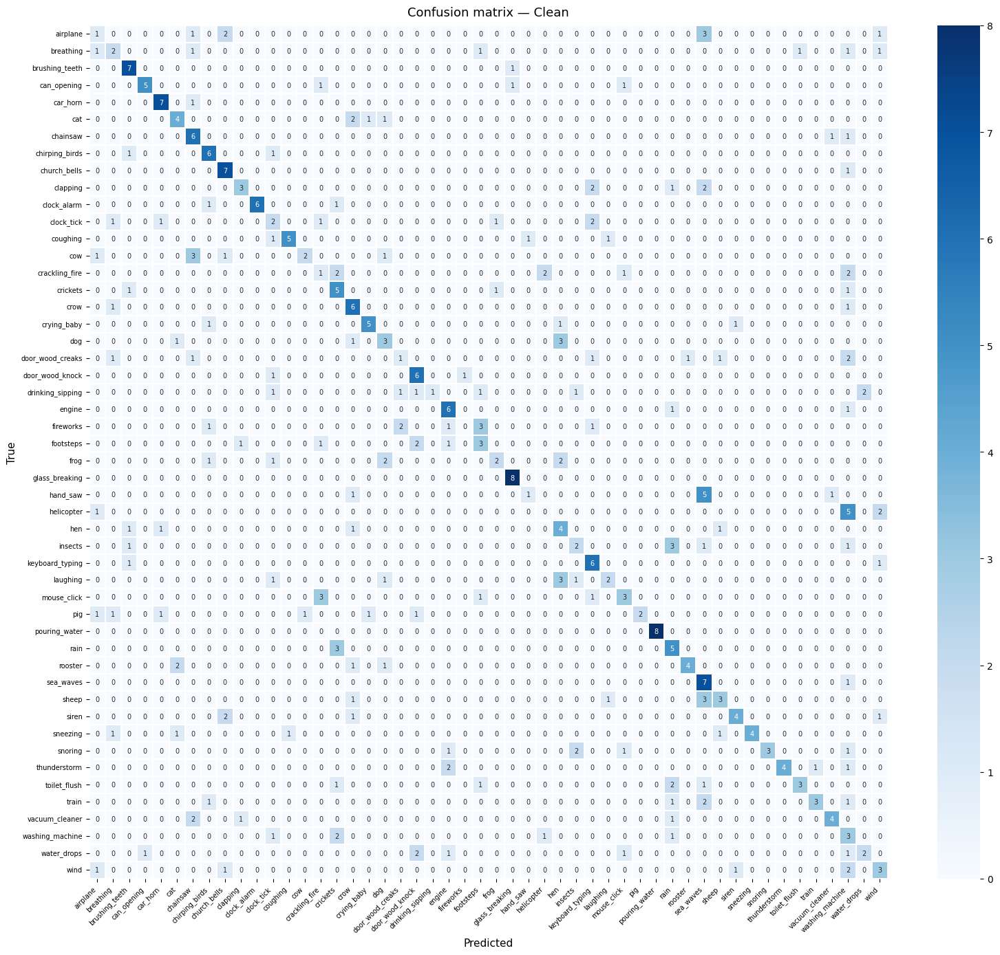

In [ ]:
def evaluate(model, X, y_int, tag):
    """
    Evaluate model on (X, y_int) where y_int contains integer class indices.
    Prints classification report and saves confusion matrix.
    """
    pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = float(np.mean(pred == y_int))
    print(f"\n{'─'*55}")
    print(f"  {tag}   accuracy = {acc:.4f}  ({acc*100:.1f} %)")
    print(f"{'─'*55}")
    print(classification_report(y_int, pred, target_names=le.classes_, zero_division=0))
    cm = confusion_matrix(y_int, pred)
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.3, annot_kws={"size": 7})
    ax.set_title(f"Confusion matrix — {tag}", fontsize=13, pad=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"cm_{tag.replace(' ', '_')}.png"), dpi=150)
    plt.show()
    return acc

acc_clean = evaluate(final_model, X_test, y_test, "Clean")

Cell 15 — Noise Injection & Robustness Evaluation (MMSE-LSA denoiser)


───────────────────────────────────────────────────────
  Clean   accuracy = 0.4750  (47.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.17      0.12      0.14         8
       breathing       0.29      0.25      0.27         8
  brushing_teeth       0.58      0.88      0.70         8
     can_opening       0.83      0.62      0.71         8
        car_horn       0.70      0.88      0.78         8
             cat       0.50      0.50      0.50         8
        chainsaw       0.40      0.75      0.52         8
  chirping_birds       0.55      0.75      0.63         8
    church_bells       0.54      0.88      0.67         8
        clapping       0.60      0.38      0.46         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       0.83      0.62      0.71         8
             cow       0.67      0.2

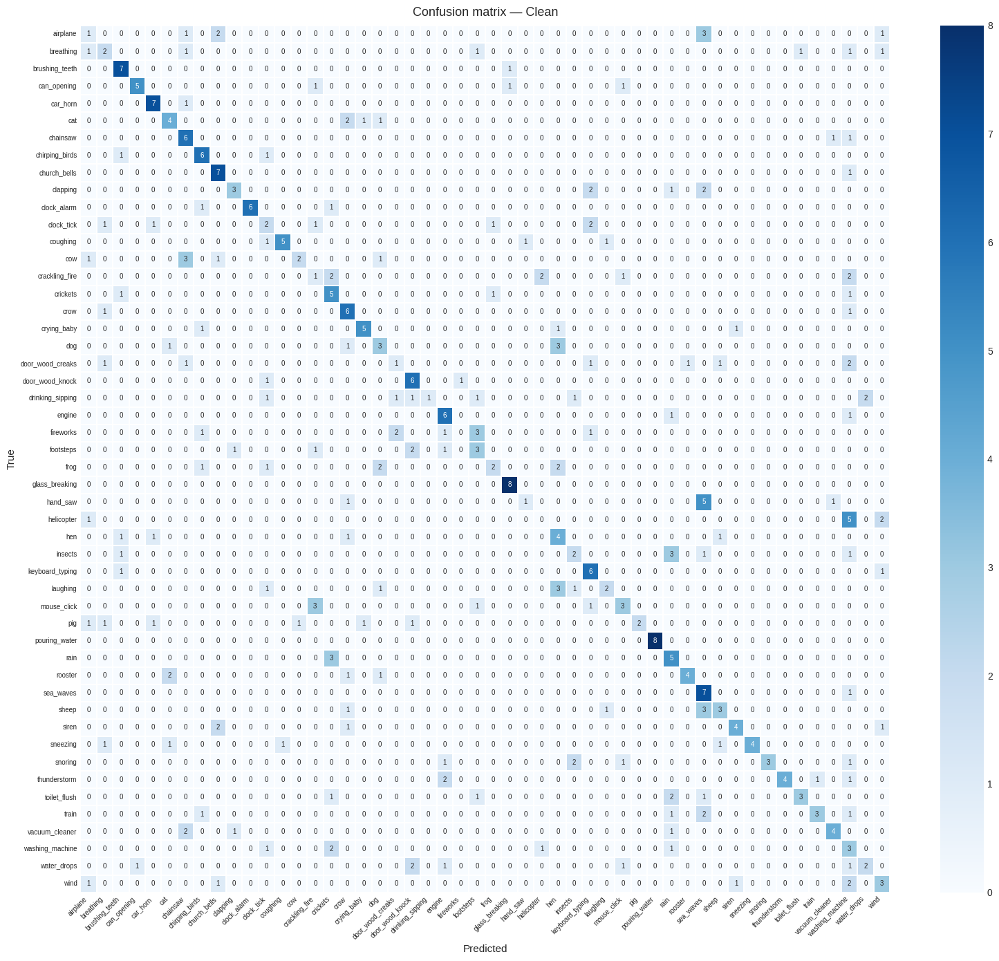


WHITE NOISE:

───────────────────────────────────────────────────────
  White Noisy 20dB   accuracy = 0.3700  (37.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.25      0.25      0.25         8
  brushing_teeth       0.53      1.00      0.70         8
     can_opening       0.50      0.12      0.20         8
        car_horn       0.55      0.75      0.63         8
             cat       0.43      0.75      0.55         8
        chainsaw       0.27      0.75      0.40         8
  chirping_birds       0.25      0.62      0.36         8
    church_bells       0.43      0.38      0.40         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.43      0.38      0.40         8
        coughing       1.00      0.25      0.40         8
           

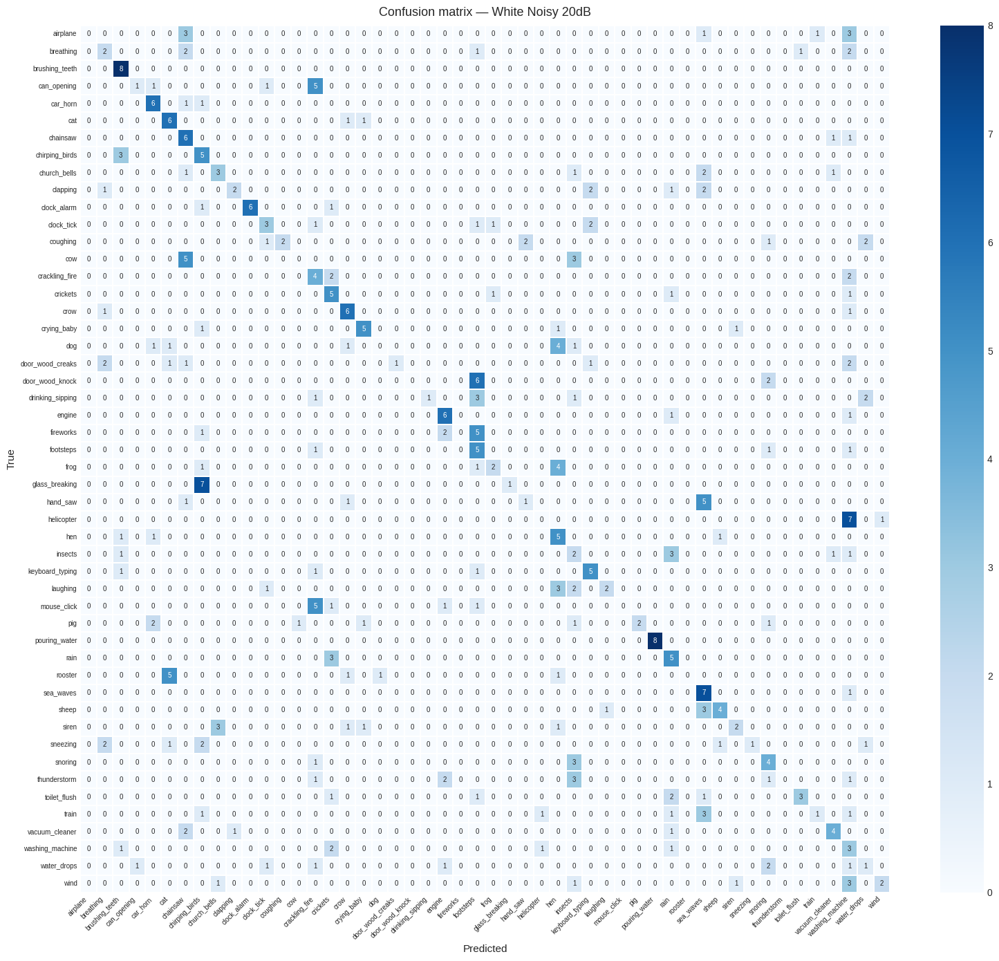


───────────────────────────────────────────────────────
  White DSP   20dB   accuracy = 0.4025  (40.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.22      0.25      0.24         8
  brushing_teeth       0.57      1.00      0.73         8
     can_opening       0.50      0.50      0.50         8
        car_horn       0.56      0.62      0.59         8
             cat       0.50      0.75      0.60         8
        chainsaw       0.40      0.75      0.52         8
  chirping_birds       0.32      0.75      0.44         8
    church_bells       0.60      0.38      0.46         8
        clapping       0.56      0.62      0.59         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.25      0.50      0.33         8
        coughing       0.83      0.62      0.71         8
             cow       0.

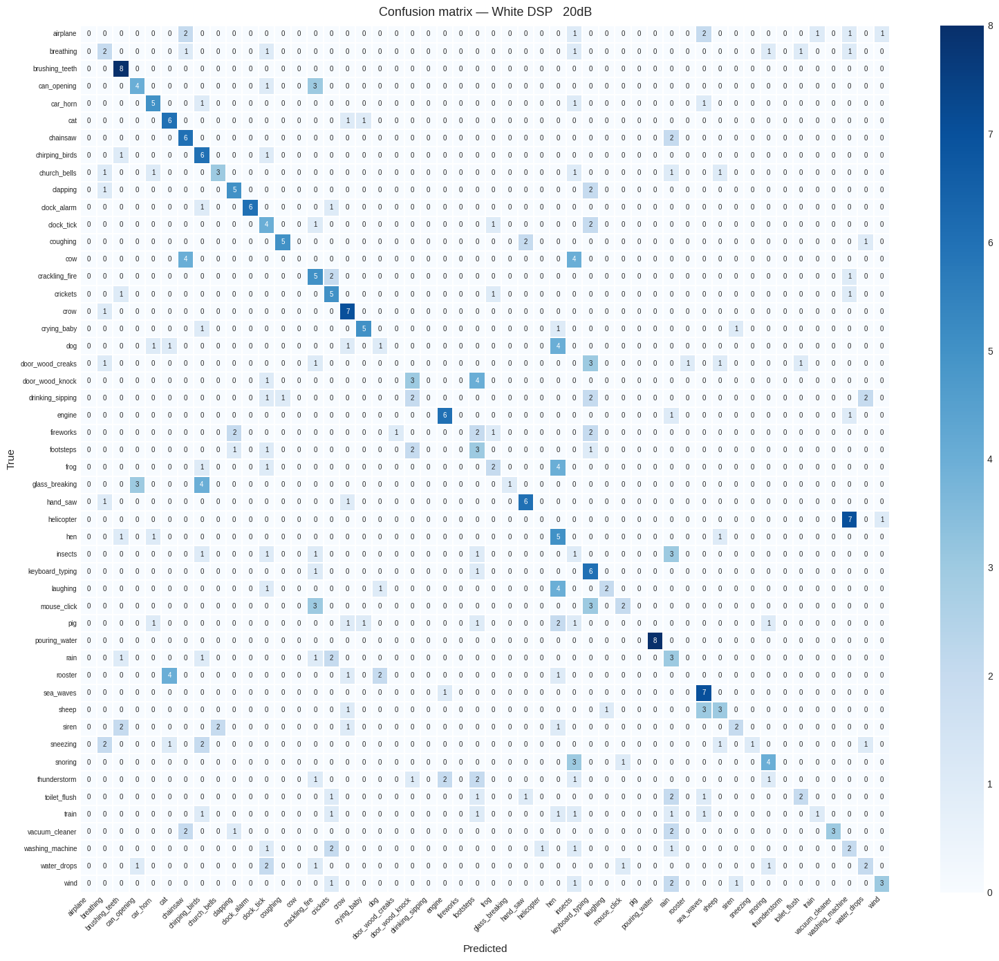

   20dB | Noisy: 37.0% → DSP: 40.2%

───────────────────────────────────────────────────────
  White Noisy 15dB   accuracy = 0.3300  (33.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.33      0.25      0.29         8
  brushing_teeth       0.33      0.88      0.48         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.56      0.62      0.59         8
             cat       0.45      0.62      0.53         8
        chainsaw       0.19      0.62      0.29         8
  chirping_birds       0.14      0.62      0.23         8
    church_bells       1.00      0.12      0.22         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.50      0.12      0.20         8
        coughing       0.00      0.00      0.00

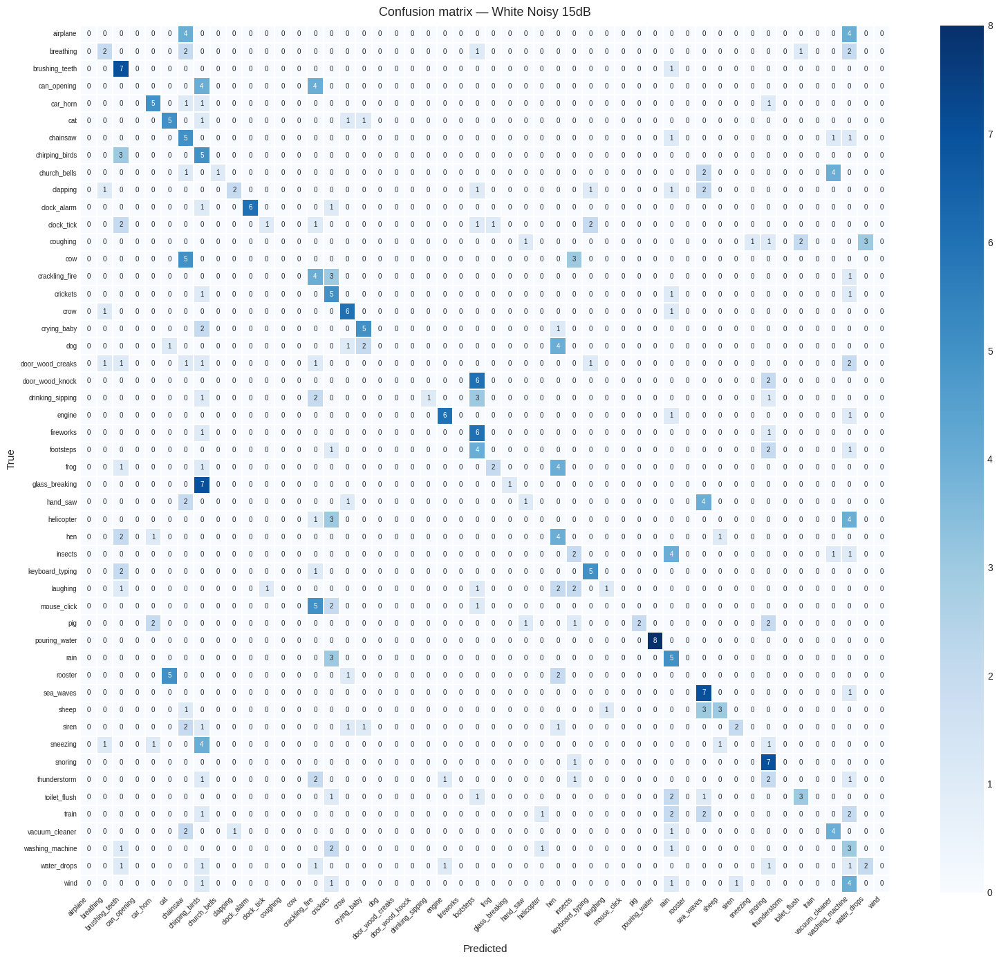


───────────────────────────────────────────────────────
  White DSP   15dB   accuracy = 0.3775  (37.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.33      0.38      0.35         8
  brushing_teeth       0.36      1.00      0.53         8
     can_opening       0.67      0.25      0.36         8
        car_horn       0.62      0.62      0.62         8
             cat       0.46      0.75      0.57         8
        chainsaw       0.28      0.62      0.38         8
  chirping_birds       0.16      0.62      0.25         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.57      0.50      0.53         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       1.00      0.50      0.67         8
             cow       0.

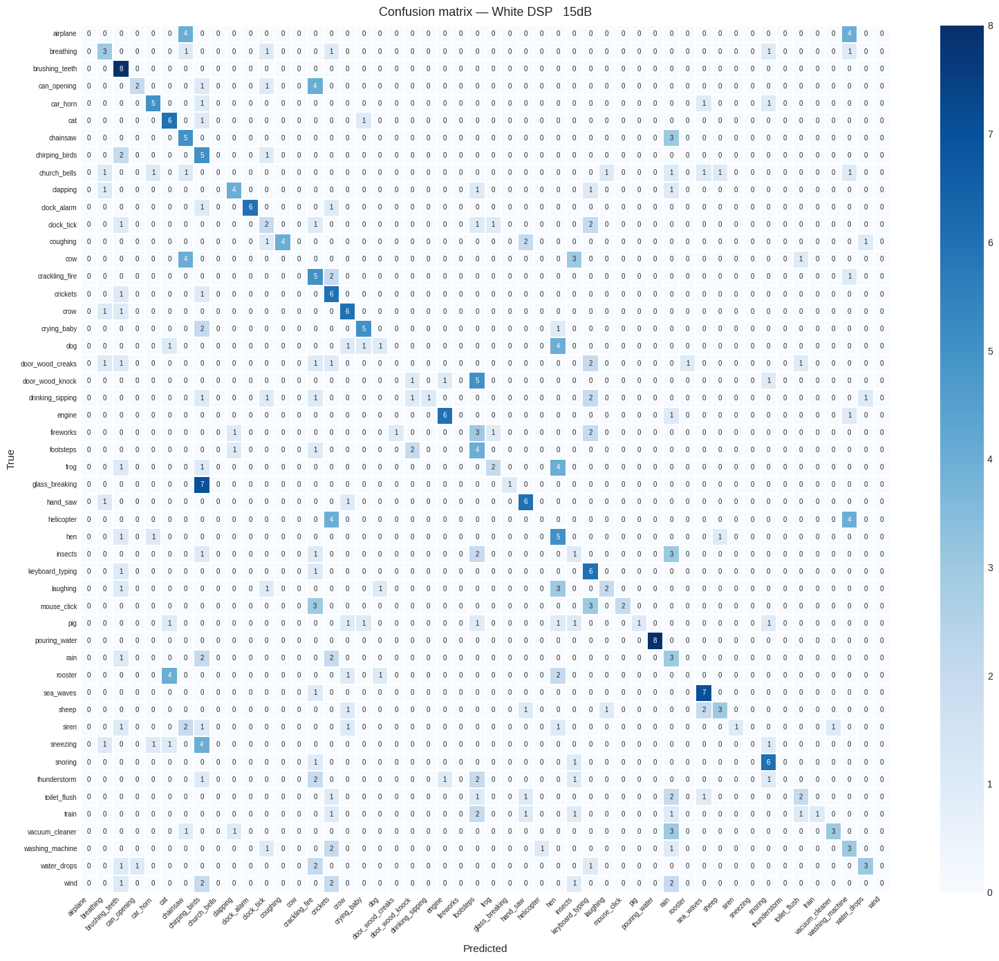

   15dB | Noisy: 33.0% → DSP: 37.8%

───────────────────────────────────────────────────────
  White Noisy 10dB   accuracy = 0.2325  (23.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.20      0.25      0.22         8
  brushing_teeth       0.26      0.75      0.39         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.71      0.62      0.67         8
             cat       0.33      0.25      0.29         8
        chainsaw       0.17      0.62      0.26         8
  chirping_birds       0.09      0.62      0.16         8
    church_bells       0.00      0.00      0.00         8
        clapping       1.00      0.25      0.40         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00

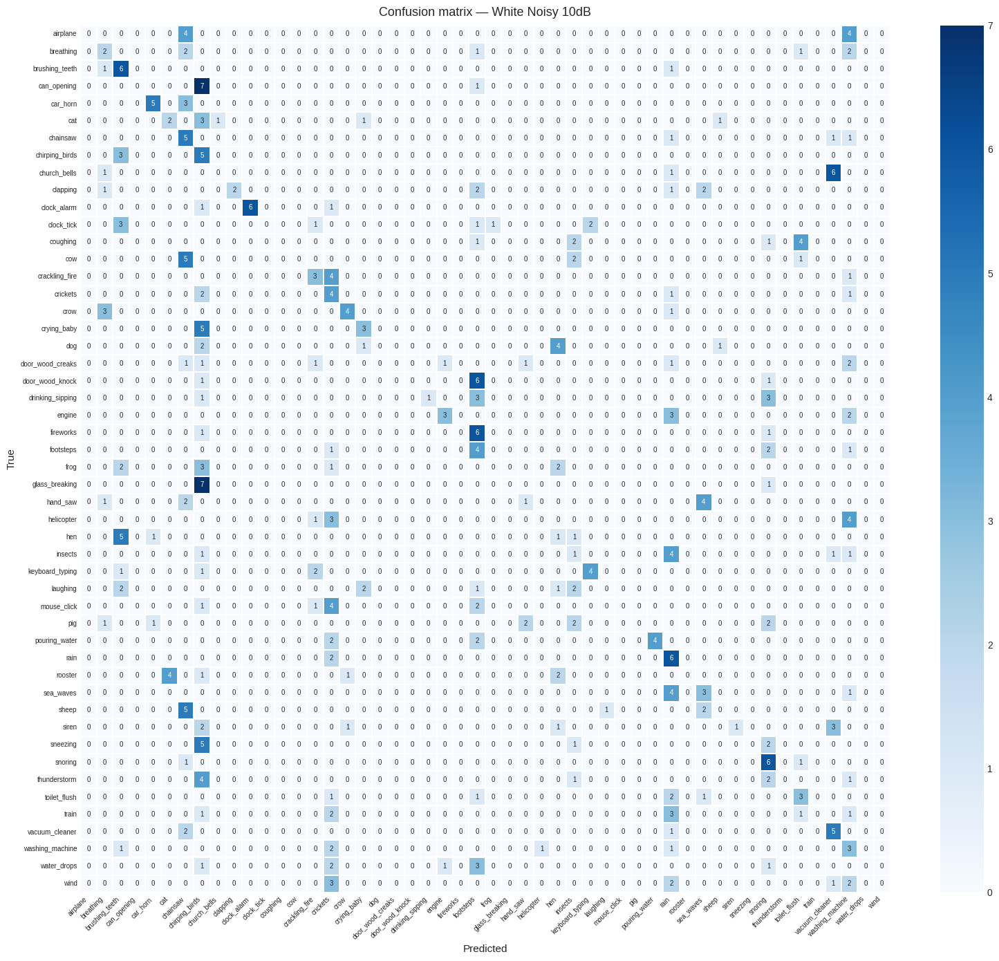


───────────────────────────────────────────────────────
  White DSP   10dB   accuracy = 0.2850  (28.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.29      0.25      0.27         8
  brushing_teeth       0.32      0.88      0.47         8
     can_opening       0.50      0.12      0.20         8
        car_horn       0.67      0.75      0.71         8
             cat       0.36      0.50      0.42         8
        chainsaw       0.24      0.62      0.34         8
  chirping_birds       0.20      0.88      0.33         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.50      0.12      0.20         8
     clock_alarm       1.00      0.50      0.67         8
      clock_tick       0.11      0.12      0.12         8
        coughing       1.00      0.25      0.40         8
             cow       0.

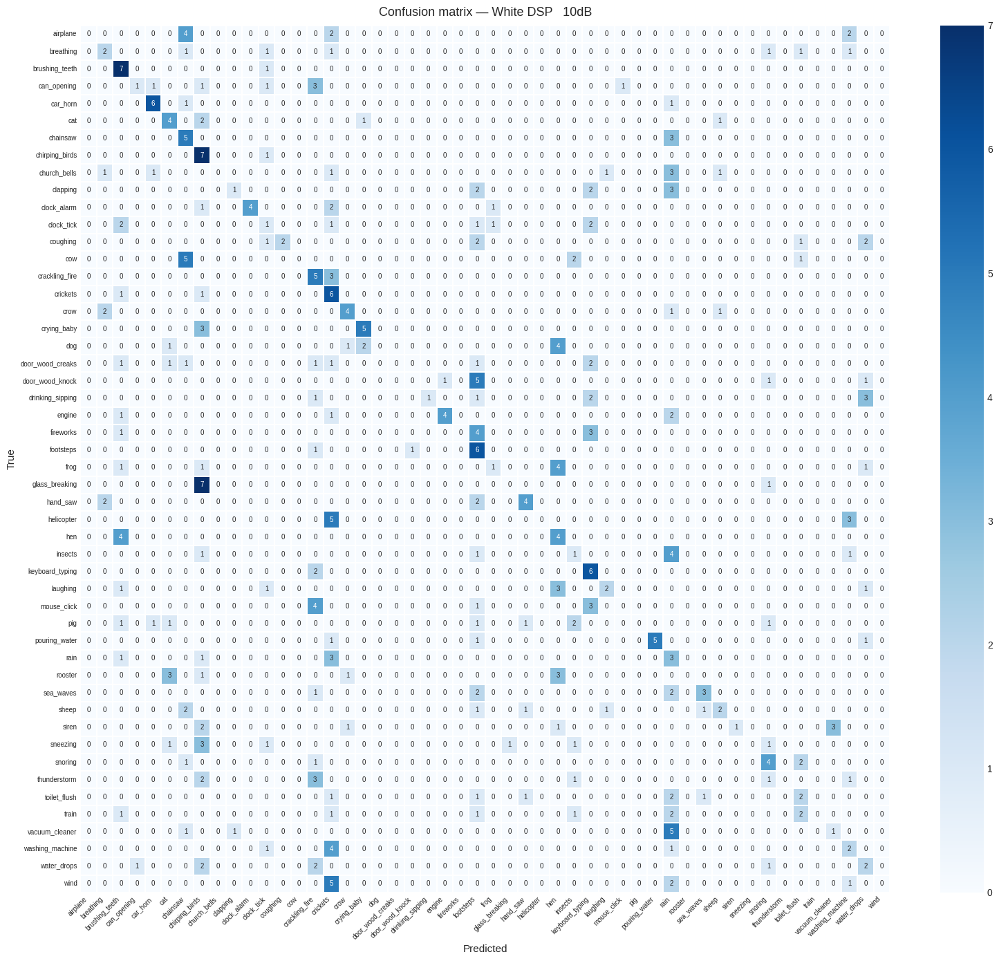

   10dB | Noisy: 23.2% → DSP: 28.5%

───────────────────────────────────────────────────────
  White Noisy 5dB   accuracy = 0.1600  (16.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.09      0.12      0.11         8
  brushing_teeth       0.18      0.75      0.29         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.75      0.38      0.50         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.09      0.62      0.16         8
  chirping_birds       0.12      0.38      0.18         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       1.00      0.62      0.77         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00 

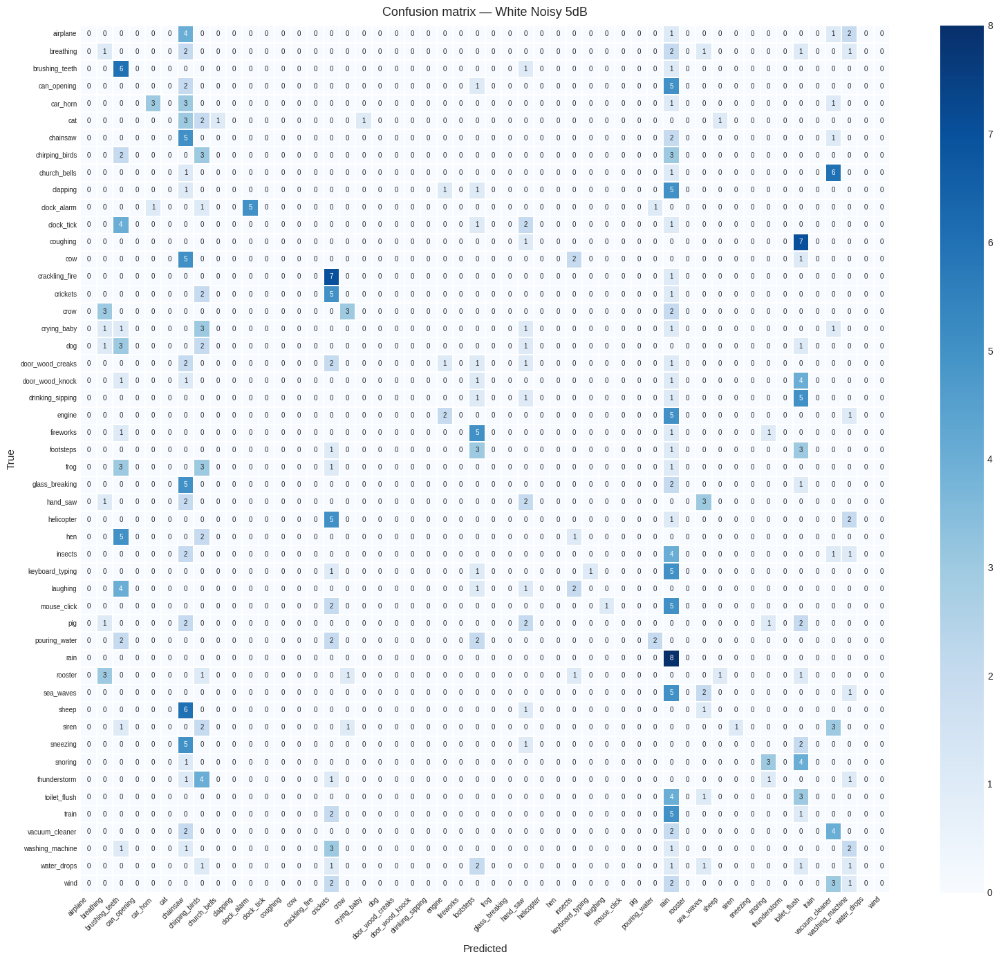


───────────────────────────────────────────────────────
  White DSP   5dB   accuracy = 0.2275  (22.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.17      0.12      0.14         8
  brushing_teeth       0.24      1.00      0.39         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.25      0.33         8
             cat       0.25      0.12      0.17         8
        chainsaw       0.17      0.38      0.23         8
  chirping_birds       0.13      0.88      0.22         8
    church_bells       0.00      0.00      0.00         8
        clapping       1.00      0.12      0.22         8
     clock_alarm       1.00      0.38      0.55         8
      clock_tick       0.67      0.25      0.36         8
        coughing       1.00      0.12      0.22         8
             cow       0.0

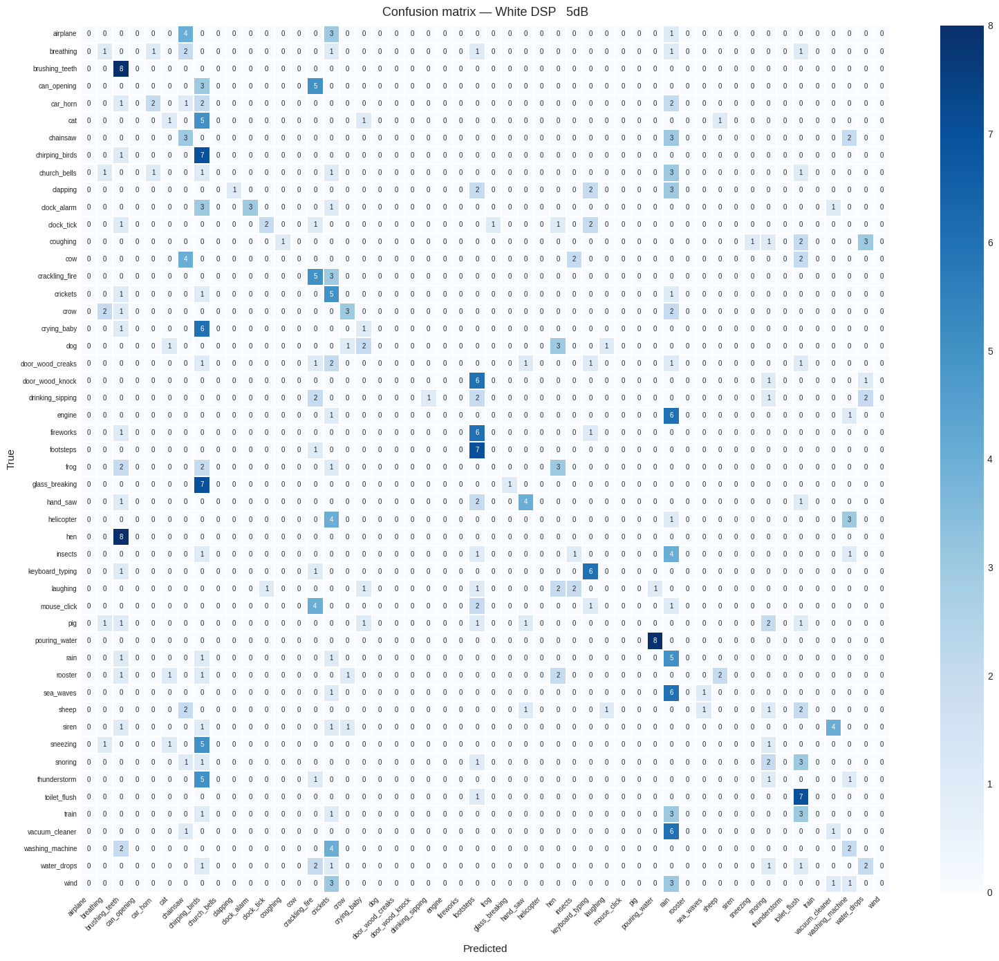

    5dB | Noisy: 16.0% → DSP: 22.8%

───────────────────────────────────────────────────────
  White Noisy 0dB   accuracy = 0.1000  (10.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.10      0.12      0.11         8
  brushing_teeth       0.12      0.62      0.20         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.36      0.50      0.42         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.09      0.62      0.16         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.43      0.38      0.40         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00 

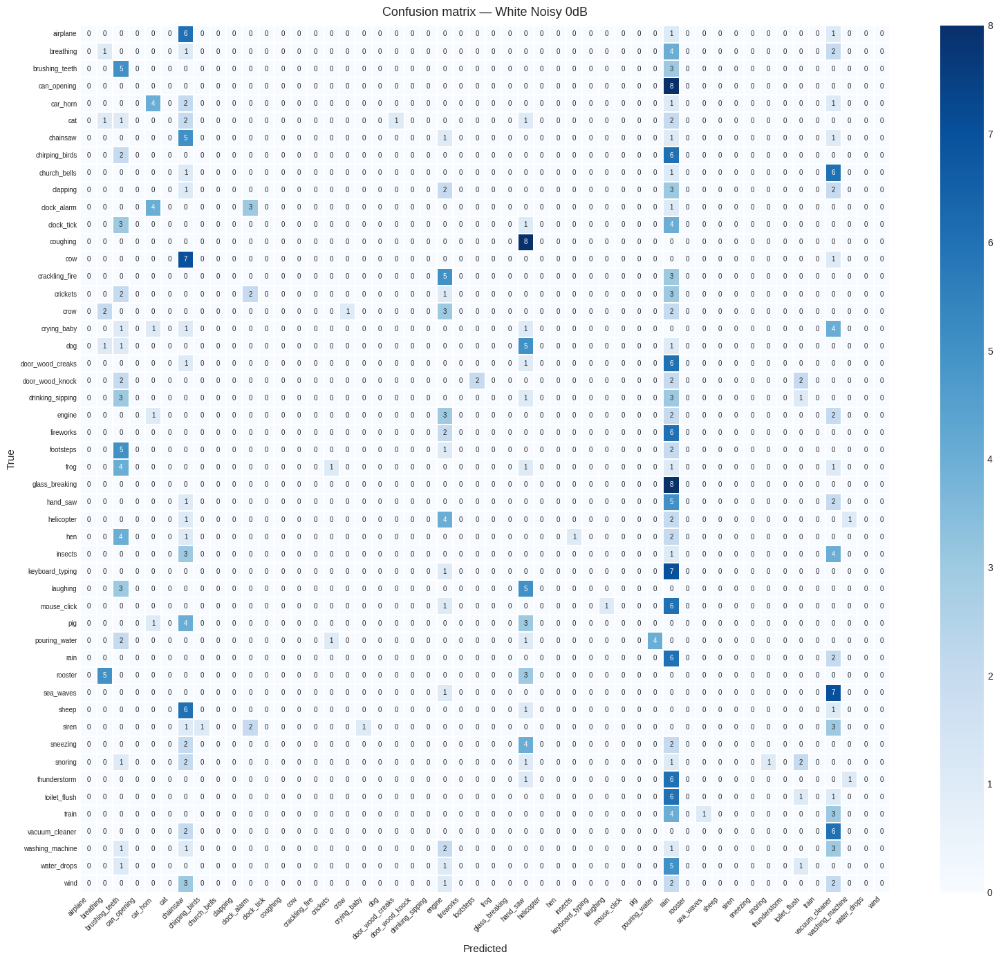


───────────────────────────────────────────────────────
  White DSP   0dB   accuracy = 0.1475  (14.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.20      0.25      0.22         8
  brushing_teeth       0.20      0.88      0.33         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.06      0.12      0.08         8
  chirping_birds       0.12      1.00      0.22         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.00      0.00      0.00         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0.0

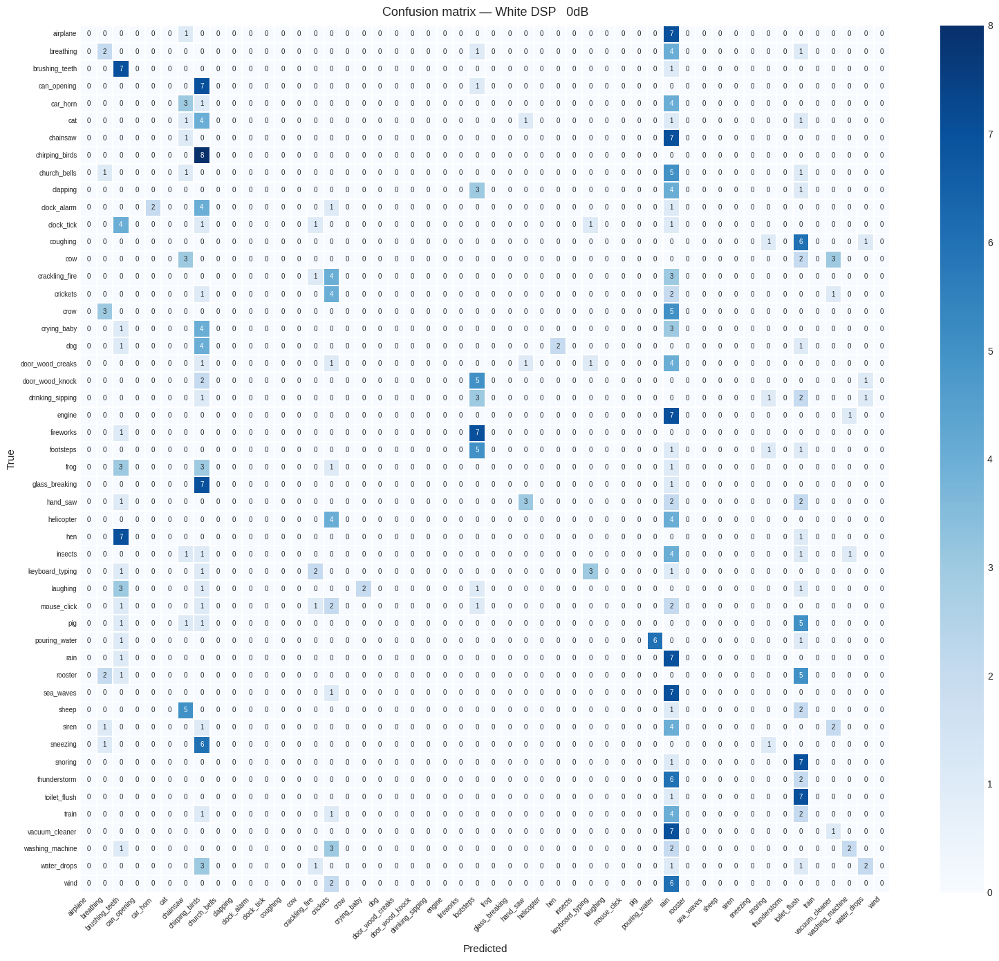

    0dB | Noisy: 10.0% → DSP: 14.8%

GAUSSIAN NOISE:

───────────────────────────────────────────────────────
  Gaussian Noisy 20dB   accuracy = 0.3700  (37.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.25      0.25      0.25         8
  brushing_teeth       0.50      1.00      0.67         8
     can_opening       0.50      0.12      0.20         8
        car_horn       0.55      0.75      0.63         8
             cat       0.43      0.75      0.55         8
        chainsaw       0.27      0.75      0.40         8
  chirping_birds       0.25      0.62      0.36         8
    church_bells       0.43      0.38      0.40         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.43      0.38      0.40         8
        coughing       1.00

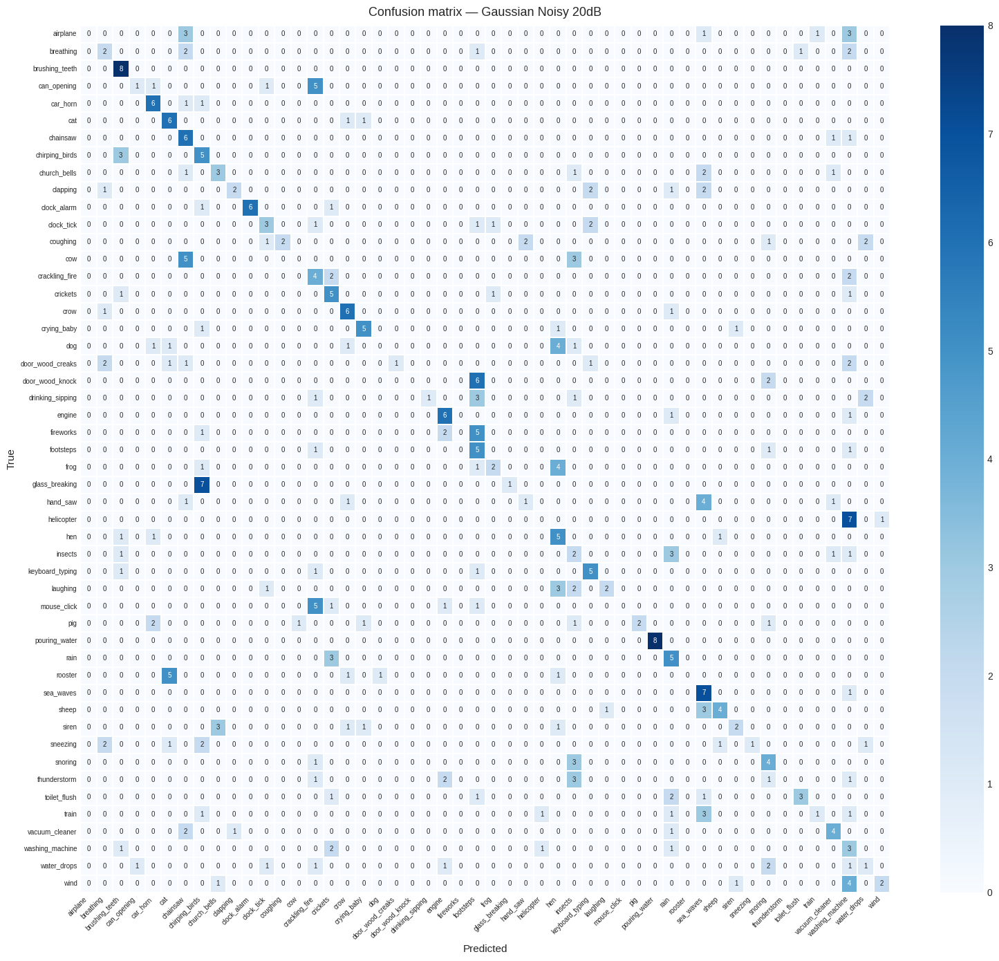


───────────────────────────────────────────────────────
  Gaussian DSP   20dB   accuracy = 0.4075  (40.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.20      0.25      0.22         8
  brushing_teeth       0.57      1.00      0.73         8
     can_opening       0.50      0.50      0.50         8
        car_horn       0.50      0.62      0.56         8
             cat       0.54      0.88      0.67         8
        chainsaw       0.40      0.75      0.52         8
  chirping_birds       0.30      0.75      0.43         8
    church_bells       0.60      0.38      0.46         8
        clapping       0.56      0.62      0.59         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.25      0.50      0.33         8
        coughing       1.00      0.62      0.77         8
             cow      

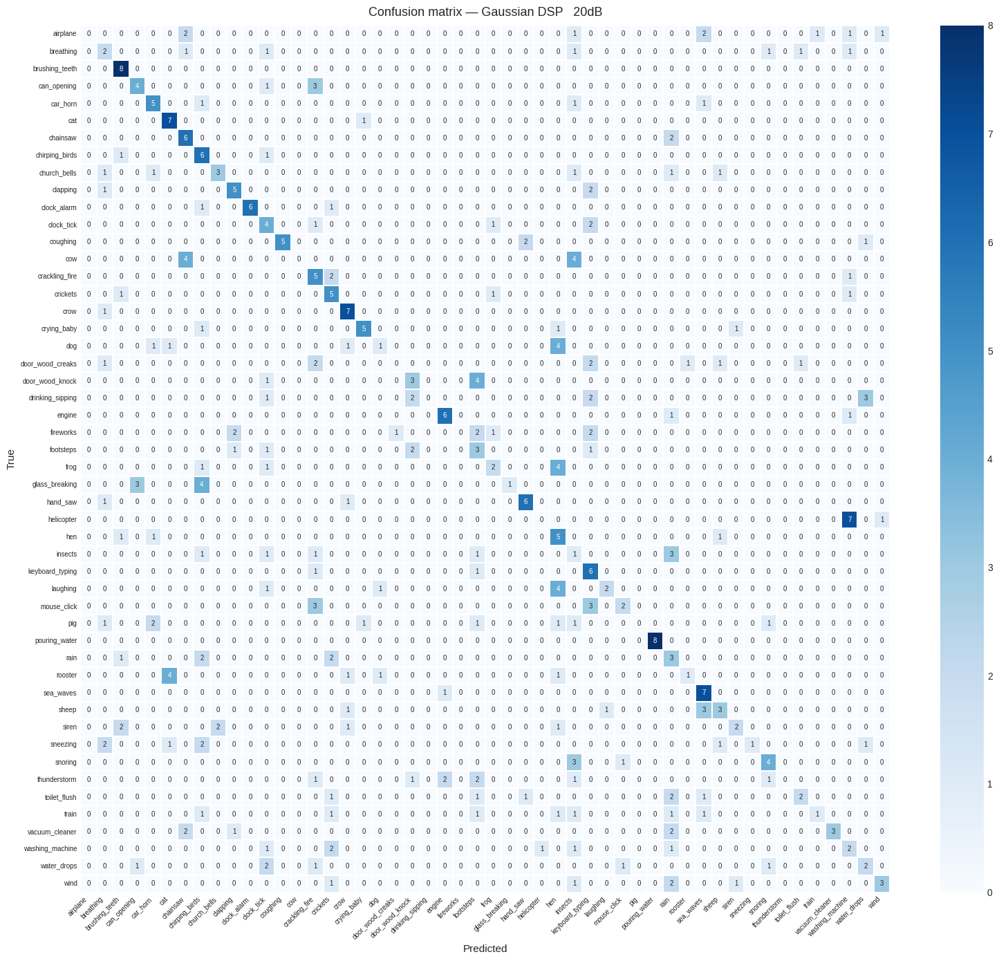

   20dB | Noisy: 37.0% → DSP: 40.8%

───────────────────────────────────────────────────────
  Gaussian Noisy 15dB   accuracy = 0.3275  (32.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.33      0.25      0.29         8
  brushing_teeth       0.33      0.88      0.48         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.56      0.62      0.59         8
             cat       0.45      0.62      0.53         8
        chainsaw       0.19      0.62      0.29         8
  chirping_birds       0.14      0.62      0.23         8
    church_bells       1.00      0.12      0.22         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.50      0.12      0.20         8
        coughing       0.00      0.00      0

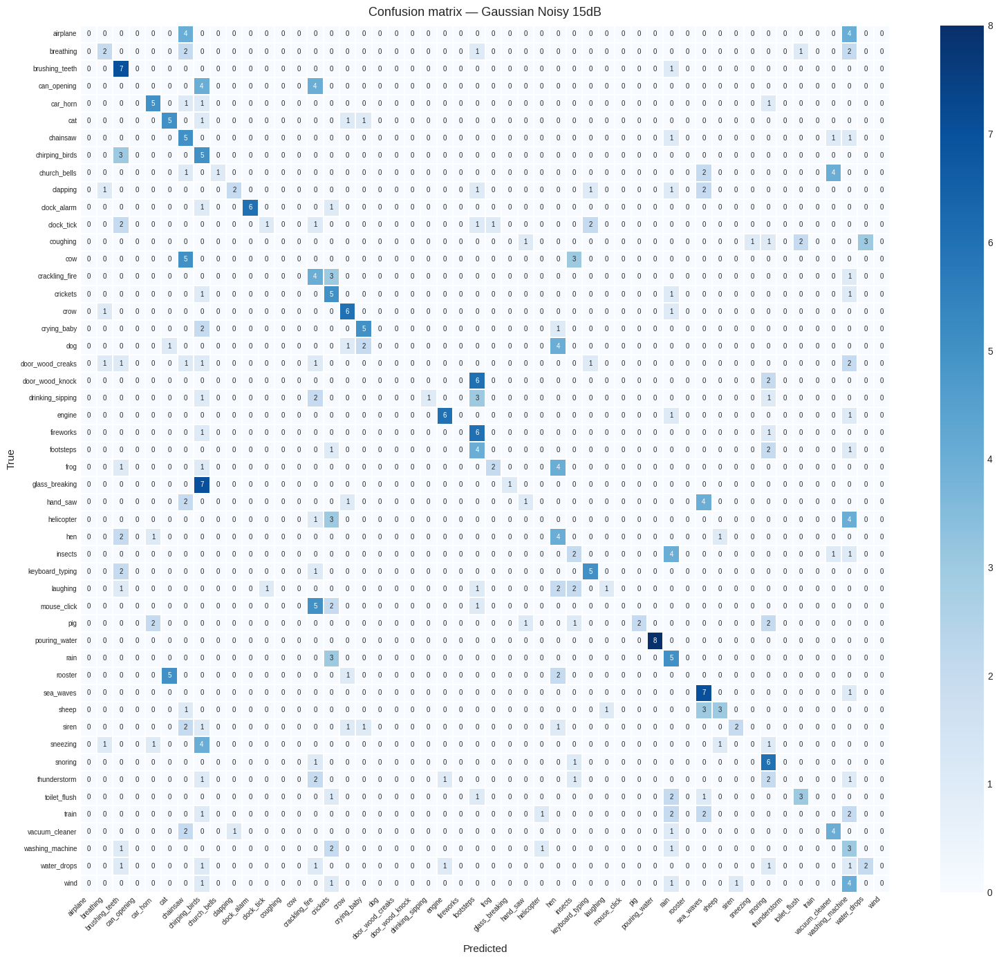


───────────────────────────────────────────────────────
  Gaussian DSP   15dB   accuracy = 0.3750  (37.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.38      0.38      0.38         8
  brushing_teeth       0.36      1.00      0.53         8
     can_opening       0.67      0.25      0.36         8
        car_horn       0.62      0.62      0.62         8
             cat       0.46      0.75      0.57         8
        chainsaw       0.29      0.62      0.40         8
  chirping_birds       0.16      0.62      0.26         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.67      0.50      0.57         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       1.00      0.50      0.67         8
             cow      

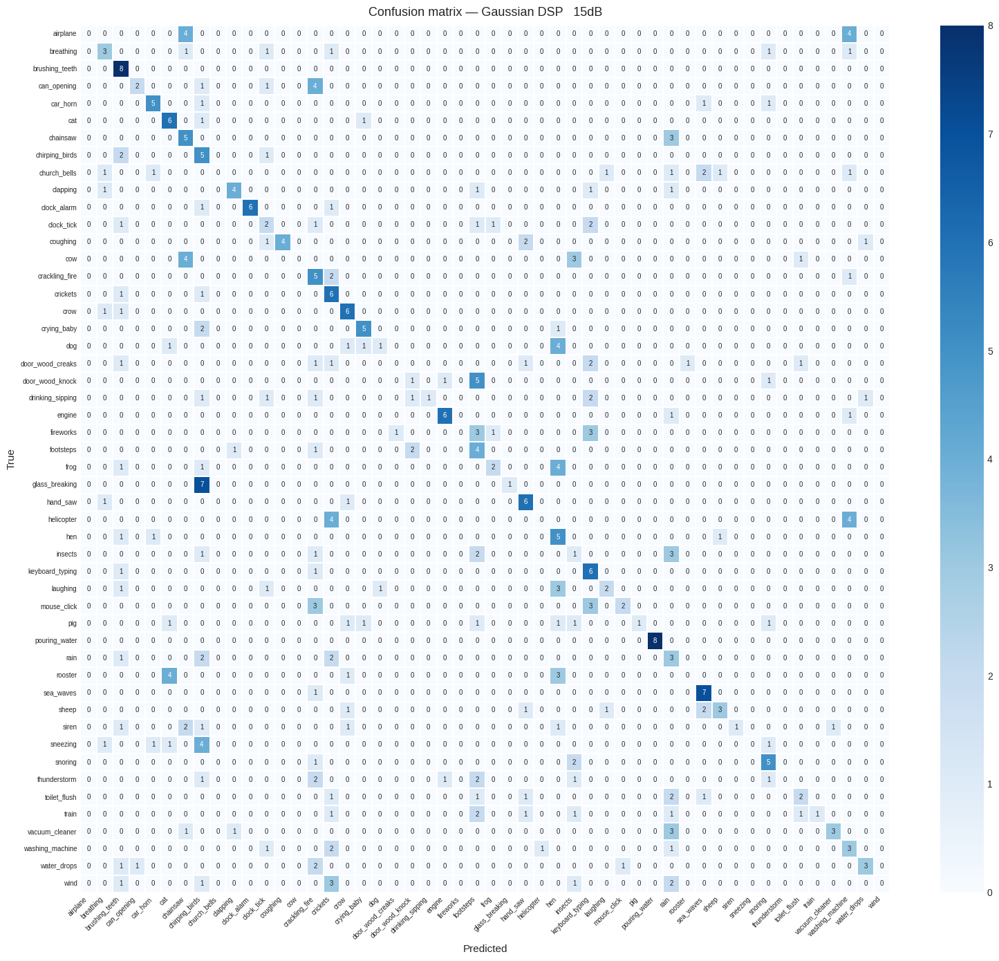

   15dB | Noisy: 32.8% → DSP: 37.5%

───────────────────────────────────────────────────────
  Gaussian Noisy 10dB   accuracy = 0.2325  (23.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.20      0.25      0.22         8
  brushing_teeth       0.25      0.75      0.38         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.71      0.62      0.67         8
             cat       0.33      0.25      0.29         8
        chainsaw       0.17      0.62      0.26         8
  chirping_birds       0.09      0.62      0.15         8
    church_bells       0.00      0.00      0.00         8
        clapping       1.00      0.12      0.22         8
     clock_alarm       1.00      0.62      0.77         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0

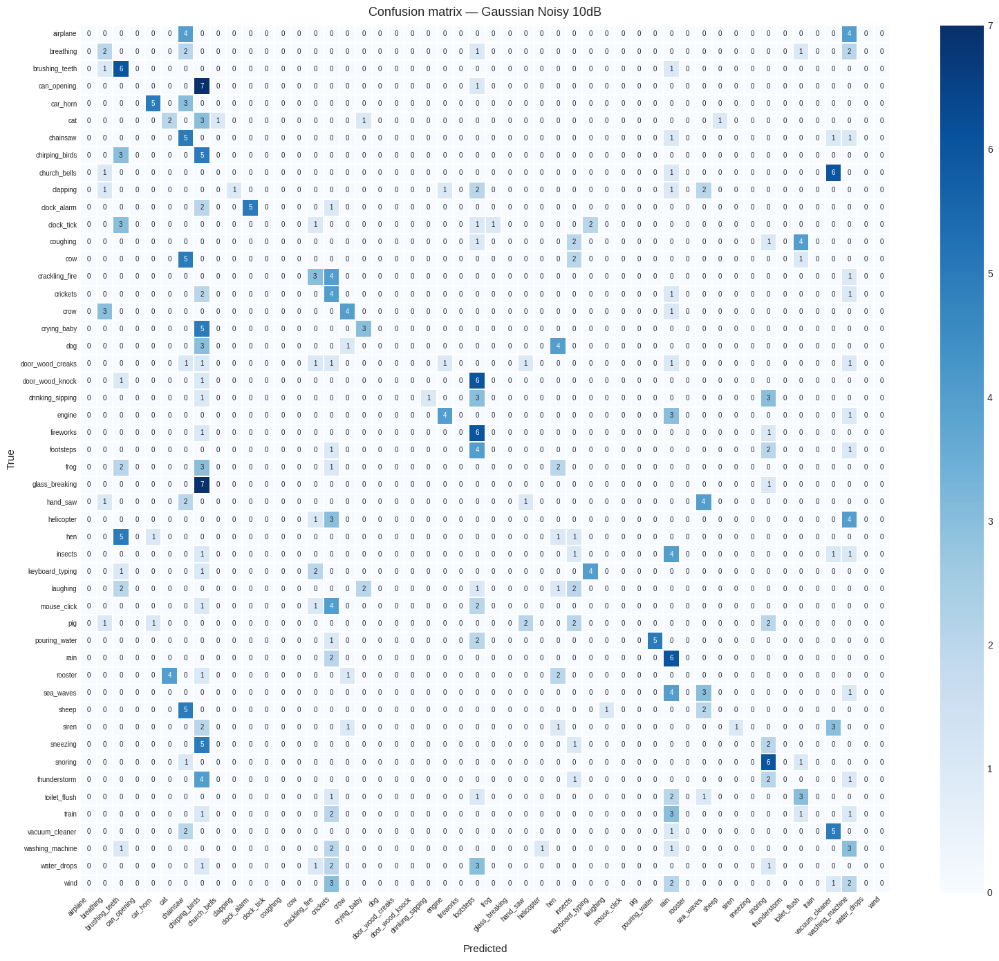


───────────────────────────────────────────────────────
  Gaussian DSP   10dB   accuracy = 0.2900  (29.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.25      0.25      0.25         8
  brushing_teeth       0.32      0.88      0.47         8
     can_opening       0.50      0.12      0.20         8
        car_horn       0.67      0.75      0.71         8
             cat       0.40      0.50      0.44         8
        chainsaw       0.25      0.62      0.36         8
  chirping_birds       0.19      0.88      0.31         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.50      0.12      0.20         8
     clock_alarm       1.00      0.50      0.67         8
      clock_tick       0.11      0.12      0.12         8
        coughing       1.00      0.25      0.40         8
             cow      

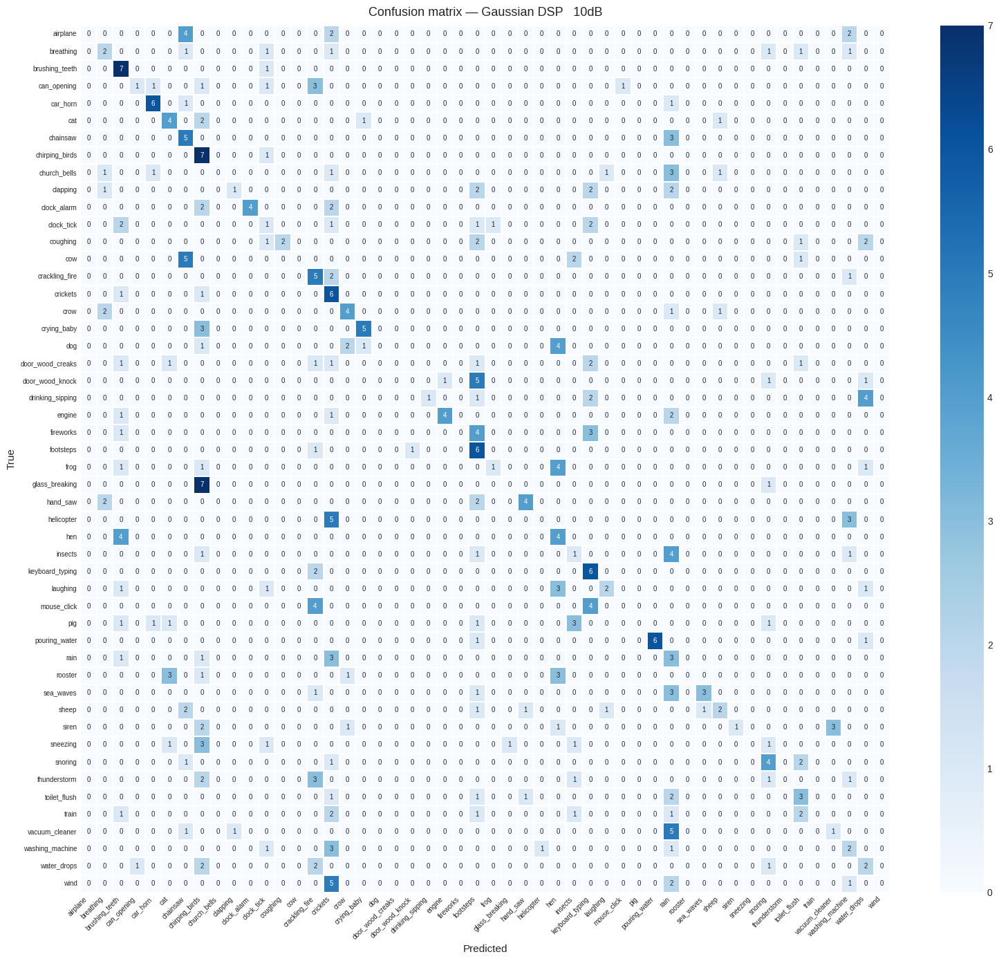

   10dB | Noisy: 23.2% → DSP: 29.0%

───────────────────────────────────────────────────────
  Gaussian Noisy 5dB   accuracy = 0.1625  (16.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.10      0.12      0.11         8
  brushing_teeth       0.19      0.75      0.31         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.60      0.38      0.46         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.09      0.62      0.16         8
  chirping_birds       0.11      0.38      0.17         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       1.00      0.62      0.77         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.

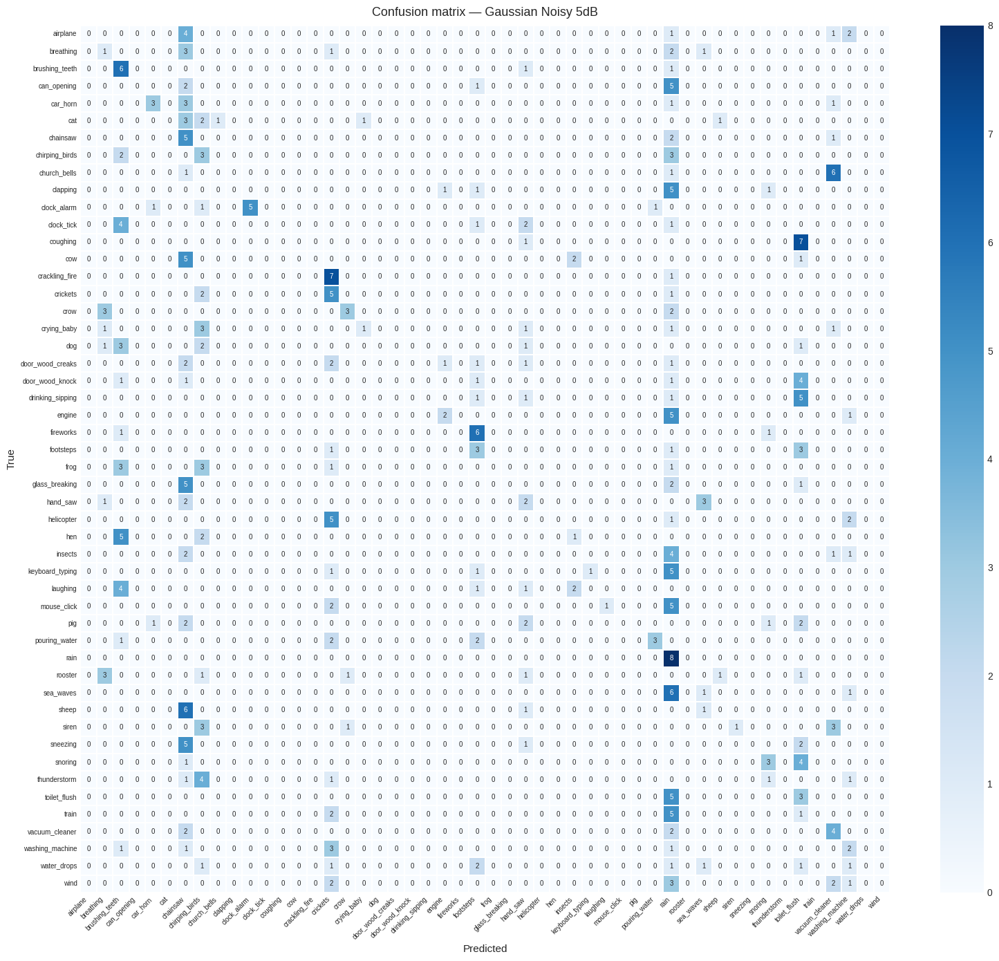


───────────────────────────────────────────────────────
  Gaussian DSP   5dB   accuracy = 0.2200  (22.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.17      0.12      0.14         8
  brushing_teeth       0.22      1.00      0.36         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.25      0.33         8
             cat       0.20      0.12      0.15         8
        chainsaw       0.19      0.38      0.25         8
  chirping_birds       0.12      0.88      0.22         8
    church_bells       0.00      0.00      0.00         8
        clapping       1.00      0.12      0.22         8
     clock_alarm       1.00      0.38      0.55         8
      clock_tick       0.50      0.25      0.33         8
        coughing       0.00      0.00      0.00         8
             cow       

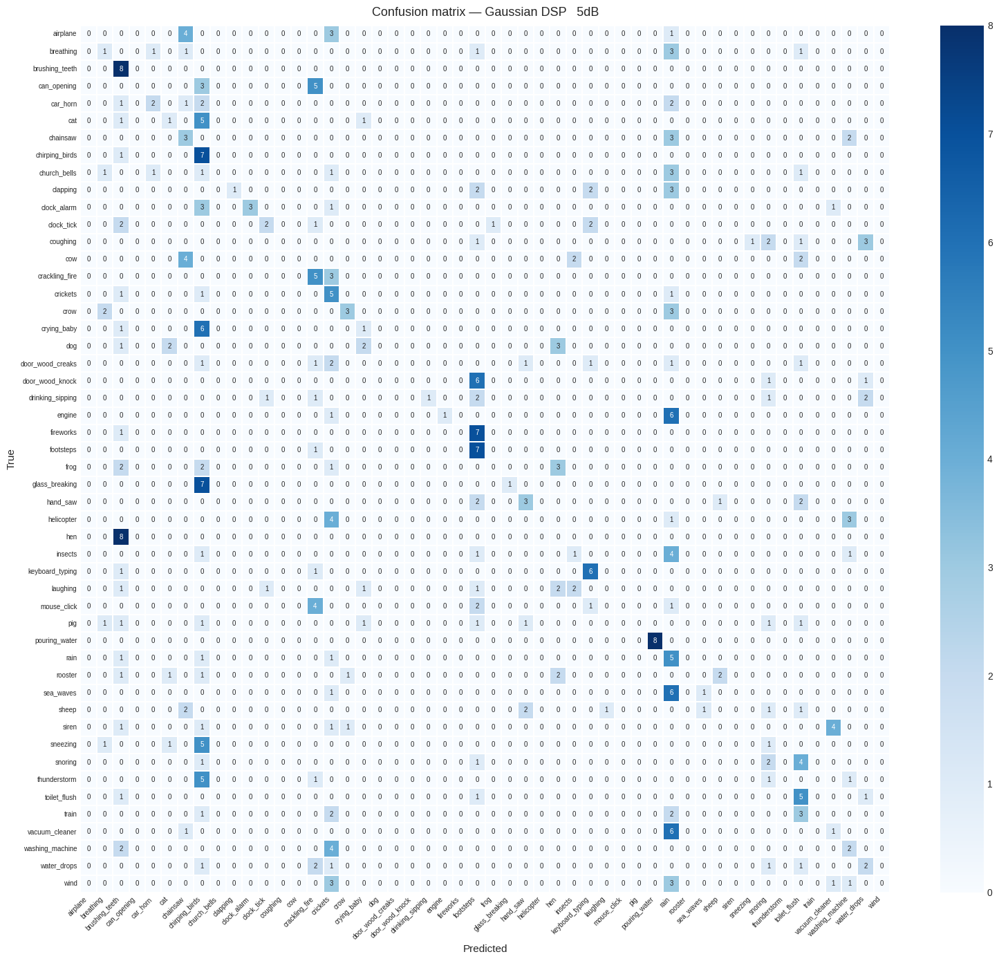

    5dB | Noisy: 16.2% → DSP: 22.0%

───────────────────────────────────────────────────────
  Gaussian Noisy 0dB   accuracy = 0.1025  (10.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.09      0.50      0.16         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.40      0.50      0.44         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.10      0.62      0.18         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.50      0.50      0.50         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.

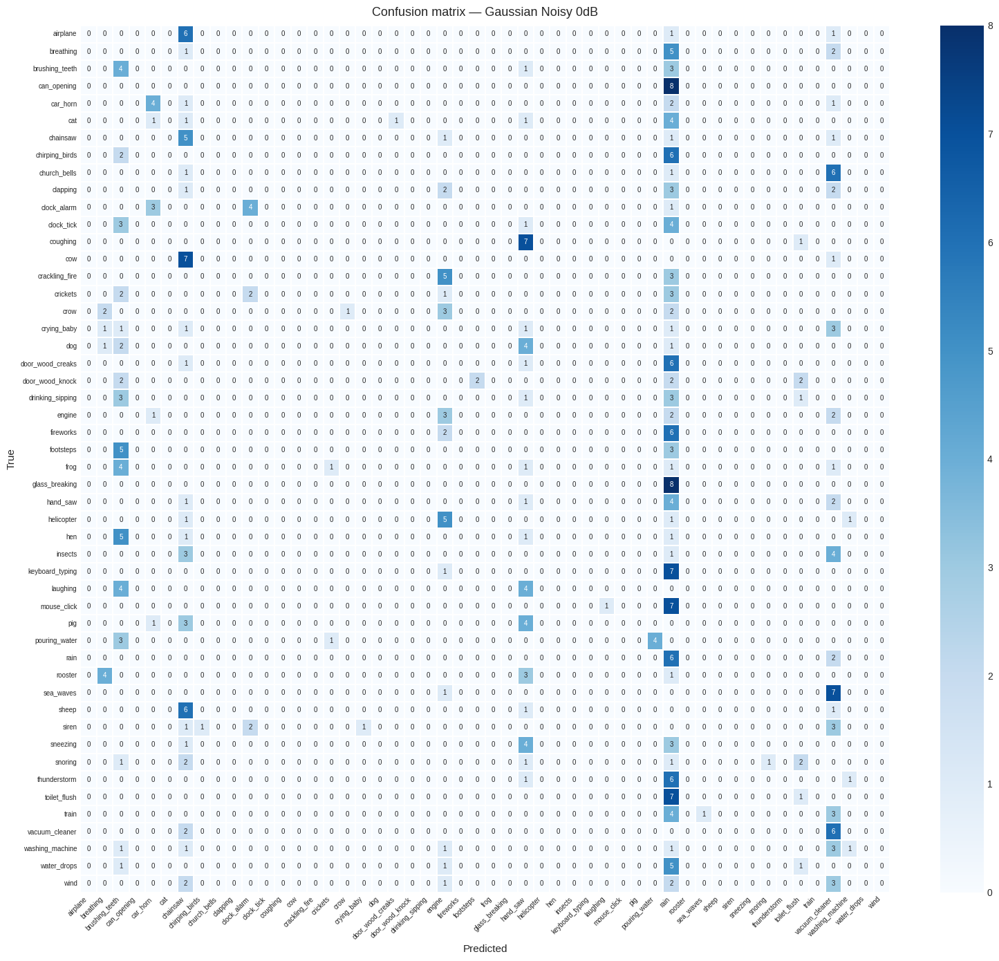


───────────────────────────────────────────────────────
  Gaussian DSP   0dB   accuracy = 0.1475  (14.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.22      0.25      0.24         8
  brushing_teeth       0.18      0.88      0.30         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.08      0.12      0.10         8
  chirping_birds       0.13      1.00      0.24         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.00      0.00      0.00         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       

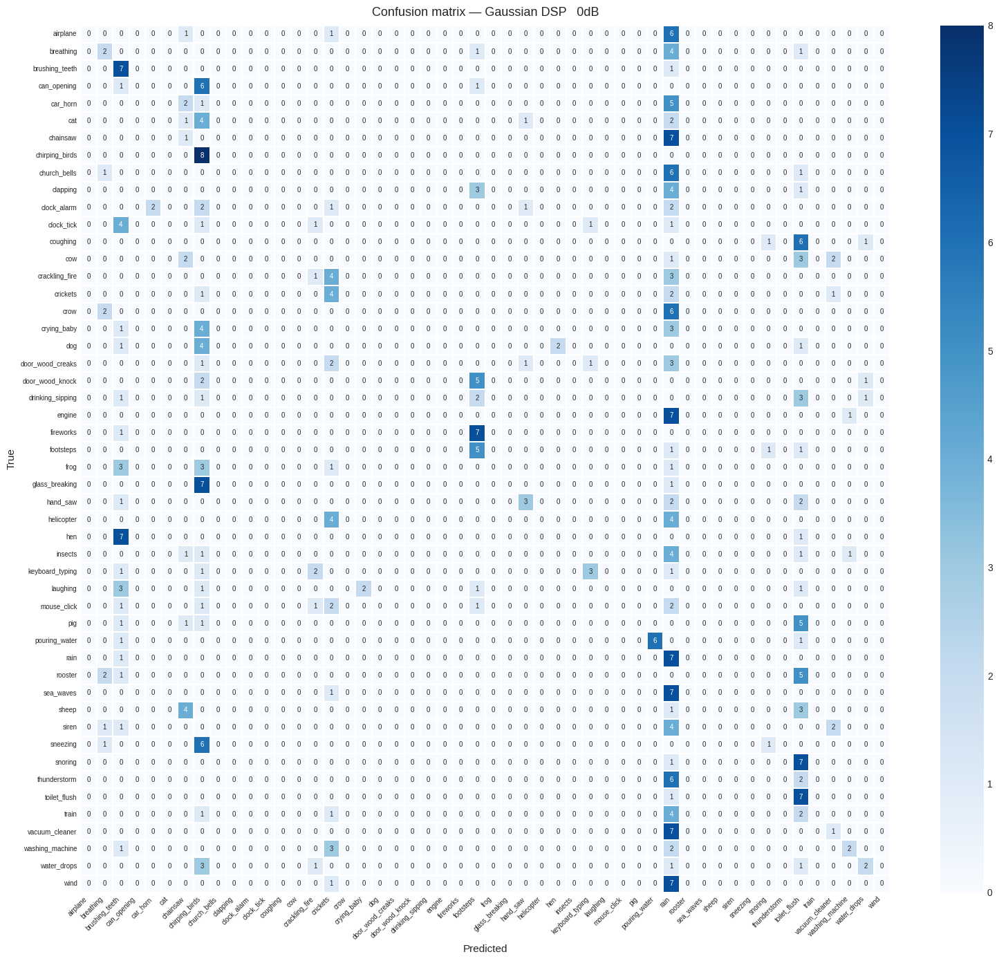

    0dB | Noisy: 10.2% → DSP: 14.8%

LOW SNR:

───────────────────────────────────────────────────────
  Low SNR Noisy 0dB   accuracy = 0.1000  (10.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.11      0.50      0.17         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.44      0.50      0.47         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.10      0.62      0.17         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.33      0.25      0.29         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.0

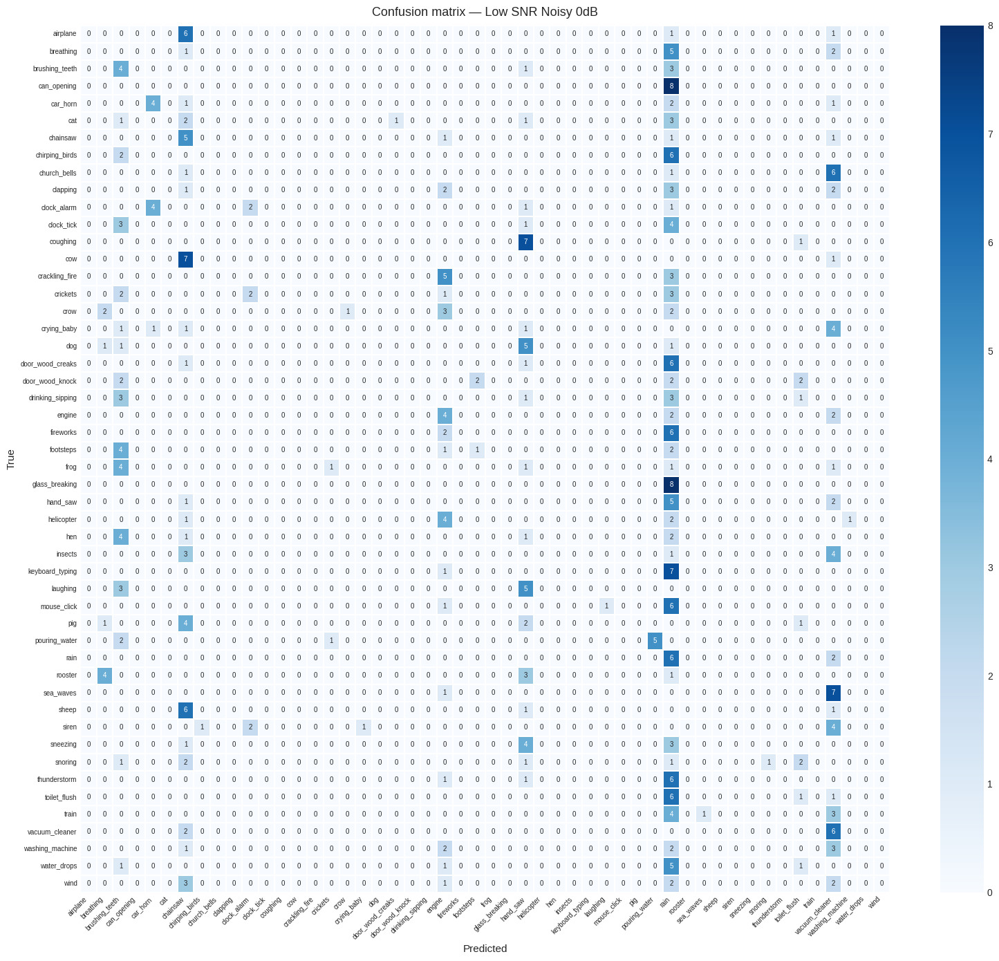


───────────────────────────────────────────────────────
  Low SNR DSP   0dB   accuracy = 0.1450  (14.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.20      0.25      0.22         8
  brushing_teeth       0.19      0.88      0.32         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.08      0.12      0.10         8
  chirping_birds       0.13      1.00      0.23         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.00      0.00      0.00         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0

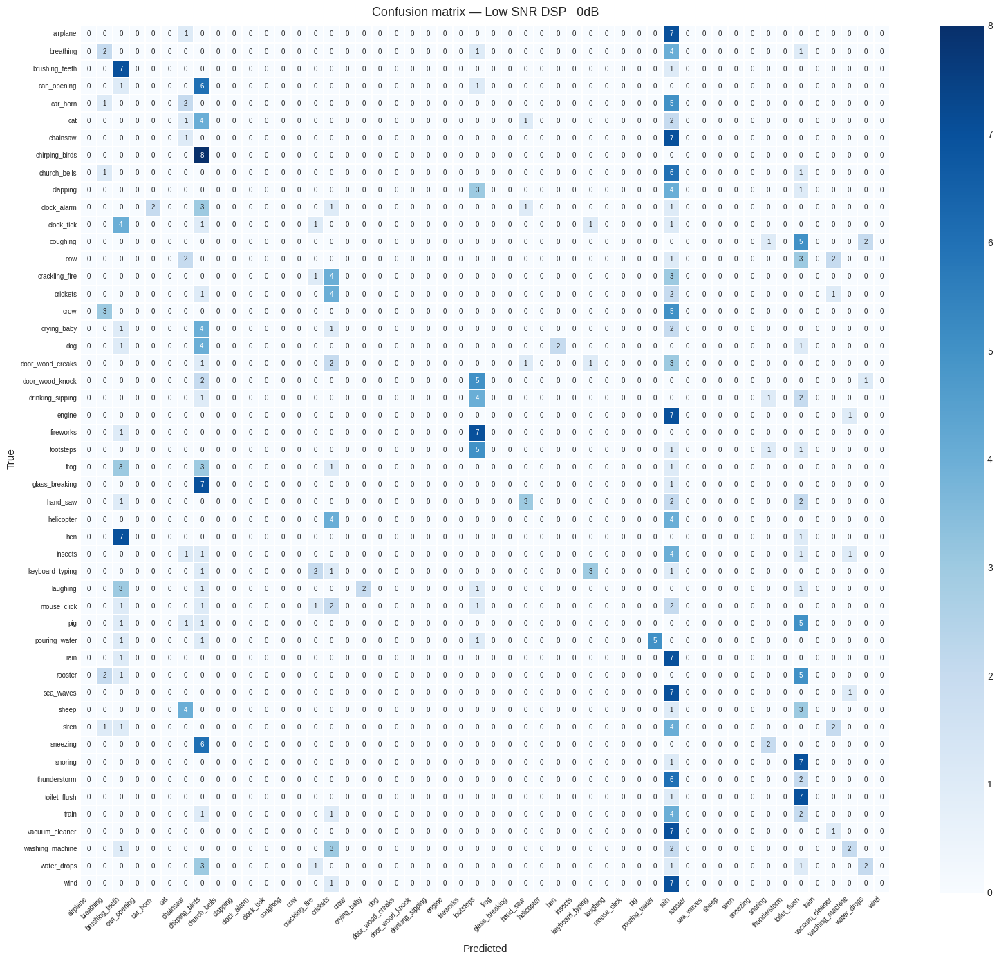

    0dB | Noisy: 10.0% → DSP: 14.5%

───────────────────────────────────────────────────────
  Low SNR Noisy -5dB   accuracy = 0.0625  (6.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.00      0.00      0.00         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.06      0.75      0.11         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.0

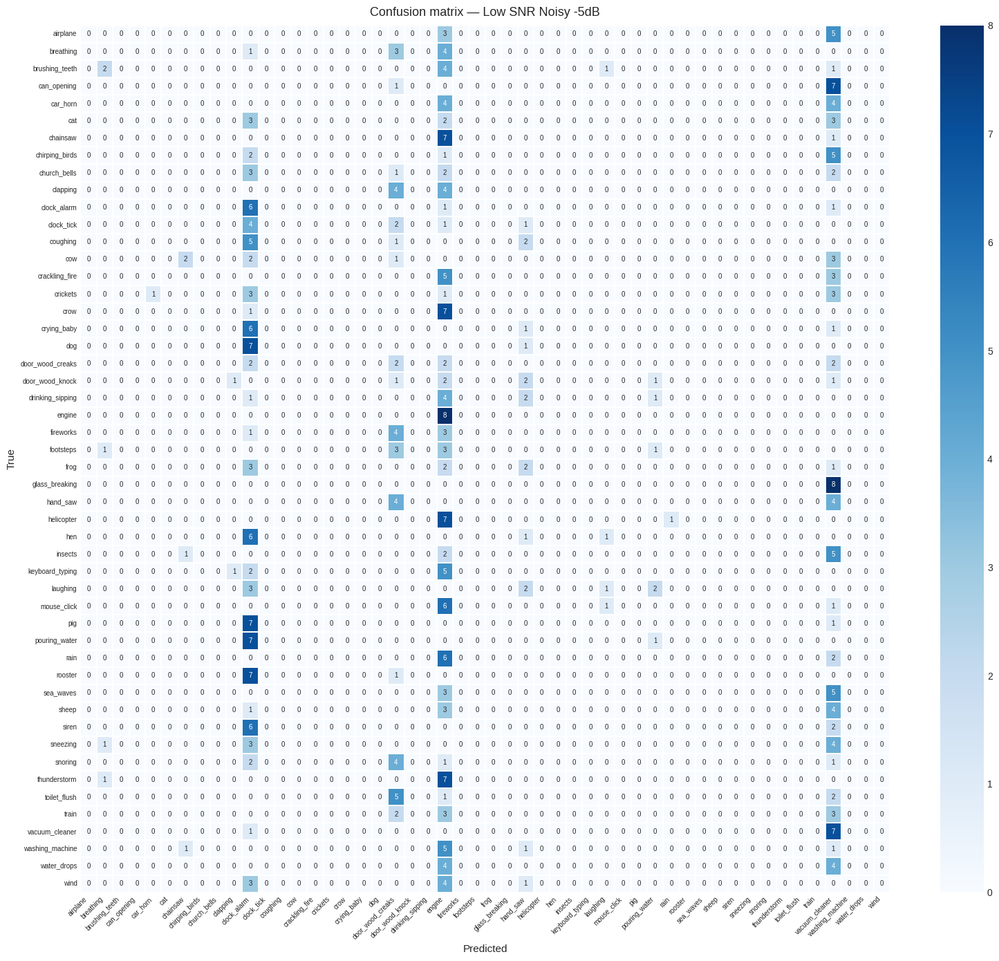


───────────────────────────────────────────────────────
  Low SNR DSP   -5dB   accuracy = 0.0550  (5.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.09      0.38      0.15         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.33      0.62      0.43         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.00      0.00      0.00         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0

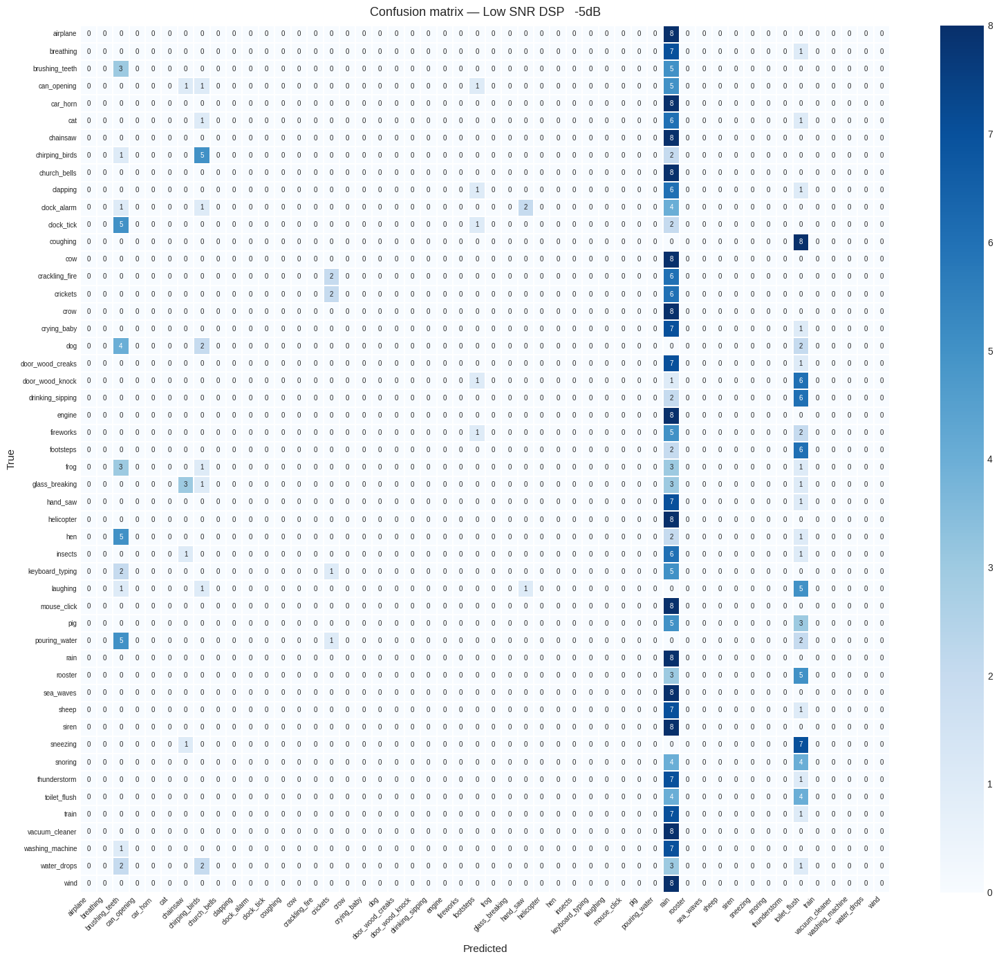

   -5dB | Noisy: 6.2% → DSP: 5.5%

───────────────────────────────────────────────────────
  Low SNR Noisy -10dB   accuracy = 0.0250  (2.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.00      0.00      0.00         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.02      1.00      0.04         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00

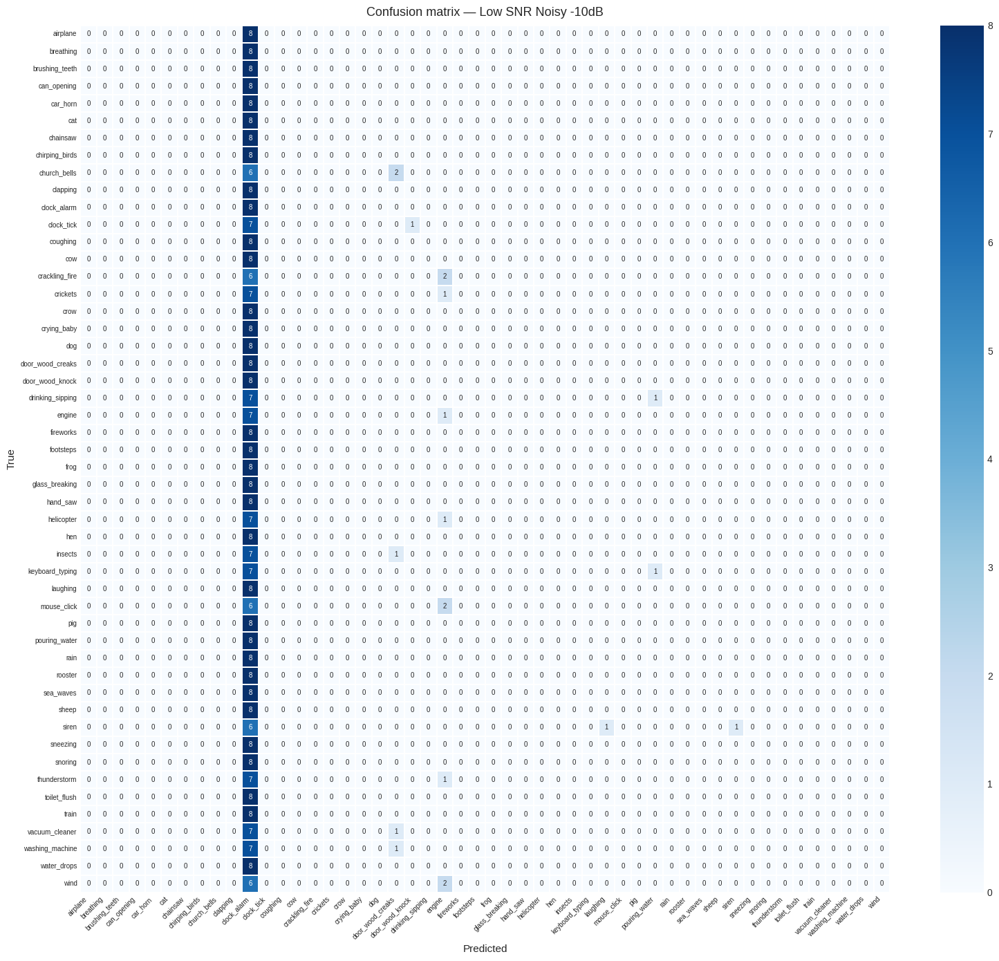


───────────────────────────────────────────────────────
  Low SNR DSP   -10dB   accuracy = 0.0225  (2.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.00      0.00      0.00         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.00      0.00      0.00         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       

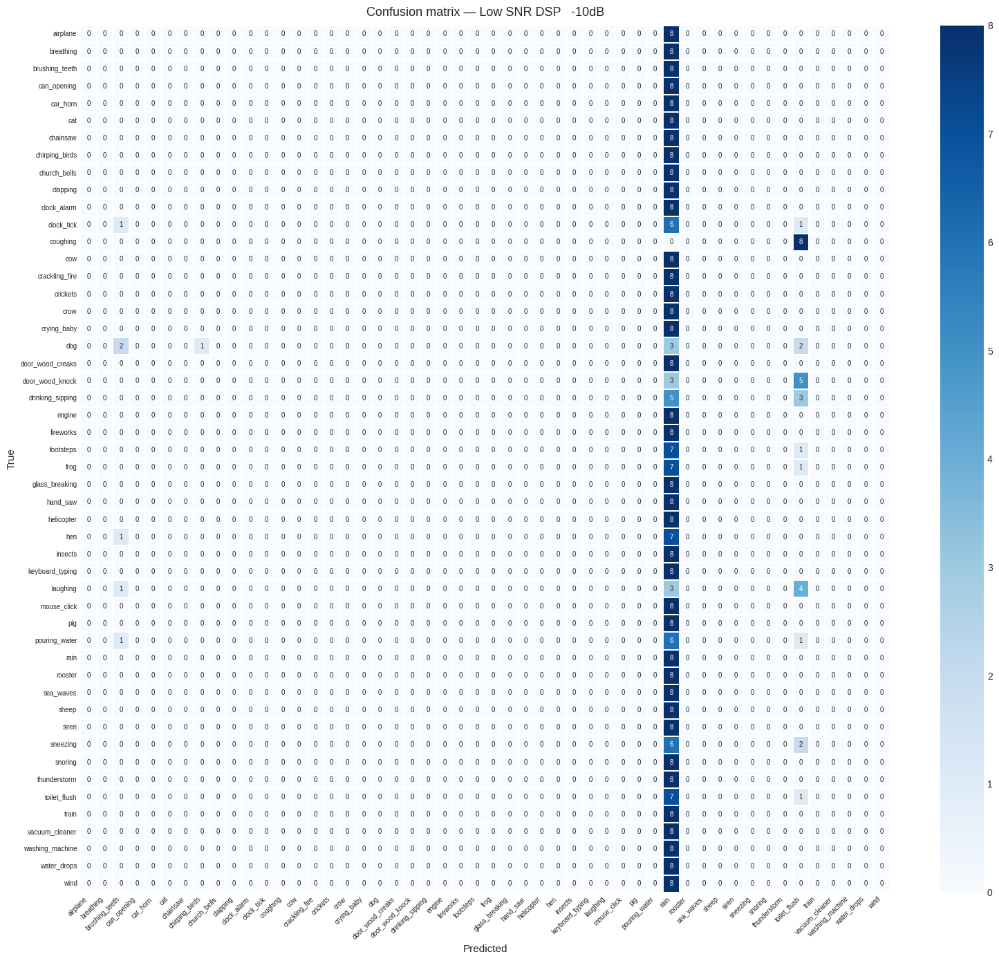

  -10dB | Noisy: 2.5% → DSP: 2.2%

 All scenarios done!


In [ ]:
WHITE_SNR_LEVELS    = [20, 15, 10, 5, 0]
GAUSSIAN_SNR_LEVELS = [20, 15, 10, 5, 0]
LOW_SNR_LEVELS      = [0, -5, -10]

def add_white_noise(X, target_snr_db):
    out = []
    for x in X:
        sig          = x.squeeze()
        signal_power = np.mean(sig ** 2)
        snr_linear   = 10 ** (target_snr_db / 10)
        noise_power  = signal_power / snr_linear
        noise        = np.random.uniform(-1, 1, size=len(sig))
        noise        = noise * np.sqrt(noise_power / (np.mean(noise**2) + 1e-10))
        noisy        = np.clip(sig + noise, -1.0, 1.0).astype(np.float32)
        out.append(noisy[..., np.newaxis])
    return np.array(out, dtype=np.float32)

def add_gaussian_noise(X, target_snr_db):
    out = []
    for x in X:
        sig          = x.squeeze()
        signal_power = np.mean(sig ** 2)
        snr_linear   = 10 ** (target_snr_db / 10)
        noise_power  = signal_power / snr_linear
        noise        = np.random.randn(len(sig))
        noise        = noise * np.sqrt(noise_power / (np.mean(noise**2) + 1e-10))
        noisy        = np.clip(sig + noise, -1.0, 1.0).astype(np.float32)
        out.append(noisy[..., np.newaxis])
    return np.array(out, dtype=np.float32)

def add_low_snr(X, target_snr_db):
    return add_gaussian_noise(X, target_snr_db)

def measure_snr_batch(X_clean, X_processed):
    snrs = []
    for c, p in zip(X_clean, X_processed):
        clean       = c.squeeze()
        processed   = p.squeeze()
        noise       = processed - clean
        sig_power   = np.mean(clean ** 2)
        noise_power = np.mean(noise ** 2)
        if noise_power < 1e-12:
            snrs.append(float('inf'))
        else:
            snrs.append(10 * np.log10(sig_power / noise_power))
    return snrs

results = {
    "white"    : {}, "white_dsp"    : {},
    "gaussian" : {}, "gaussian_dsp" : {},
    "low_snr"  : {}, "low_snr_dsp"  : {},
    "snr_noisy": {}, "snr_dsp"      : {},
    "snr_gain" : {},
}

acc_clean        = evaluate(final_model, X_test, y_test, "Clean")
results["clean"] = acc_clean

print("\nWHITE NOISE:")
for snr in WHITE_SNR_LEVELS:
    X_noisy    = add_white_noise(X_test, snr)
    X_denoised = dsp_pipeline(X_noisy)
    acc_n = evaluate(final_model, X_noisy,    y_test, f"White Noisy {snr}dB")
    acc_d = evaluate(final_model, X_denoised, y_test, f"White DSP   {snr}dB")
    results["white"][snr]                = acc_n
    results["white_dsp"][snr]            = acc_d
    results["snr_noisy"][("white", snr)] = np.mean(measure_snr_batch(X_test, X_noisy))
    results["snr_dsp"][("white", snr)]   = np.mean(measure_snr_batch(X_test, X_denoised))
    results["snr_gain"][("white", snr)]  = (results["snr_dsp"][("white", snr)] -
                                            results["snr_noisy"][("white", snr)])
    print(f"  {snr:>3}dB | Noisy: {acc_n*100:.1f}% → DSP: {acc_d*100:.1f}%")

print("\nGAUSSIAN NOISE:")
for snr in GAUSSIAN_SNR_LEVELS:
    X_noisy    = add_gaussian_noise(X_test, snr)
    X_denoised = dsp_pipeline(X_noisy)
    acc_n = evaluate(final_model, X_noisy,    y_test, f"Gaussian Noisy {snr}dB")
    acc_d = evaluate(final_model, X_denoised, y_test, f"Gaussian DSP   {snr}dB")
    results["gaussian"][snr]                = acc_n
    results["gaussian_dsp"][snr]            = acc_d
    results["snr_noisy"][("gaussian", snr)] = np.mean(measure_snr_batch(X_test, X_noisy))
    results["snr_dsp"][("gaussian", snr)]   = np.mean(measure_snr_batch(X_test, X_denoised))
    results["snr_gain"][("gaussian", snr)]  = (results["snr_dsp"][("gaussian", snr)] -
                                               results["snr_noisy"][("gaussian", snr)])
    print(f"  {snr:>3}dB | Noisy: {acc_n*100:.1f}% → DSP: {acc_d*100:.1f}%")

print("\nLOW SNR:")
for snr in LOW_SNR_LEVELS:
    X_noisy    = add_low_snr(X_test, snr)
    X_denoised = dsp_pipeline(X_noisy)
    acc_n = evaluate(final_model, X_noisy,    y_test, f"Low SNR Noisy {snr}dB")
    acc_d = evaluate(final_model, X_denoised, y_test, f"Low SNR DSP   {snr}dB")
    results["low_snr"][snr]                = acc_n
    results["low_snr_dsp"][snr]            = acc_d
    results["snr_noisy"][("low_snr", snr)] = np.mean(measure_snr_batch(X_test, X_noisy))
    results["snr_dsp"][("low_snr", snr)]   = np.mean(measure_snr_batch(X_test, X_denoised))
    results["snr_gain"][("low_snr", snr)]  = (results["snr_dsp"][("low_snr", snr)] -
                                               results["snr_noisy"][("low_snr", snr)])
    print(f"  {snr:>3}dB | Noisy: {acc_n*100:.1f}% → DSP: {acc_d*100:.1f}%")

print("\n All scenarios done!")

Cell 16 — Plots & Summary

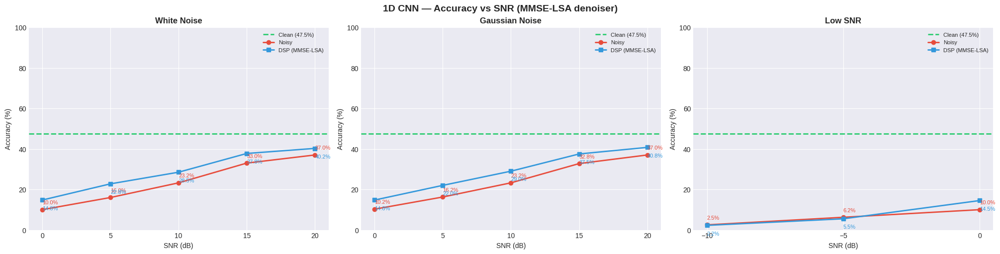

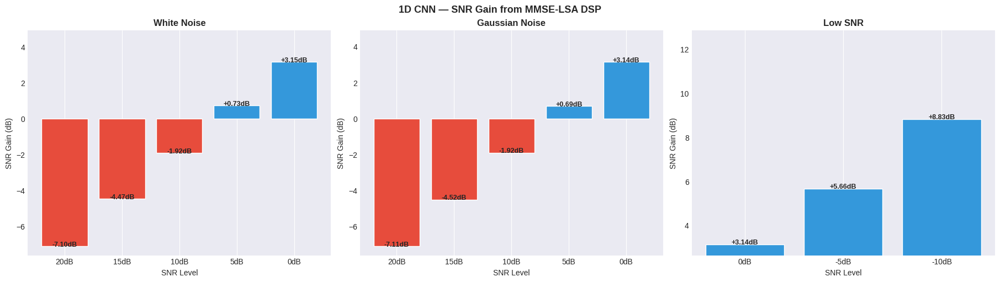

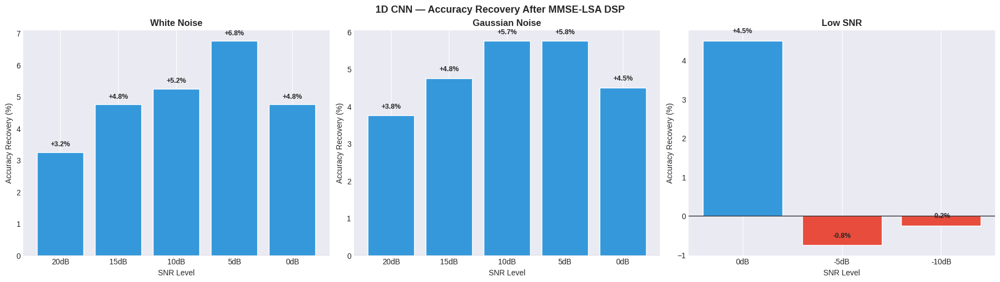

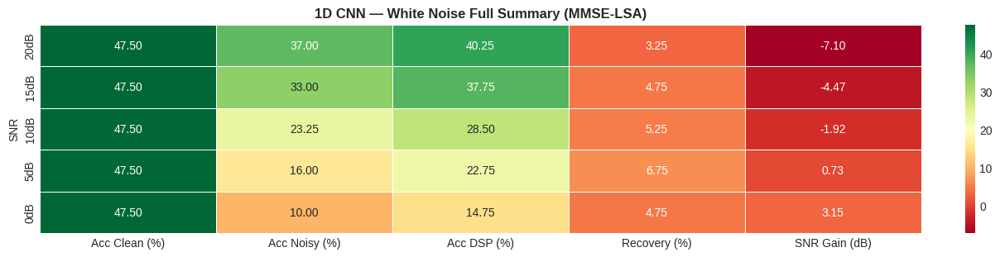

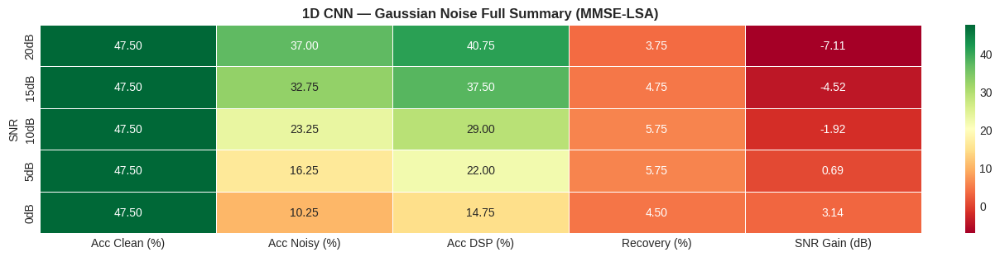

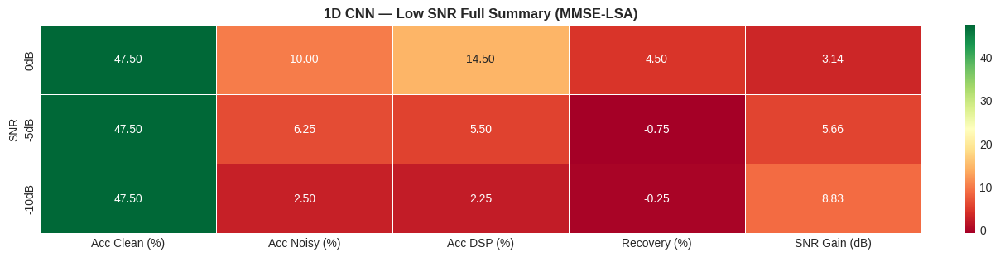

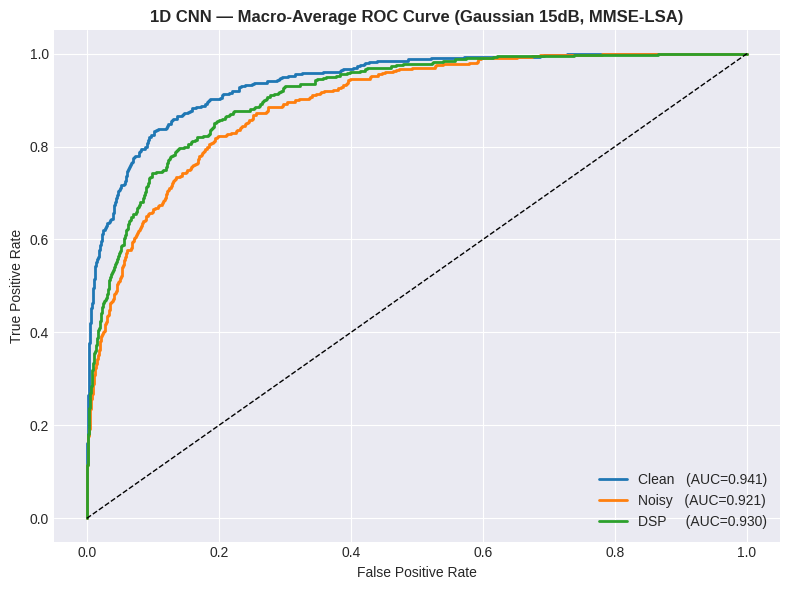


1D CNN v2 — FINAL RESULTS SUMMARY
  Clean Baseline: 47.50%

  White Noise:
      20dB | Noisy: 37.0%  → DSP: 40.2%  | SNR gain: -7.10dB
      15dB | Noisy: 33.0%  → DSP: 37.8%  | SNR gain: -4.47dB
      10dB | Noisy: 23.2%  → DSP: 28.5%  | SNR gain: -1.92dB
       5dB | Noisy: 16.0%  → DSP: 22.8%  | SNR gain: +0.73dB
       0dB | Noisy: 10.0%  → DSP: 14.8%  | SNR gain: +3.15dB

  Gaussian Noise:
      20dB | Noisy: 37.0%  → DSP: 40.8%  | SNR gain: -7.11dB
      15dB | Noisy: 32.8%  → DSP: 37.5%  | SNR gain: -4.52dB
      10dB | Noisy: 23.2%  → DSP: 29.0%  | SNR gain: -1.92dB
       5dB | Noisy: 16.2%  → DSP: 22.0%  | SNR gain: +0.69dB
       0dB | Noisy: 10.2%  → DSP: 14.8%  | SNR gain: +3.14dB

  Low SNR:
       0dB | Noisy: 10.0%  → DSP: 14.5%  | SNR gain: +3.14dB
      -5dB | Noisy: 6.2%  → DSP: 5.5%  | SNR gain: +5.66dB
     -10dB | Noisy: 2.5%  → DSP: 2.2%  | SNR gain: +8.83dB


In [ ]:
C_PLOT = {"clean": "#2ecc71", "noisy": "#e74c3c", "dsp": "#3498db"}
plt.style.use("seaborn-v0_8-darkgrid")

NOISE_CONFIGS = {
    "White Noise":    ("white",    "white_dsp",    WHITE_SNR_LEVELS),
    "Gaussian Noise": ("gaussian", "gaussian_dsp", GAUSSIAN_SNR_LEVELS),
    "Low SNR":        ("low_snr",  "low_snr_dsp",  LOW_SNR_LEVELS),
}

# GRAPH 1: Accuracy vs SNR
fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(axes, NOISE_CONFIGS.items()):
    acc_noisy = [results[nkey][s]*100 for s in snr_list]
    acc_dsp   = [results[dkey][s]*100 for s in snr_list]
    ax.axhline(results["clean"]*100, color=C_PLOT["clean"], lw=2, ls="--",
               label=f"Clean ({results['clean']*100:.1f}%)")
    ax.plot(snr_list, acc_noisy, "o-", color=C_PLOT["noisy"], lw=2, label="Noisy")
    ax.plot(snr_list, acc_dsp,   "s-", color=C_PLOT["dsp"],   lw=2, label="DSP (MMSE-LSA)")
    for s, n, d in zip(snr_list, acc_noisy, acc_dsp):
        ax.annotate(f"{n:.1f}%", (s, n), textcoords="offset points",
                    xytext=(0, 8),  fontsize=8, color=C_PLOT["noisy"])
        ax.annotate(f"{d:.1f}%", (s, d), textcoords="offset points",
                    xytext=(0,-14), fontsize=8, color=C_PLOT["dsp"])
    ax.set_title(noise_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(snr_list); ax.set_ylim(0, 100)
    ax.legend(fontsize=8); ax.grid(True)
plt.suptitle("1D CNN — Accuracy vs SNR (MMSE-LSA denoiser)",
             fontsize=14, fontweight="bold")
plt.show()

# GRAPH 2: SNR Gain from DSP
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(axes, NOISE_CONFIGS.items()):
    gains    = [results["snr_gain"][(nkey, s)] for s in snr_list]
    bar_cols = [C_PLOT["dsp"] if g >= 0 else C_PLOT["noisy"] for g in gains]
    bars     = ax.bar([f"{s}dB" for s in snr_list], gains,
                      color=bar_cols, edgecolor="white")
    for bar, g in zip(bars, gains):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{g:+.2f}dB", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(noise_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("SNR Level"); ax.set_ylabel("SNR Gain (dB)")
    max_gain = max(gains) if max(gains) > 0 else 1
    ax.set_ylim(min(gains) - 0.5, max_gain * 1.4 + 0.5)
    ax.grid(axis="y")
plt.suptitle("1D CNN — SNR Gain from MMSE-LSA DSP",
             fontsize=13, fontweight="bold")
plt.show()

# GRAPH 3: Accuracy Recovery
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (noise_label, (nkey, dkey, snr_list)) in zip(axes, NOISE_CONFIGS.items()):
    recovery = [results[dkey][s]*100 - results[nkey][s]*100 for s in snr_list]
    bar_cols = [C_PLOT["dsp"] if v >= 0 else C_PLOT["noisy"] for v in recovery]
    bars     = ax.bar([f"{s}dB" for s in snr_list], recovery,
                      color=bar_cols, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    for bar, v in zip(bars, recovery):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f"{v:+.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(noise_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("SNR Level"); ax.set_ylabel("Accuracy Recovery (%)")
    ax.grid(axis="y")
plt.suptitle("1D CNN — Accuracy Recovery After MMSE-LSA DSP",
             fontsize=13, fontweight="bold")
plt.show()

# GRAPH 4: Summary heatmaps
for noise_label, (nkey, dkey, snr_list) in NOISE_CONFIGS.items():
    heat_data = pd.DataFrame({
        "SNR":           [f"{s}dB" for s in snr_list],
        "Acc Clean (%)": [round(results["clean"]*100, 2)] * len(snr_list),
        "Acc Noisy (%)": [round(results[nkey][s]*100, 2) for s in snr_list],
        "Acc DSP (%)":   [round(results[dkey][s]*100, 2) for s in snr_list],
        "Recovery (%)":  [round((results[dkey][s]-results[nkey][s])*100, 2)
                          for s in snr_list],
        "SNR Gain (dB)": [round(results["snr_gain"][(nkey, s)], 2)
                          for s in snr_list],
    }).set_index("SNR")
    fig, ax = plt.subplots(figsize=(12, 3), constrained_layout=True)
    sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="RdYlGn",
                linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(f"1D CNN — {noise_label} Full Summary (MMSE-LSA)",
                 fontsize=12, fontweight="bold")
    plt.show()

# GRAPH 5: AUC-ROC on Gaussian 15dB
y_bin       = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
X_g15       = add_gaussian_noise(X_test, 15)
X_g15_dsp   = dsp_pipeline(X_g15)

probs_clean = final_model.predict(X_test,    verbose=0)
probs_noisy = final_model.predict(X_g15,     verbose=0)
probs_dsp   = final_model.predict(X_g15_dsp, verbose=0)

auc_clean = roc_auc_score(y_bin, probs_clean, multi_class="ovr", average="macro")
auc_noisy = roc_auc_score(y_bin, probs_noisy, multi_class="ovr", average="macro")
auc_dsp   = roc_auc_score(y_bin, probs_dsp,   multi_class="ovr", average="macro")

plt.figure(figsize=(8, 6))
for probs, label, color in [
    (probs_clean, f"Clean   (AUC={auc_clean:.3f})", C_PLOT["clean"]),
    (probs_noisy, f"Noisy   (AUC={auc_noisy:.3f})", C_PLOT["noisy"]),
    (probs_dsp,   f"DSP     (AUC={auc_dsp:.3f})",   C_PLOT["dsp"]),
]:
    fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
    plt.plot(fpr, tpr, label=label, linewidth=2)
plt.plot([0,1],[0,1], "k--", linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("1D CNN — Macro-Average ROC Curve (Gaussian 15dB, MMSE-LSA)",
          fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()

# FINAL SUMMARY TABLE
print("\n" + "="*65)
print("1D CNN v2 — FINAL RESULTS SUMMARY")
print("="*65)
print(f"  Clean Baseline: {results['clean']*100:.2f}%")
for noise_label, (nkey, dkey, snr_list) in NOISE_CONFIGS.items():
    print(f"\n  {noise_label}:")
    for snr in snr_list:
        print(f"    {snr:>4}dB | "
              f"Noisy: {results[nkey][snr]*100:.1f}%  "
              f"→ DSP: {results[dkey][snr]*100:.1f}%  "
              f"| SNR gain: {results['snr_gain'][(nkey,snr)]:+.2f}dB")
print("="*65)

Cell 17 — Noise Injection & Robustness Evaluation (Butter worth + Spectral Subraction)


───────────────────────────────────────────────────────
  Clean   accuracy = 0.4750  (47.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.17      0.12      0.14         8
       breathing       0.29      0.25      0.27         8
  brushing_teeth       0.58      0.88      0.70         8
     can_opening       0.83      0.62      0.71         8
        car_horn       0.70      0.88      0.78         8
             cat       0.50      0.50      0.50         8
        chainsaw       0.40      0.75      0.52         8
  chirping_birds       0.55      0.75      0.63         8
    church_bells       0.54      0.88      0.67         8
        clapping       0.60      0.38      0.46         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.22      0.25      0.24         8
        coughing       0.83      0.62      0.71         8
             cow       0.67      0.2

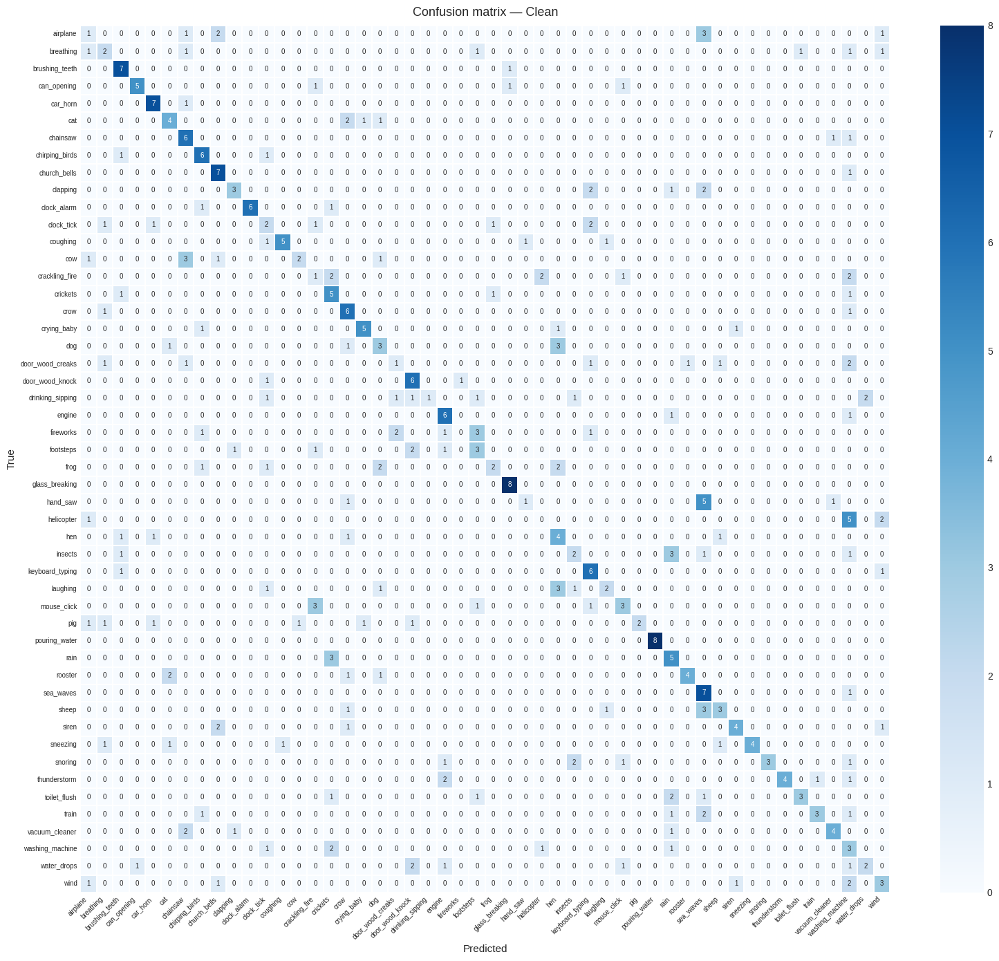


WHITE NOISE (Butterworth+SpectralSub):

───────────────────────────────────────────────────────
  White Noisy 20dB   accuracy = 0.3700  (37.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.25      0.25      0.25         8
  brushing_teeth       0.47      1.00      0.64         8
     can_opening       0.50      0.12      0.20         8
        car_horn       0.55      0.75      0.63         8
             cat       0.43      0.75      0.55         8
        chainsaw       0.29      0.75      0.41         8
  chirping_birds       0.25      0.62      0.36         8
    church_bells       0.43      0.38      0.40         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.43      0.38      0.40         8
        coughing       1.00      0.25      

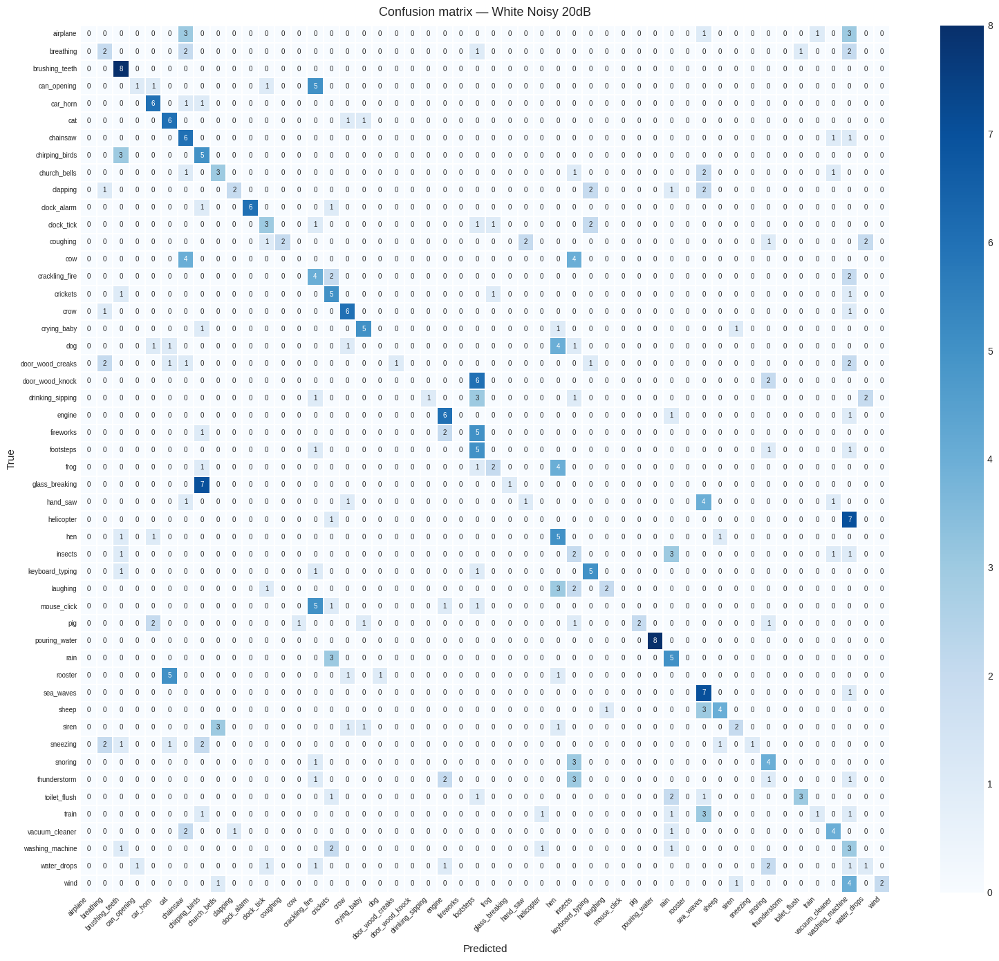


───────────────────────────────────────────────────────
  White DSP   20dB   accuracy = 0.3625  (36.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.33      0.25      0.29         8
  brushing_teeth       0.35      0.88      0.50         8
     can_opening       0.40      0.25      0.31         8
        car_horn       0.50      0.50      0.50         8
             cat       0.50      0.75      0.60         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.54      0.88      0.67         8
    church_bells       0.44      0.50      0.47         8
        clapping       0.22      0.50      0.31         8
     clock_alarm       0.86      0.75      0.80         8
      clock_tick       0.22      0.25      0.24         8
        coughing       1.00      0.25      0.40         8
             cow       0.

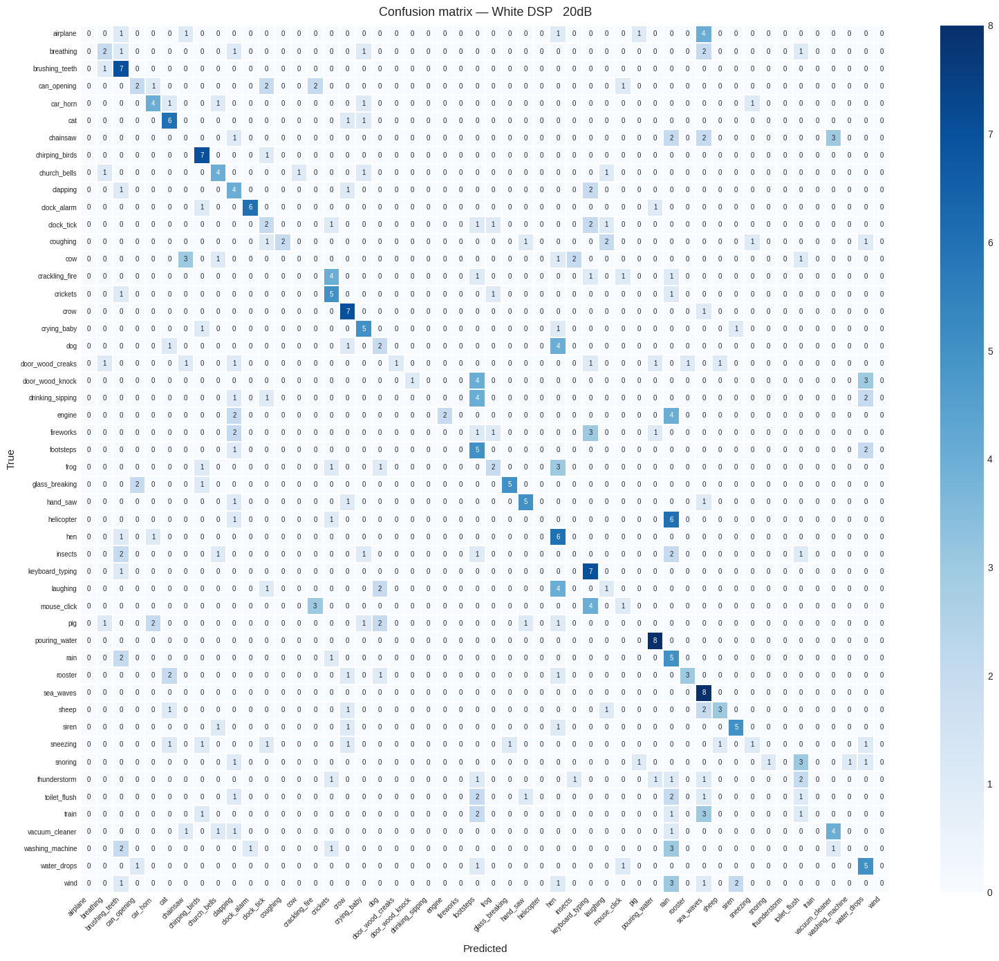

   20dB | Noisy: 37.0% → DSP: 36.2%

───────────────────────────────────────────────────────
  White Noisy 15dB   accuracy = 0.3325  (33.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.33      0.25      0.29         8
  brushing_teeth       0.33      0.88      0.48         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.56      0.62      0.59         8
             cat       0.45      0.62      0.53         8
        chainsaw       0.19      0.62      0.29         8
  chirping_birds       0.14      0.62      0.23         8
    church_bells       1.00      0.12      0.22         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.50      0.12      0.20         8
        coughing       0.00      0.00      0.00

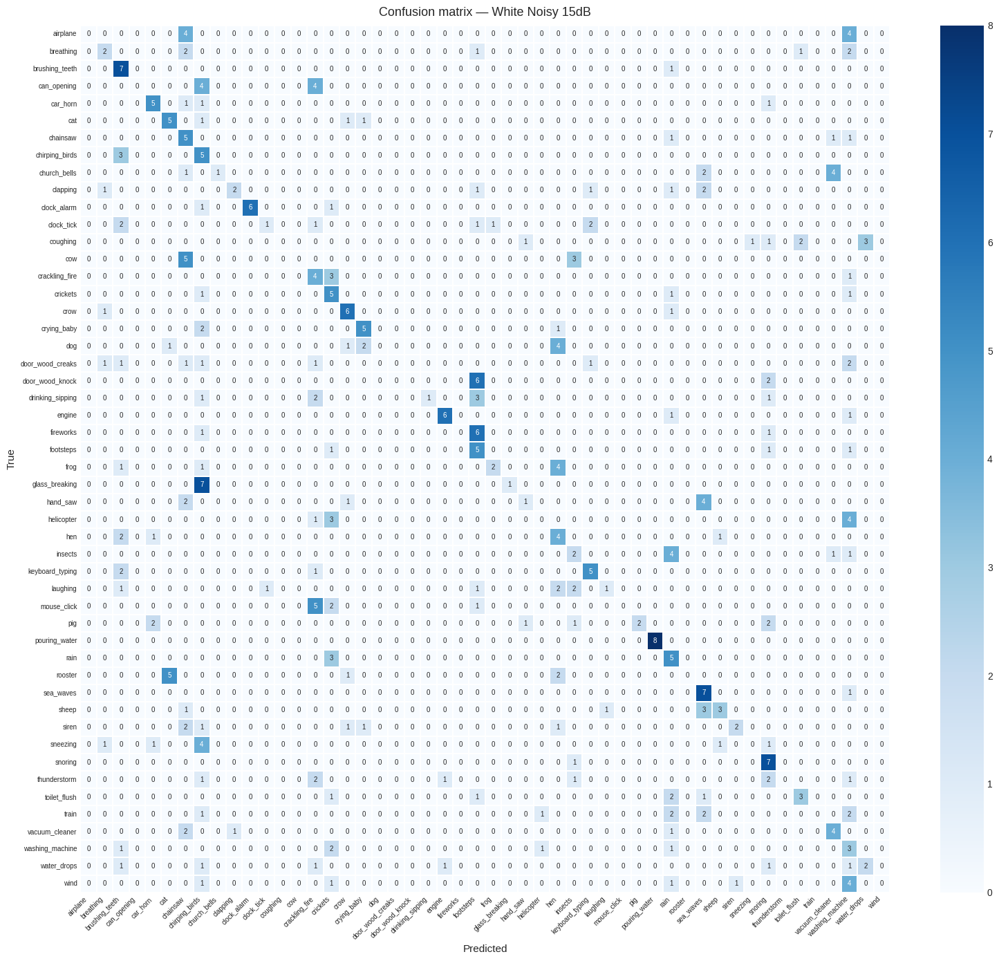


───────────────────────────────────────────────────────
  White DSP   15dB   accuracy = 0.3350  (33.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.43      0.38      0.40         8
  brushing_teeth       0.33      1.00      0.50         8
     can_opening       0.33      0.12      0.18         8
        car_horn       0.50      0.50      0.50         8
             cat       0.33      0.62      0.43         8
        chainsaw       0.10      0.12      0.11         8
  chirping_birds       0.39      0.88      0.54         8
    church_bells       0.40      0.25      0.31         8
        clapping       0.27      0.50      0.35         8
     clock_alarm       0.83      0.62      0.71         8
      clock_tick       0.33      0.38      0.35         8
        coughing       1.00      0.12      0.22         8
             cow       0.

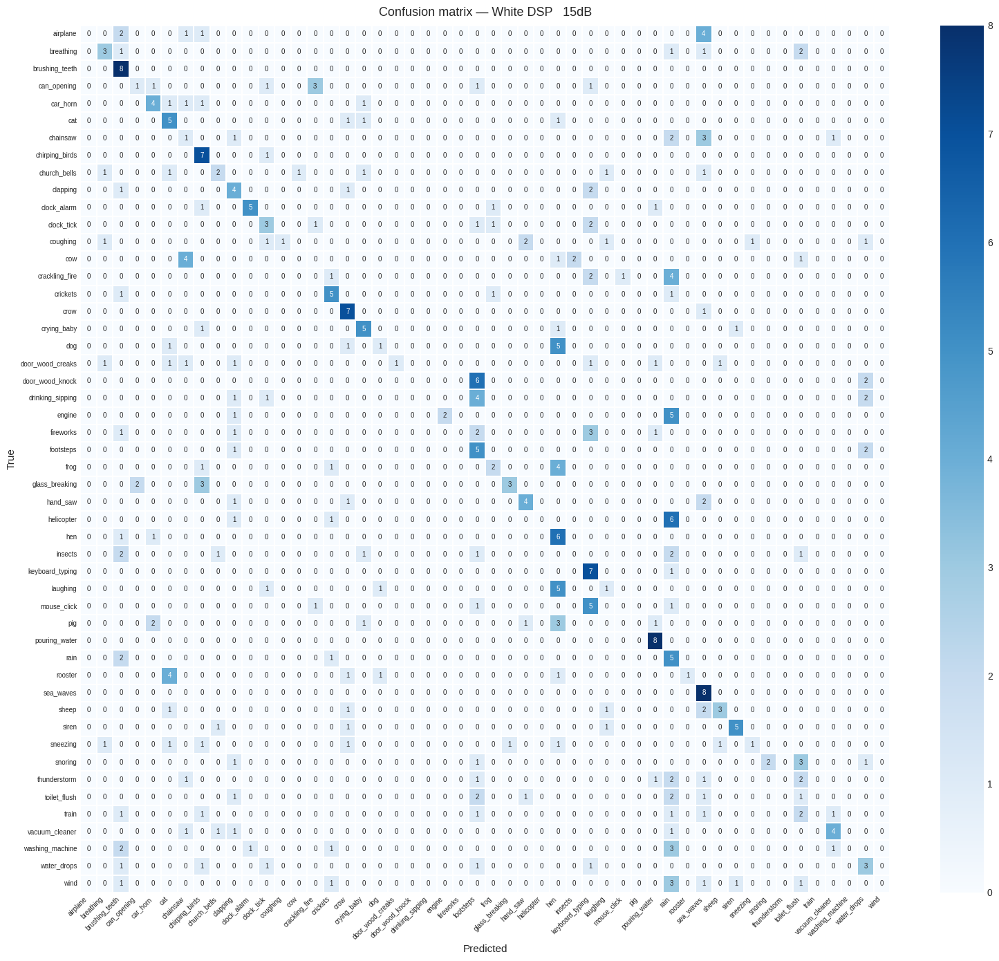

   15dB | Noisy: 33.2% → DSP: 33.5%

───────────────────────────────────────────────────────
  White Noisy 10dB   accuracy = 0.2300  (23.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.20      0.25      0.22         8
  brushing_teeth       0.26      0.75      0.39         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.71      0.62      0.67         8
             cat       0.33      0.25      0.29         8
        chainsaw       0.17      0.62      0.26         8
  chirping_birds       0.09      0.62      0.15         8
    church_bells       0.00      0.00      0.00         8
        clapping       1.00      0.25      0.40         8
     clock_alarm       1.00      0.62      0.77         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00

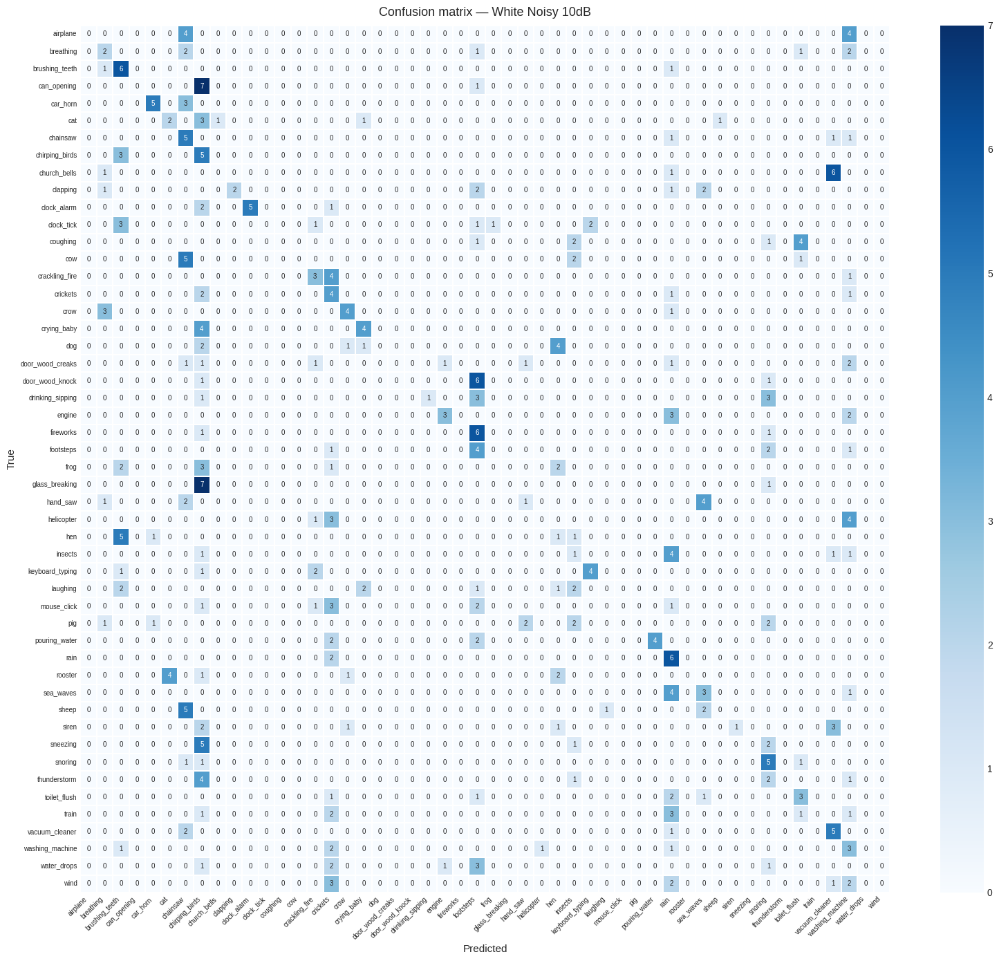


───────────────────────────────────────────────────────
  White DSP   10dB   accuracy = 0.2950  (29.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.27      0.38      0.32         8
  brushing_teeth       0.35      1.00      0.52         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.38      0.43         8
             cat       0.31      0.50      0.38         8
        chainsaw       0.09      0.12      0.11         8
  chirping_birds       0.24      0.75      0.36         8
    church_bells       0.33      0.12      0.18         8
        clapping       0.50      0.50      0.50         8
     clock_alarm       0.83      0.62      0.71         8
      clock_tick       0.20      0.12      0.15         8
        coughing       1.00      0.12      0.22         8
             cow       0.

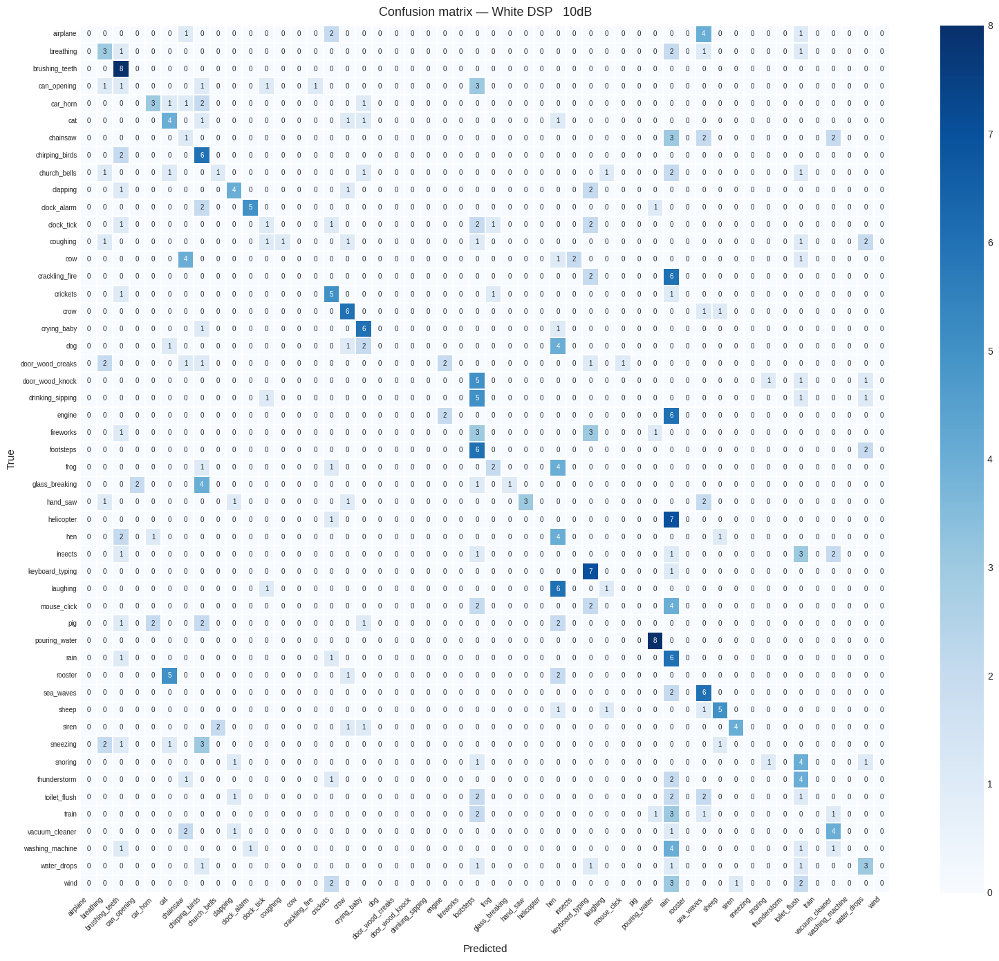

   10dB | Noisy: 23.0% → DSP: 29.5%

───────────────────────────────────────────────────────
  White Noisy 5dB   accuracy = 0.1625  (16.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.09      0.12      0.11         8
  brushing_teeth       0.19      0.75      0.31         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.75      0.38      0.50         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.08      0.62      0.15         8
  chirping_birds       0.14      0.50      0.22         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       1.00      0.62      0.77         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00 

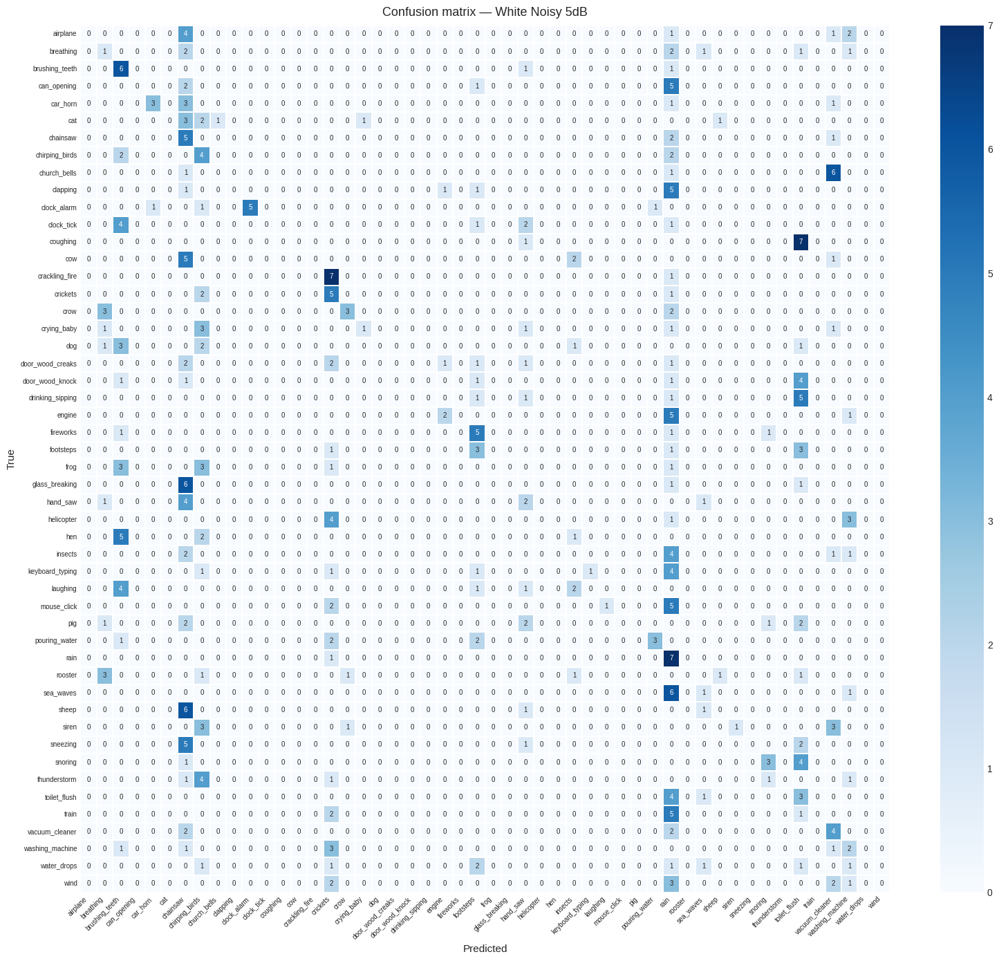


───────────────────────────────────────────────────────
  White DSP   5dB   accuracy = 0.2300  (23.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.20      0.38      0.26         8
  brushing_teeth       0.14      0.62      0.22         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.25      0.33         8
             cat       0.43      0.38      0.40         8
        chainsaw       0.07      0.12      0.09         8
  chirping_birds       0.16      0.62      0.25         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.75      0.38      0.50         8
     clock_alarm       1.00      0.62      0.77         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0.0

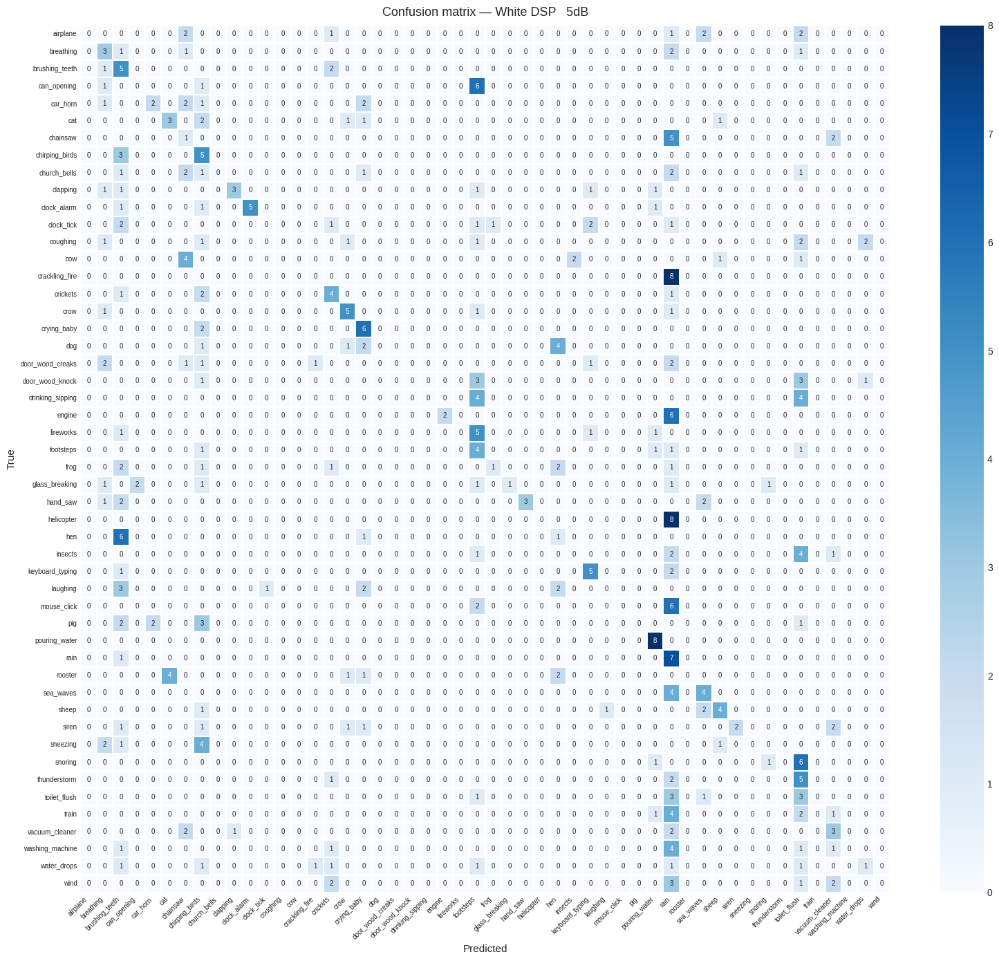

    5dB | Noisy: 16.2% → DSP: 23.0%

───────────────────────────────────────────────────────
  White Noisy 0dB   accuracy = 0.1025  (10.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.11      0.50      0.17         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.40      0.50      0.44         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.09      0.62      0.16         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.43      0.38      0.40         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00 

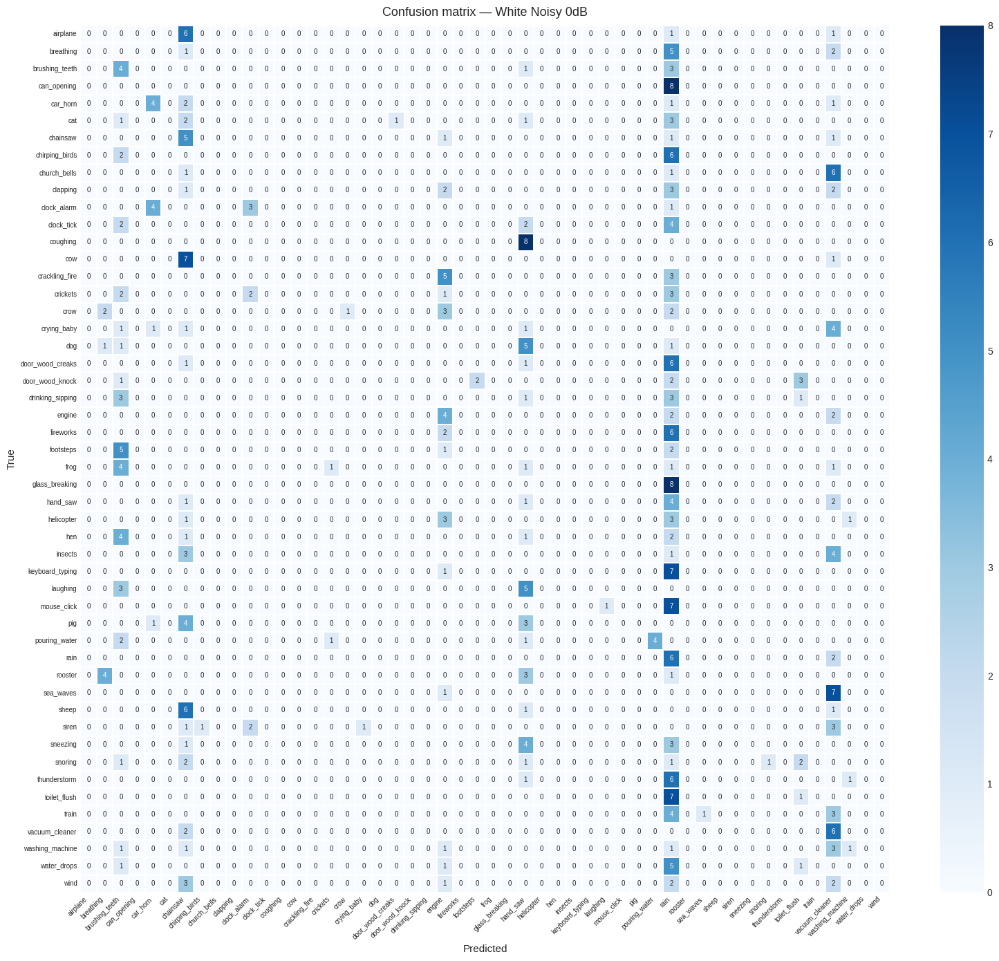


───────────────────────────────────────────────────────
  White DSP   0dB   accuracy = 0.1225  (12.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.17      0.25      0.20         8
  brushing_teeth       0.12      0.75      0.21         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.12      0.20         8
             cat       1.00      0.12      0.22         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.10      0.38      0.16         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.50      0.12      0.20         8
     clock_alarm       1.00      0.25      0.40         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0.0

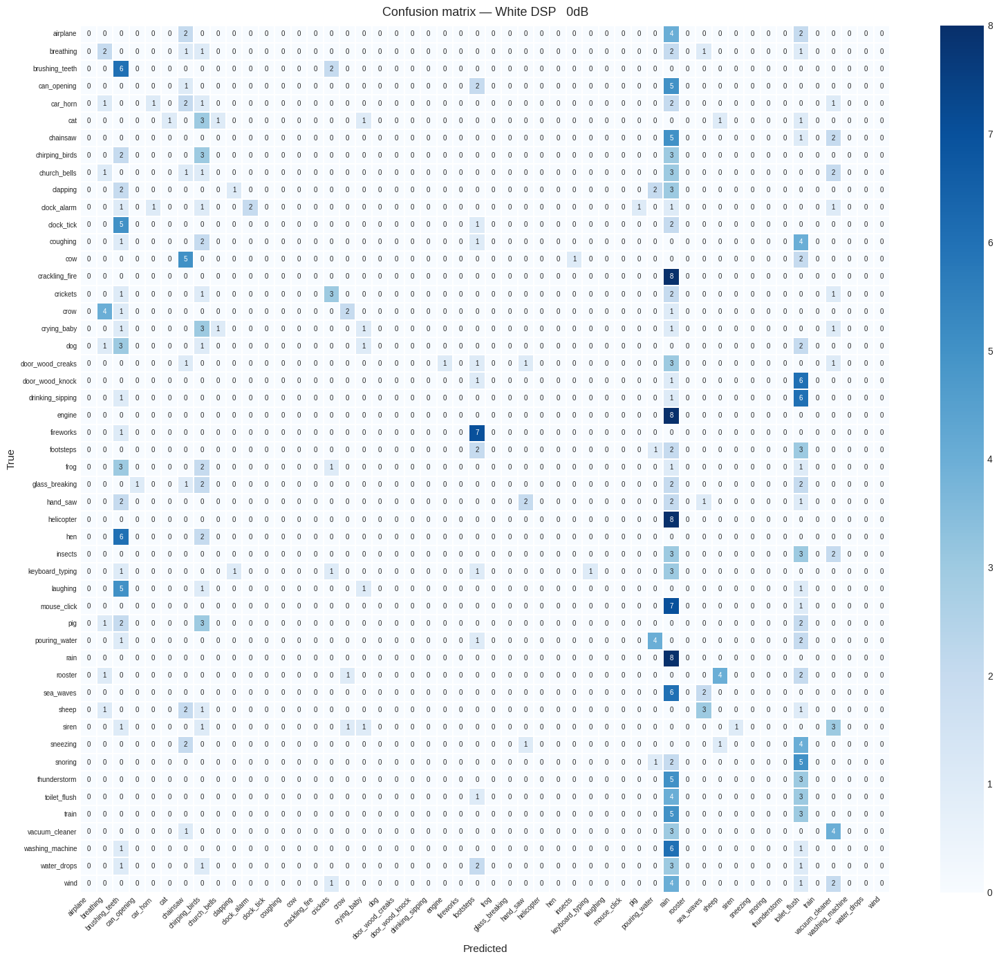

    0dB | Noisy: 10.2% → DSP: 12.2%

GAUSSIAN NOISE (Butterworth+SpectralSub):

───────────────────────────────────────────────────────
  Gaussian Noisy 20dB   accuracy = 0.3675  (36.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.25      0.25      0.25         8
  brushing_teeth       0.50      0.88      0.64         8
     can_opening       0.50      0.12      0.20         8
        car_horn       0.55      0.75      0.63         8
             cat       0.43      0.75      0.55         8
        chainsaw       0.29      0.75      0.41         8
  chirping_birds       0.25      0.62      0.36         8
    church_bells       0.43      0.38      0.40         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.43      0.38      0.40         8
 

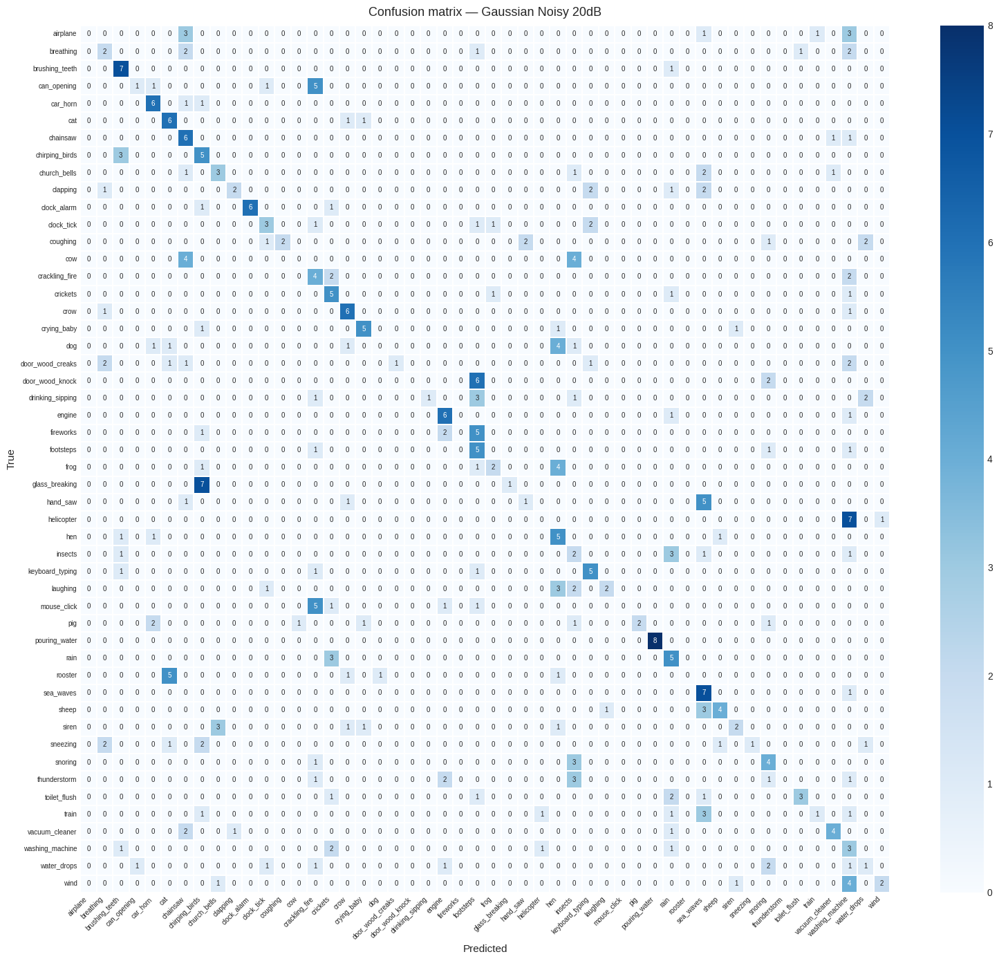


───────────────────────────────────────────────────────
  Gaussian DSP   20dB   accuracy = 0.3675  (36.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.33      0.25      0.29         8
  brushing_teeth       0.32      0.88      0.47         8
     can_opening       0.40      0.25      0.31         8
        car_horn       0.50      0.50      0.50         8
             cat       0.50      0.75      0.60         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.54      0.88      0.67         8
    church_bells       0.44      0.50      0.47         8
        clapping       0.21      0.50      0.30         8
     clock_alarm       0.86      0.75      0.80         8
      clock_tick       0.30      0.38      0.33         8
        coughing       1.00      0.25      0.40         8
             cow      

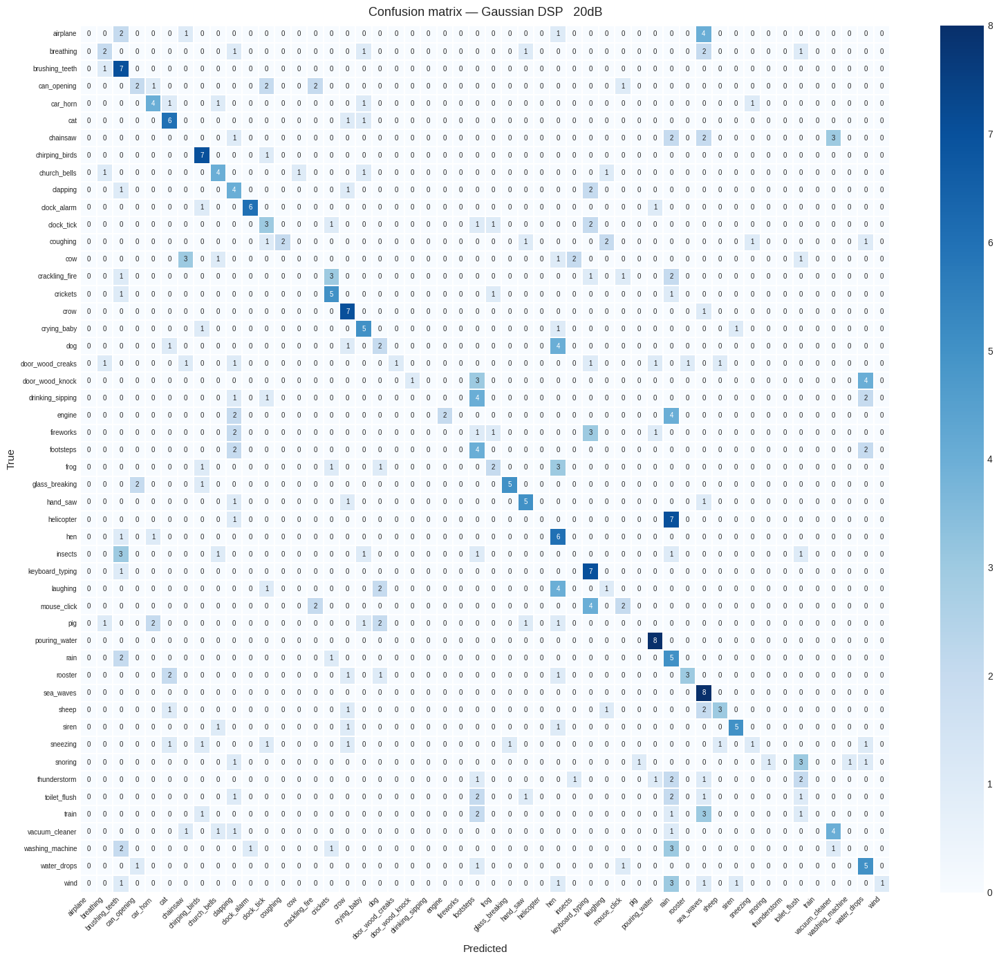

   20dB | Noisy: 36.8% → DSP: 36.8%

───────────────────────────────────────────────────────
  Gaussian Noisy 15dB   accuracy = 0.3275  (32.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.33      0.25      0.29         8
  brushing_teeth       0.33      0.88      0.48         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.56      0.62      0.59         8
             cat       0.45      0.62      0.53         8
        chainsaw       0.19      0.62      0.29         8
  chirping_birds       0.15      0.62      0.24         8
    church_bells       1.00      0.12      0.22         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.75      0.86         8
      clock_tick       0.50      0.12      0.20         8
        coughing       0.00      0.00      0

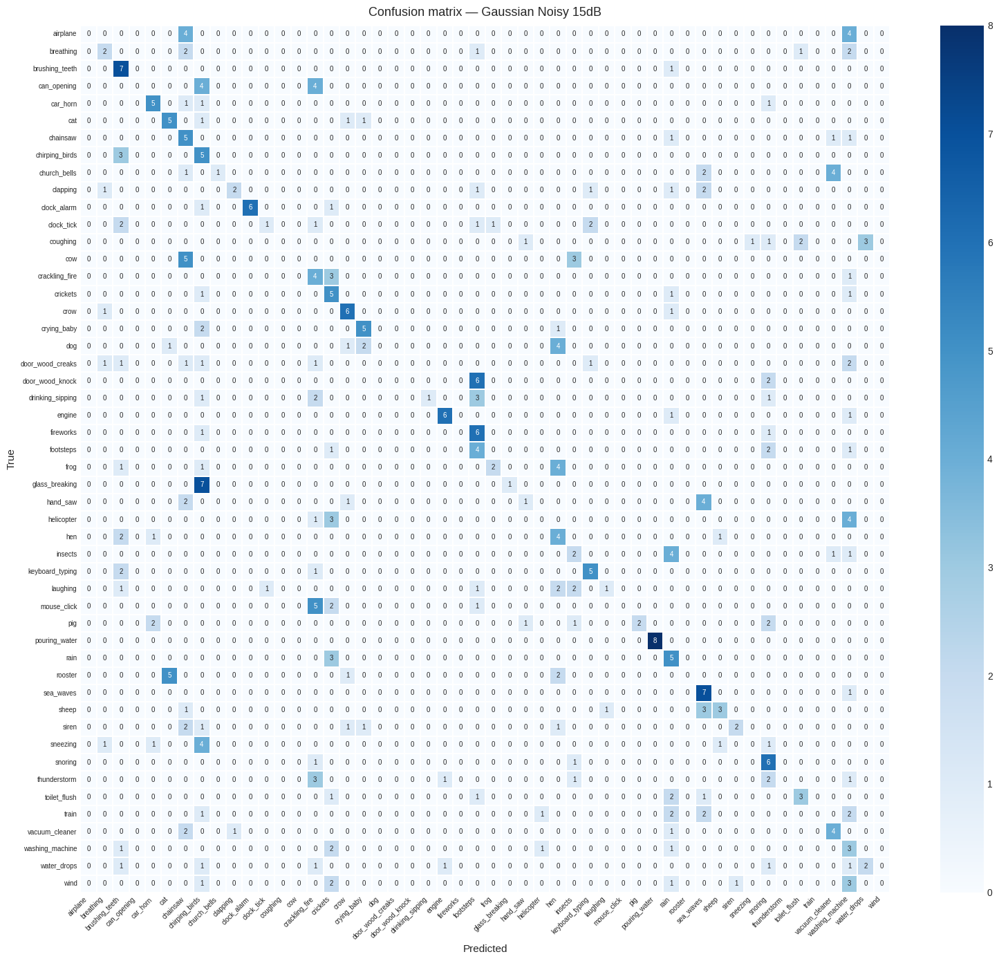


───────────────────────────────────────────────────────
  Gaussian DSP   15dB   accuracy = 0.3475  (34.8 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.43      0.38      0.40         8
  brushing_teeth       0.35      1.00      0.52         8
     can_opening       0.33      0.12      0.18         8
        car_horn       0.50      0.50      0.50         8
             cat       0.38      0.75      0.50         8
        chainsaw       0.11      0.12      0.12         8
  chirping_birds       0.39      0.88      0.54         8
    church_bells       0.40      0.25      0.31         8
        clapping       0.25      0.50      0.33         8
     clock_alarm       0.83      0.62      0.71         8
      clock_tick       0.33      0.38      0.35         8
        coughing       1.00      0.12      0.22         8
             cow      

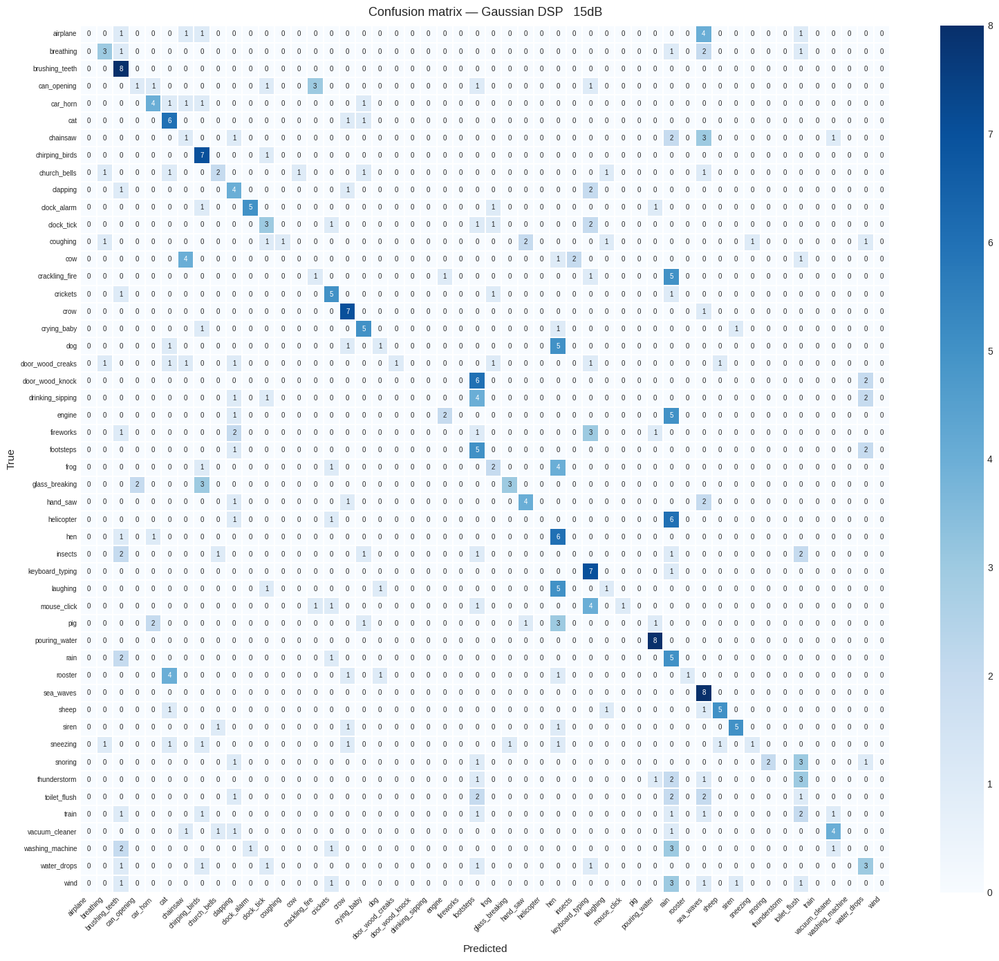

   15dB | Noisy: 32.8% → DSP: 34.8%

───────────────────────────────────────────────────────
  Gaussian Noisy 10dB   accuracy = 0.2250  (22.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.20      0.25      0.22         8
  brushing_teeth       0.23      0.75      0.35         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.71      0.62      0.67         8
             cat       0.33      0.25      0.29         8
        chainsaw       0.17      0.62      0.26         8
  chirping_birds       0.08      0.62      0.15         8
    church_bells       0.00      0.00      0.00         8
        clapping       1.00      0.12      0.22         8
     clock_alarm       1.00      0.62      0.77         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0

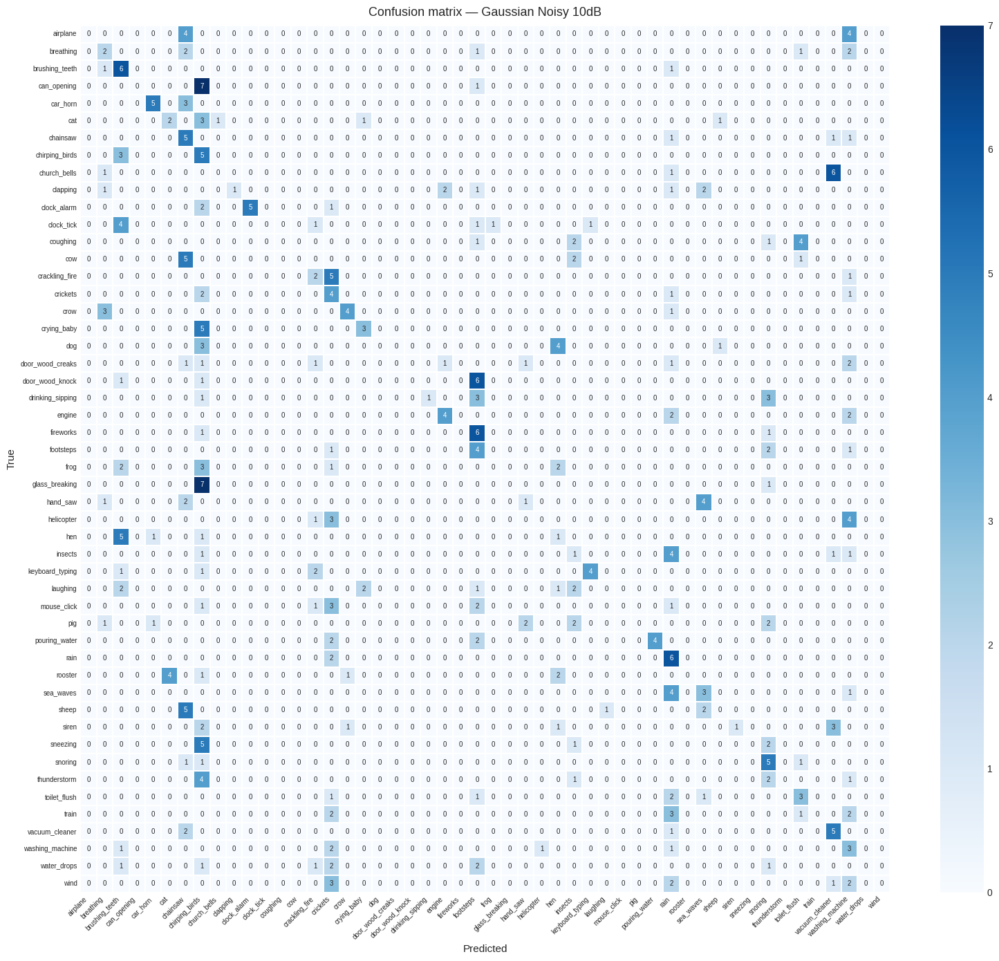


───────────────────────────────────────────────────────
  Gaussian DSP   10dB   accuracy = 0.2925  (29.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.25      0.38      0.30         8
  brushing_teeth       0.36      1.00      0.53         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.38      0.43         8
             cat       0.31      0.50      0.38         8
        chainsaw       0.08      0.12      0.10         8
  chirping_birds       0.21      0.75      0.33         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.50      0.50      0.50         8
     clock_alarm       0.83      0.62      0.71         8
      clock_tick       0.20      0.12      0.15         8
        coughing       1.00      0.12      0.22         8
             cow      

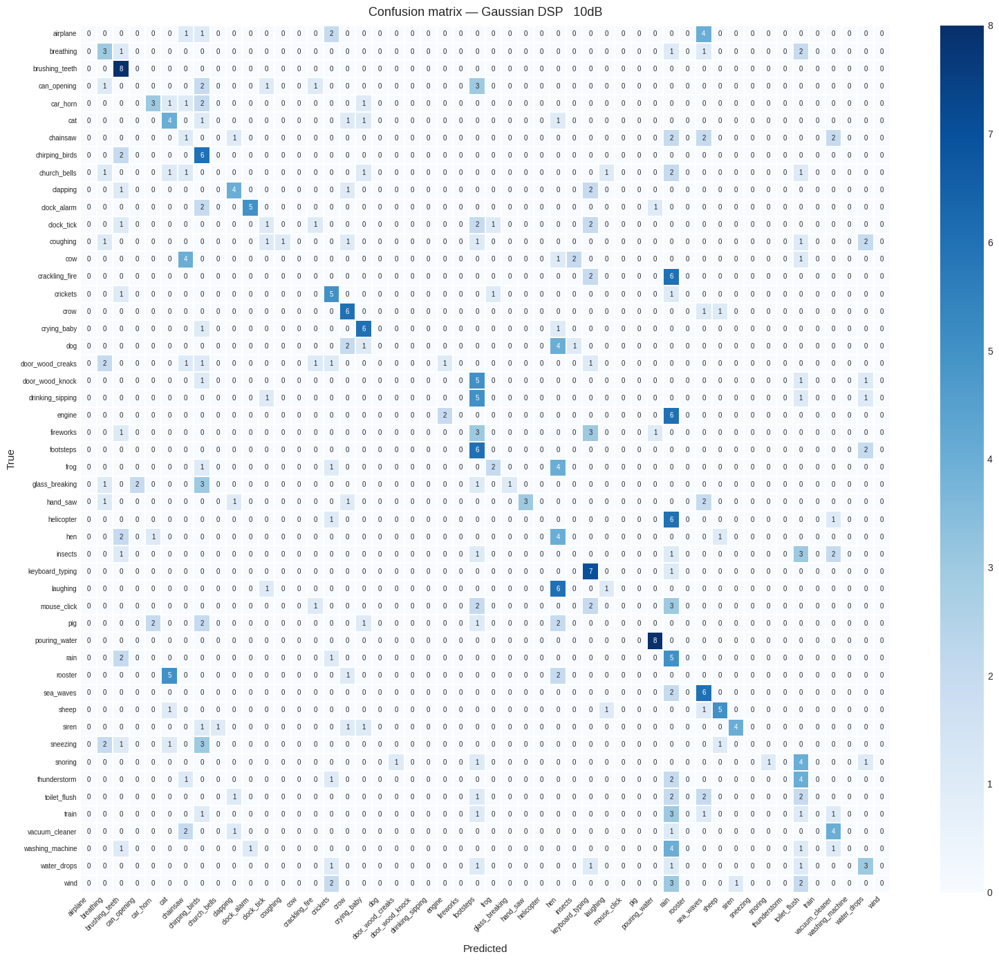

   10dB | Noisy: 22.5% → DSP: 29.2%

───────────────────────────────────────────────────────
  Gaussian Noisy 5dB   accuracy = 0.1625  (16.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.10      0.12      0.11         8
  brushing_teeth       0.19      0.75      0.30         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.60      0.38      0.46         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.09      0.62      0.16         8
  chirping_birds       0.14      0.50      0.22         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       1.00      0.62      0.77         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.

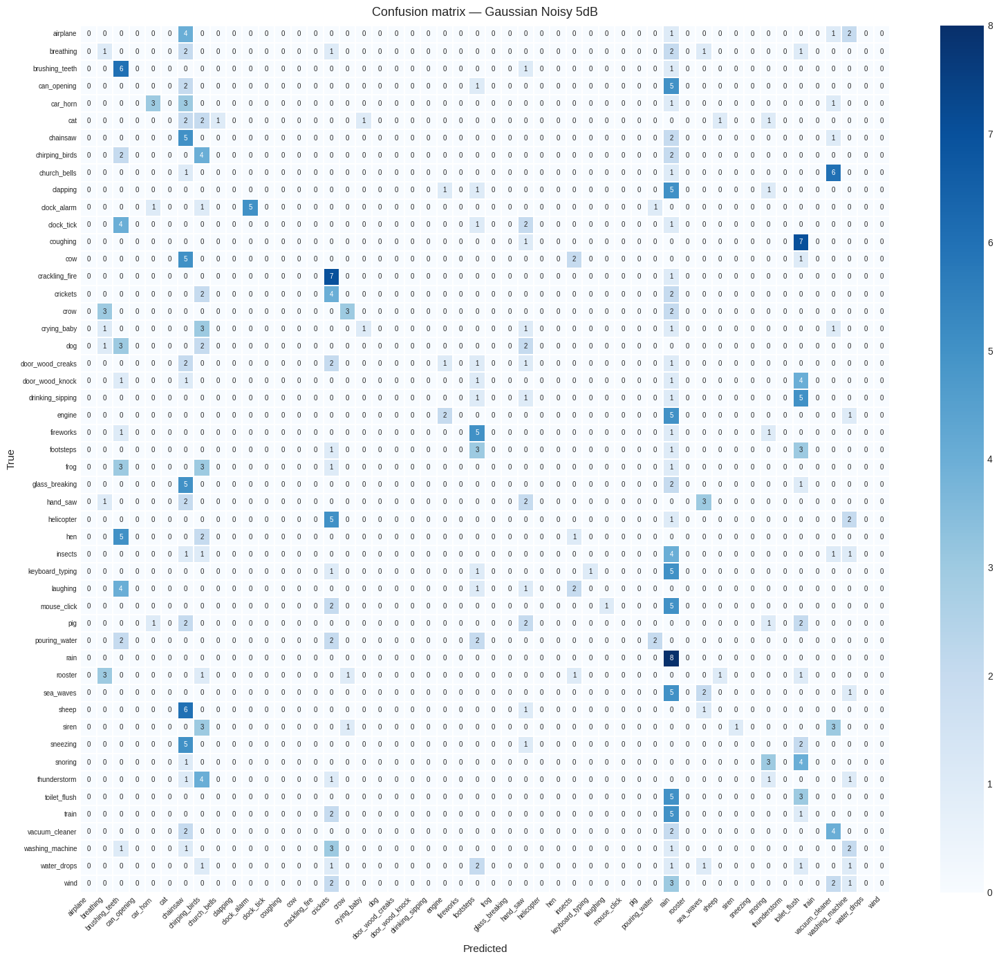


───────────────────────────────────────────────────────
  Gaussian DSP   5dB   accuracy = 0.2250  (22.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.18      0.38      0.24         8
  brushing_teeth       0.17      0.75      0.27         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.25      0.33         8
             cat       0.43      0.38      0.40         8
        chainsaw       0.07      0.12      0.09         8
  chirping_birds       0.17      0.75      0.27         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.75      0.38      0.50         8
     clock_alarm       1.00      0.50      0.67         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       

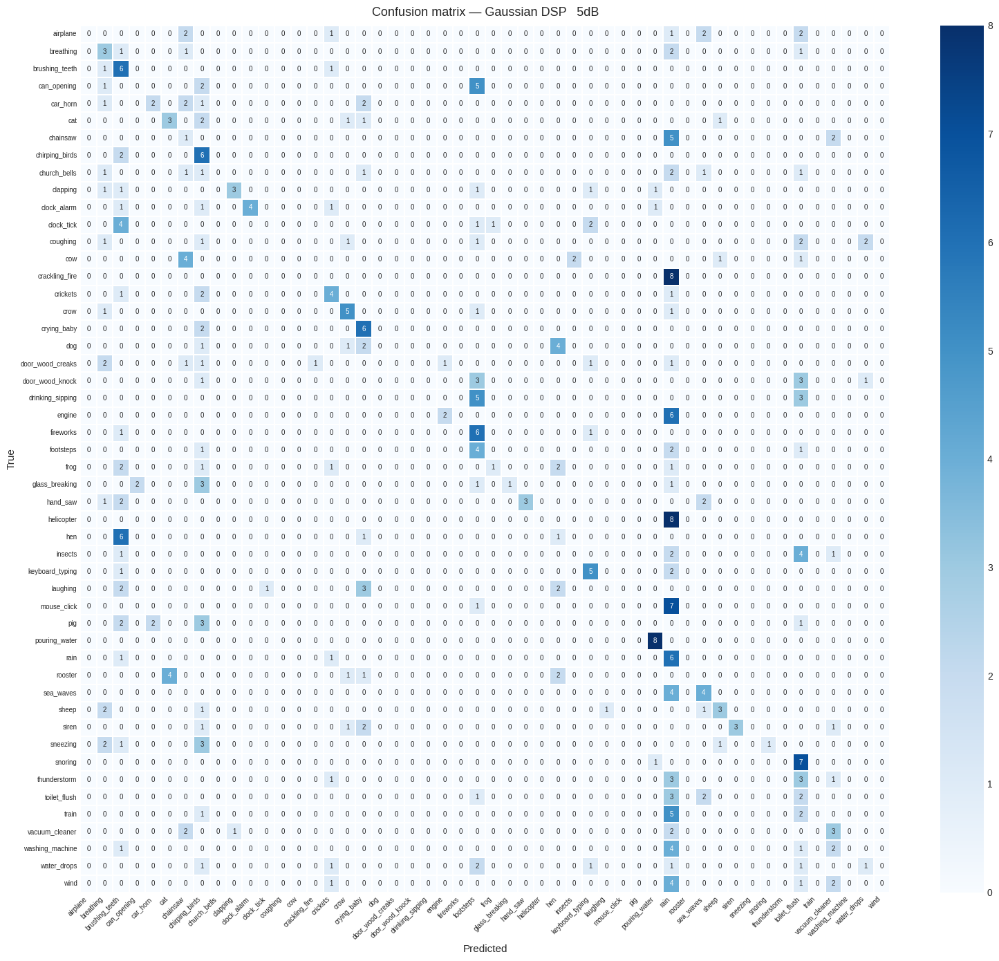

    5dB | Noisy: 16.2% → DSP: 22.5%

───────────────────────────────────────────────────────
  Gaussian Noisy 0dB   accuracy = 0.0950  (9.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.09      0.50      0.15         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.29      0.25      0.27         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.10      0.62      0.17         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.33      0.25      0.29         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.0

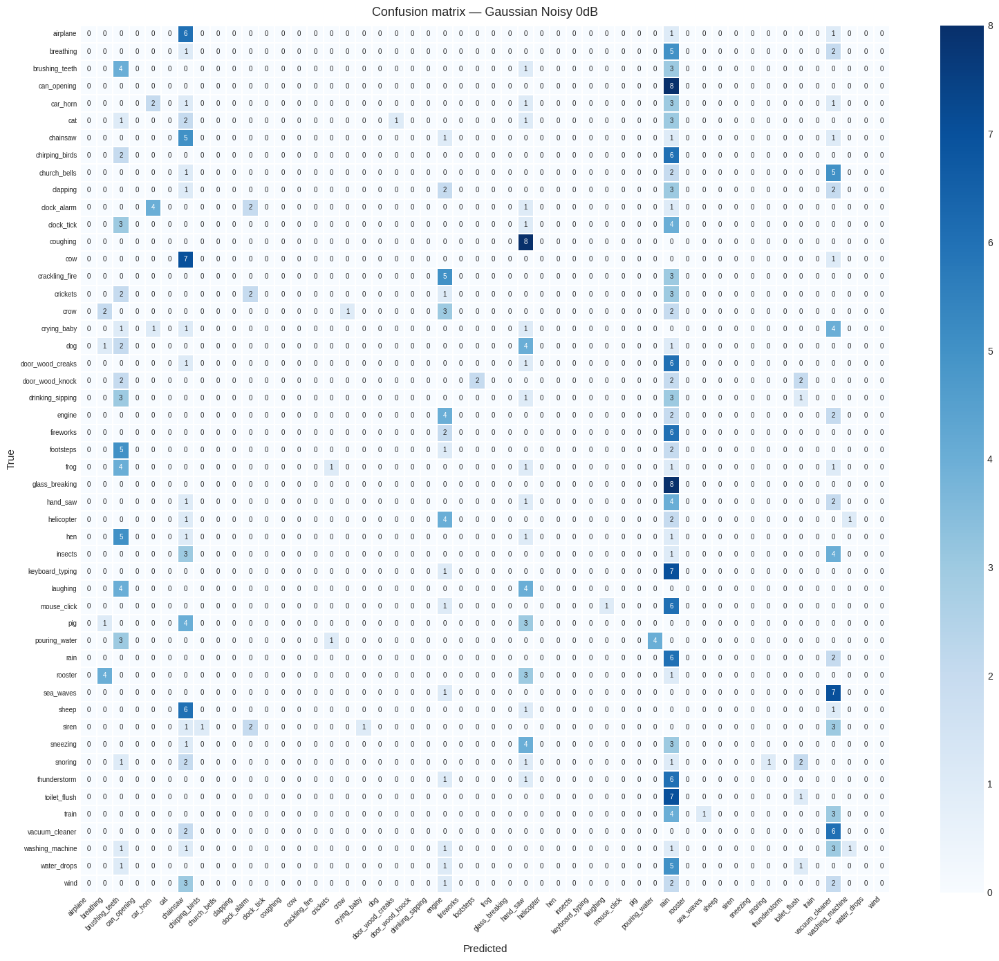


───────────────────────────────────────────────────────
  Gaussian DSP   0dB   accuracy = 0.1325  (13.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.15      0.25      0.19         8
  brushing_teeth       0.14      0.75      0.23         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.12      0.20         8
             cat       1.00      0.12      0.22         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.12      0.50      0.20         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.25      0.40         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       

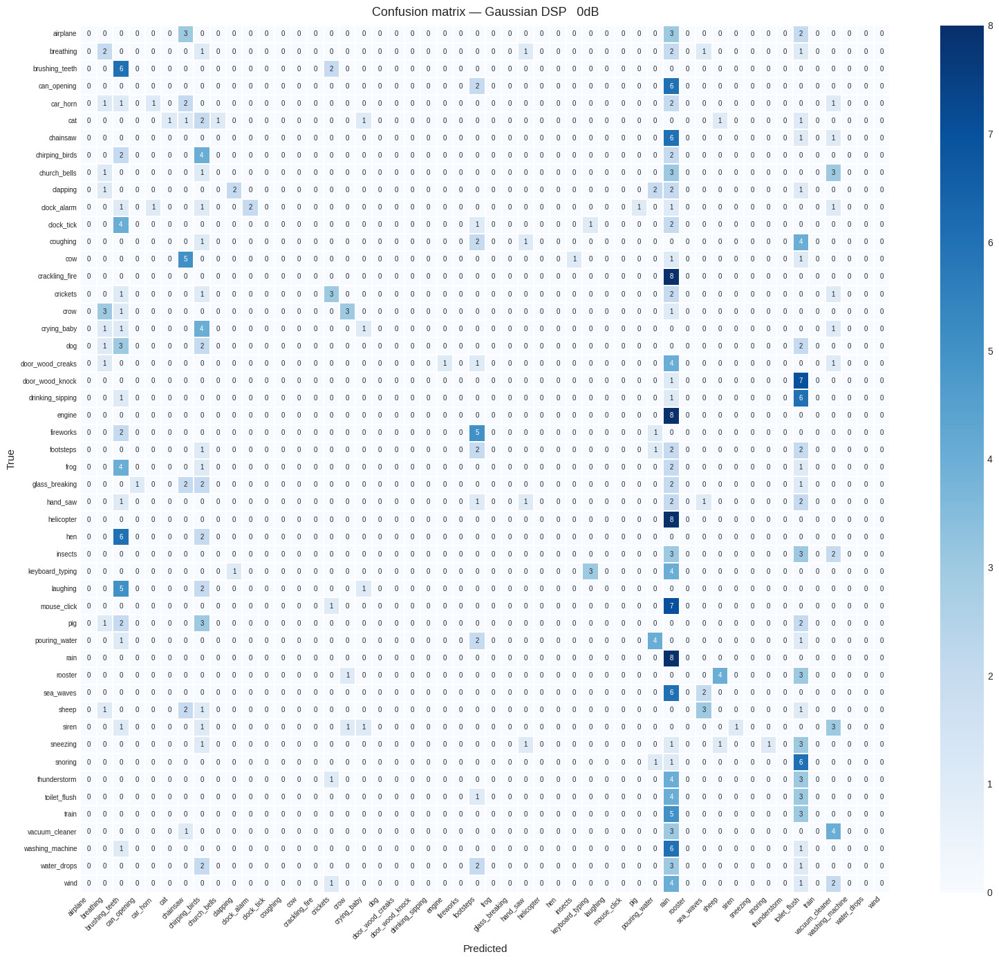

    0dB | Noisy: 9.5% → DSP: 13.2%

LOW SNR (Butterworth+SpectralSub):

───────────────────────────────────────────────────────
  LowSNR Noisy 0dB   accuracy = 0.1025  (10.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.12      0.62      0.20         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.33      0.38      0.35         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.08      0.50      0.14         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.50      0.50      0.50         8
      clock_tick       0.00      0.00      0.00         8
        coug

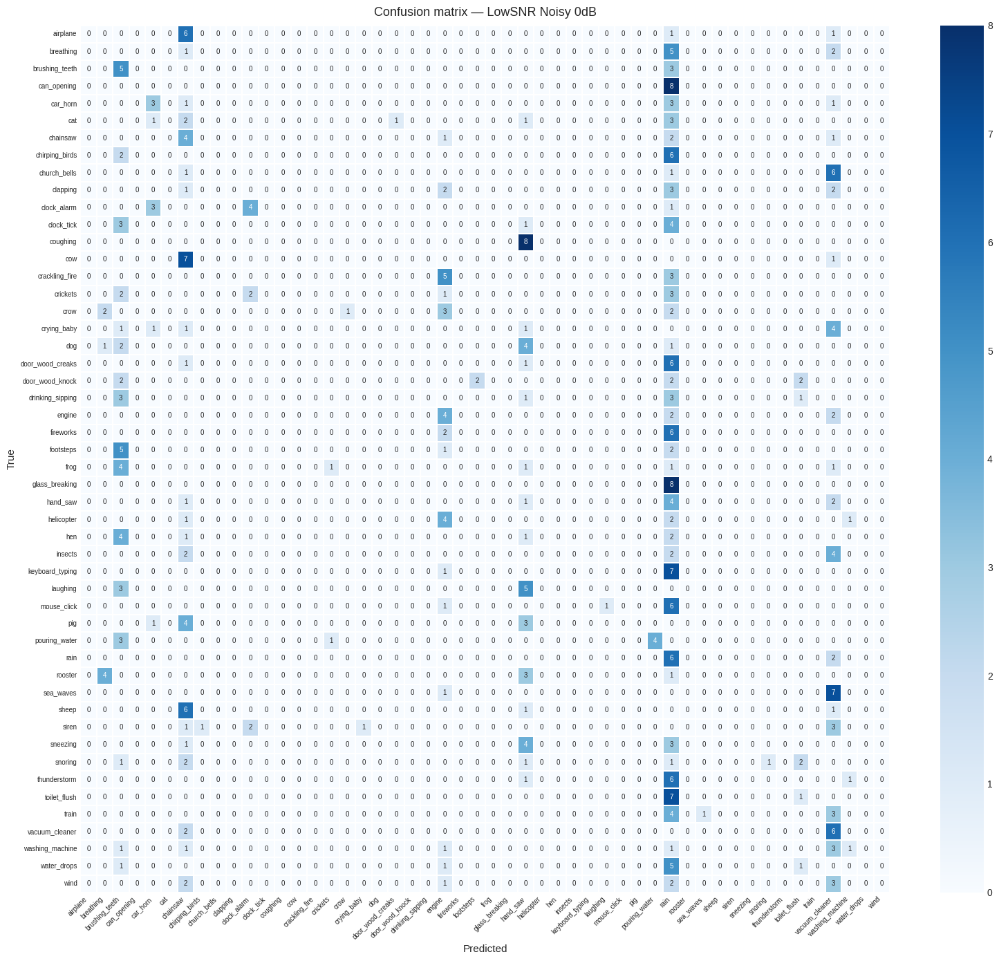


───────────────────────────────────────────────────────
  LowSNR DSP   0dB   accuracy = 0.1425  (14.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.14      0.25      0.18         8
  brushing_teeth       0.15      0.75      0.26         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.50      0.12      0.20         8
             cat       1.00      0.12      0.22         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.13      0.62      0.22         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.25      0.40         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0.

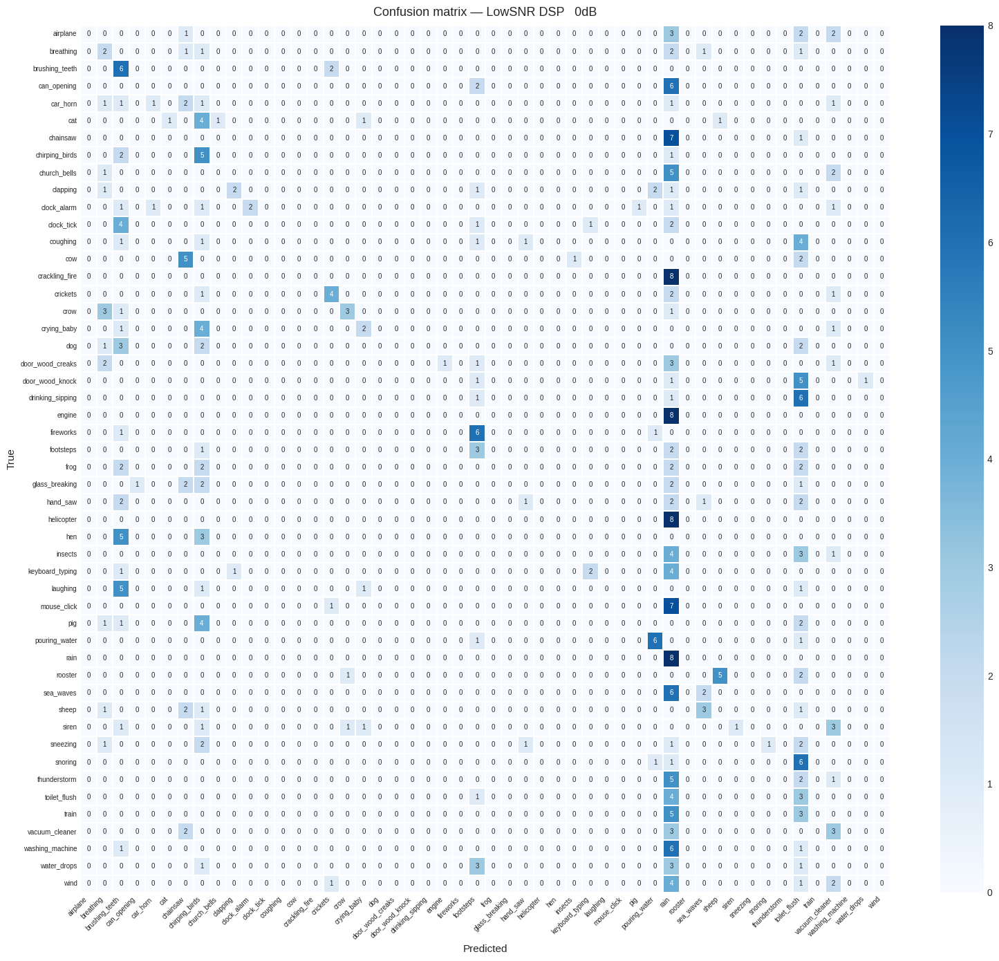

    0dB | Noisy: 10.2% → DSP: 14.2%

───────────────────────────────────────────────────────
  LowSNR Noisy -5dB   accuracy = 0.0650  (6.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.00      0.00      0.00         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.07      0.88      0.13         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00

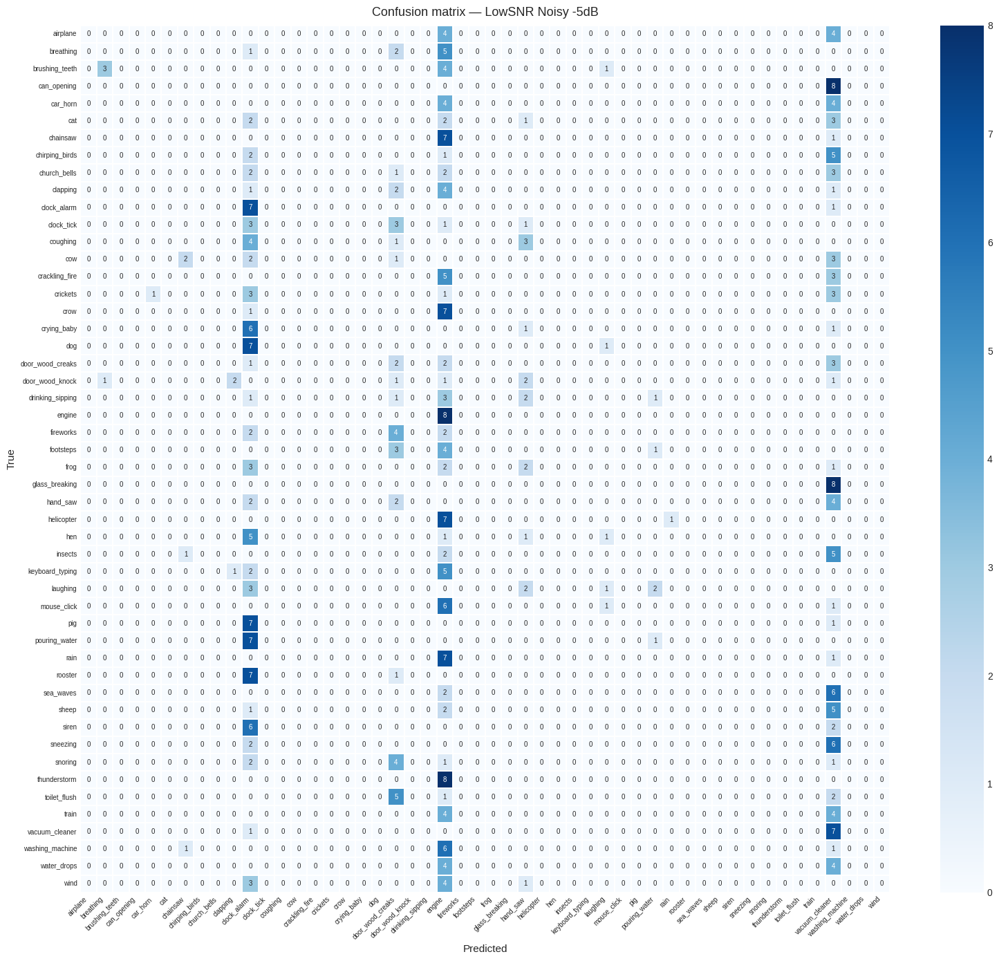


───────────────────────────────────────────────────────
  LowSNR DSP   -5dB   accuracy = 0.0425  (4.2 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.12      0.38      0.19         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.00      0.00      0.00         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0.

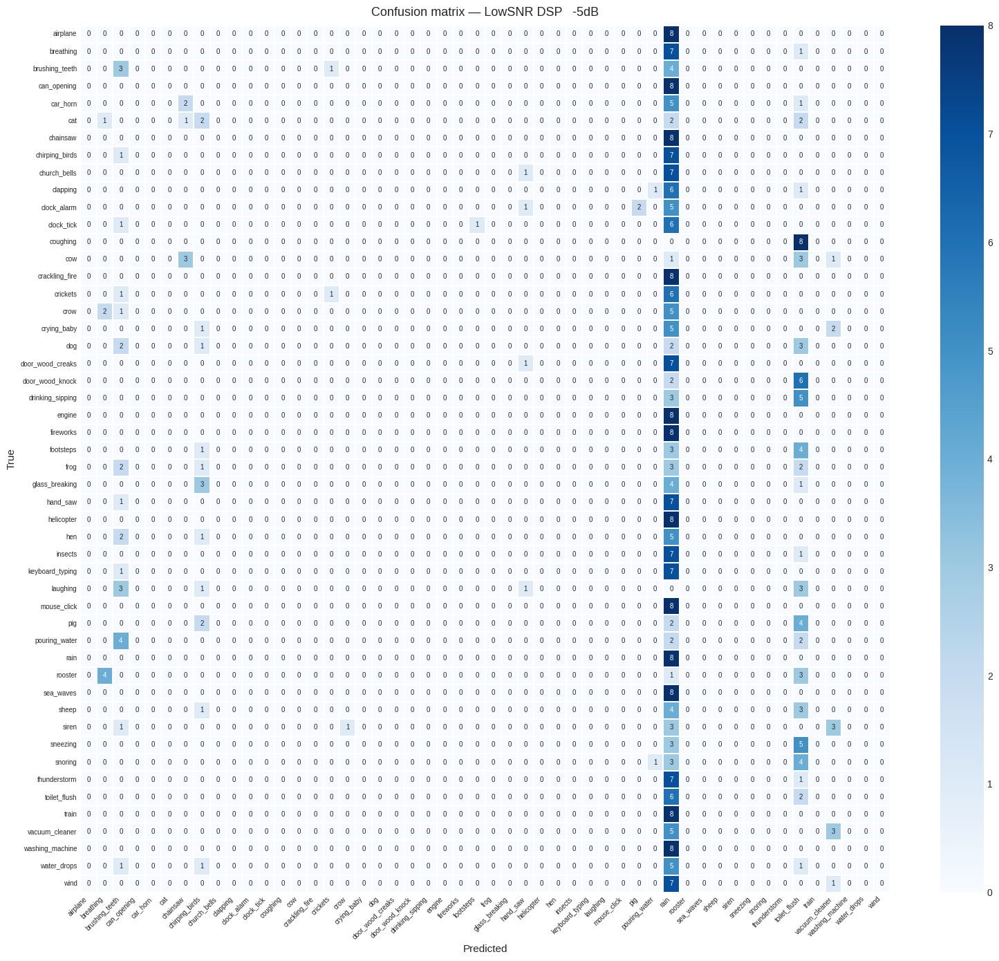

   -5dB | Noisy: 6.5% → DSP: 4.2%

───────────────────────────────────────────────────────
  LowSNR Noisy -10dB   accuracy = 0.0250  (2.5 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.00      0.00      0.00         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.02      1.00      0.04         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00 

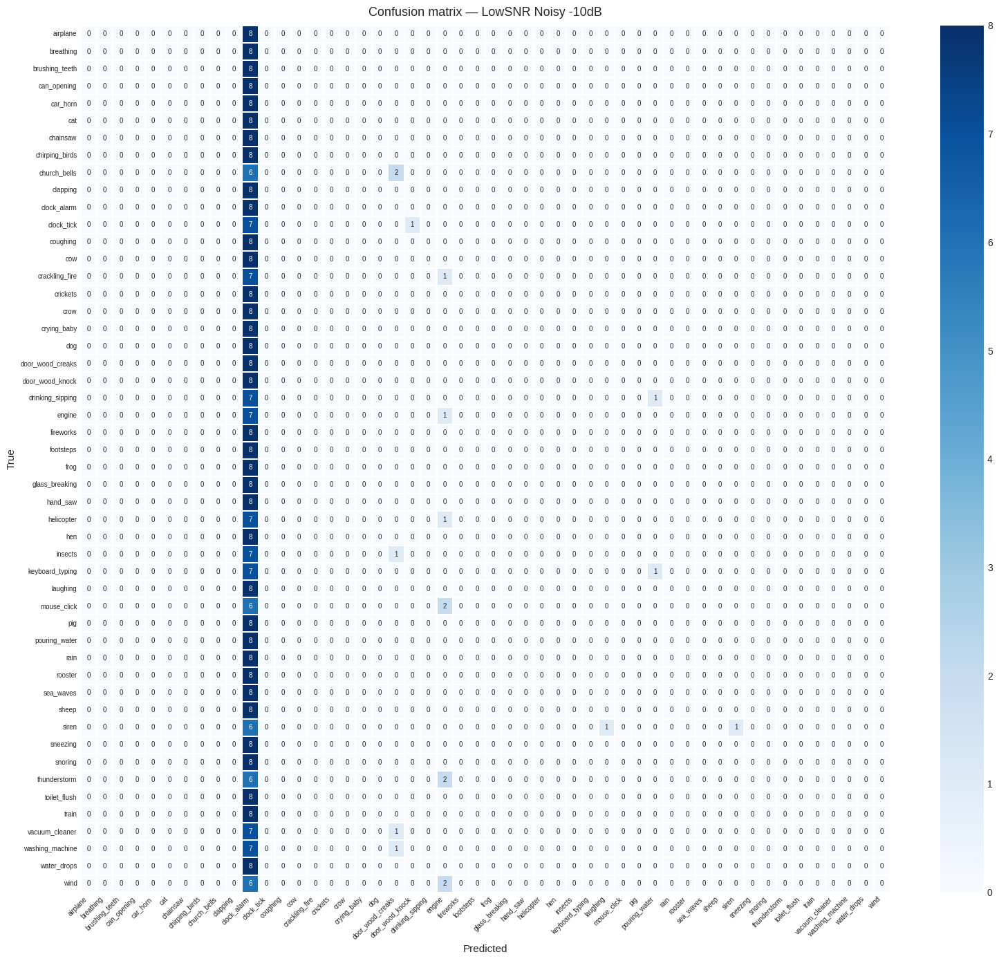


───────────────────────────────────────────────────────
  LowSNR DSP   -10dB   accuracy = 0.0200  (2.0 %)
───────────────────────────────────────────────────────
                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.00      0.00      0.00         8
     can_opening       0.00      0.00      0.00         8
        car_horn       0.00      0.00      0.00         8
             cat       0.00      0.00      0.00         8
        chainsaw       0.00      0.00      0.00         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       0.00      0.00      0.00         8
        clapping       0.00      0.00      0.00         8
     clock_alarm       0.00      0.00      0.00         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.00      0.00      0.00         8
             cow       0

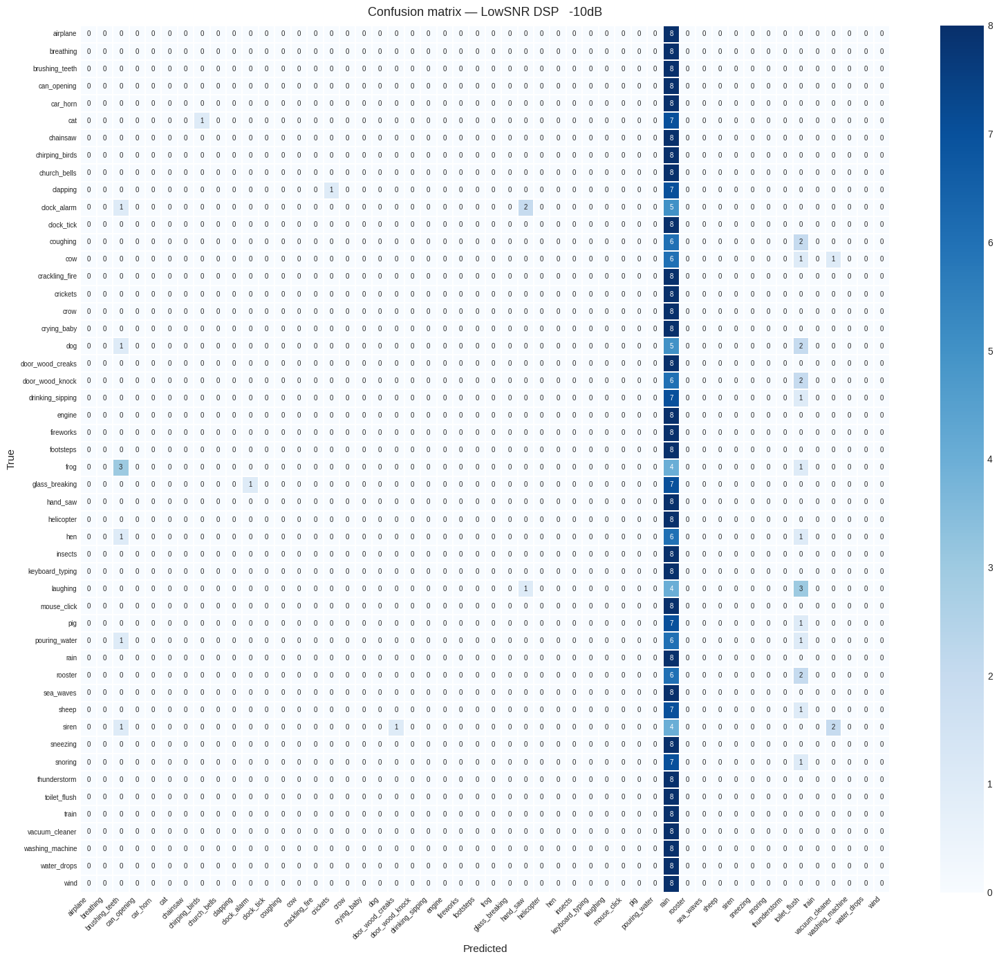

  -10dB | Noisy: 2.5% → DSP: 2.0%


In [ ]:
results_alt = {
    "white"    : {}, "white_dsp"    : {},
    "gaussian" : {}, "gaussian_dsp" : {},
    "low_snr"  : {}, "low_snr_dsp"  : {},
}

acc_clean = evaluate(final_model, X_test, y_test, "Clean")

print("\nWHITE NOISE (Butterworth+SpectralSub):")
for snr in WHITE_SNR_LEVELS:
    X_noisy    = add_white_noise(X_test, snr)
    X_denoised = dsp_pipeline_butterworth_spectral_sub(X_noisy)
    acc_n = evaluate(final_model, X_noisy,    y_test, f"White Noisy {snr}dB")
    acc_d = evaluate(final_model, X_denoised, y_test, f"White DSP   {snr}dB")
    results_alt["white"][snr]     = acc_n
    results_alt["white_dsp"][snr] = acc_d
    print(f"  {snr:>3}dB | Noisy: {acc_n*100:.1f}% → DSP: {acc_d*100:.1f}%")

print("\nGAUSSIAN NOISE (Butterworth+SpectralSub):")
for snr in GAUSSIAN_SNR_LEVELS:
    X_noisy    = add_gaussian_noise(X_test, snr)
    X_denoised = dsp_pipeline_butterworth_spectral_sub(X_noisy)
    acc_n = evaluate(final_model, X_noisy,    y_test, f"Gaussian Noisy {snr}dB")
    acc_d = evaluate(final_model, X_denoised, y_test, f"Gaussian DSP   {snr}dB")
    results_alt["gaussian"][snr]     = acc_n
    results_alt["gaussian_dsp"][snr] = acc_d
    print(f"  {snr:>3}dB | Noisy: {acc_n*100:.1f}% → DSP: {acc_d*100:.1f}%")

print("\nLOW SNR (Butterworth+SpectralSub):")
for snr in LOW_SNR_LEVELS:
    X_noisy    = add_low_snr(X_test, snr)
    X_denoised = dsp_pipeline_butterworth_spectral_sub(X_noisy)
    acc_n = evaluate(final_model, X_noisy,    y_test, f"LowSNR Noisy {snr}dB")
    acc_d = evaluate(final_model, X_denoised, y_test, f"LowSNR DSP   {snr}dB")
    results_alt["low_snr"][snr]     = acc_n
    results_alt["low_snr_dsp"][snr] = acc_d
    print(f"  {snr:>3}dB | Noisy: {acc_n*100:.1f}% → DSP: {acc_d*100:.1f}%")

Cell 18: PLOT results from butter worth + spectral subraction filter

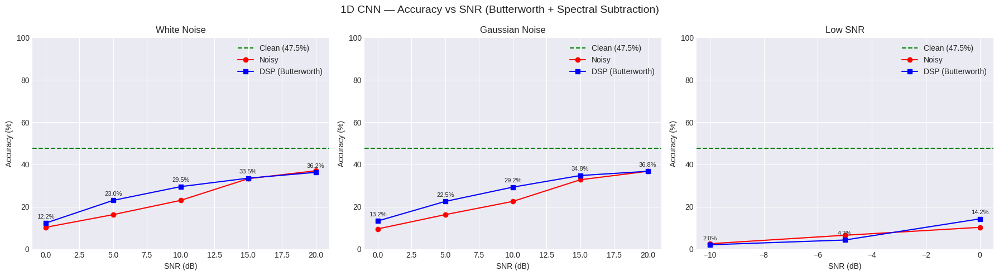

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("1D CNN — Accuracy vs SNR (Butterworth + Spectral Subtraction)", fontsize=14)

clean_acc = acc_clean * 100

# White Noise
ax = axes[0]
snrs = WHITE_SNR_LEVELS
ax.axhline(clean_acc, color='green', linestyle='--', label=f'Clean ({clean_acc:.1f}%)')
ax.plot(snrs, [results_alt["white"][s]*100 for s in snrs], 'r-o', label='Noisy')
ax.plot(snrs, [results_alt["white_dsp"][s]*100 for s in snrs], 'b-s', label='DSP (Butterworth)')
for s in snrs:
    ax.annotate(f"{results_alt['white_dsp'][s]*100:.1f}%", (s, results_alt['white_dsp'][s]*100), textcoords="offset points", xytext=(0,6), ha='center', fontsize=8)
ax.set_title("White Noise"); ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)"); ax.legend(); ax.set_ylim(0, 100)

# Gaussian Noise
ax = axes[1]
snrs = GAUSSIAN_SNR_LEVELS
ax.axhline(clean_acc, color='green', linestyle='--', label=f'Clean ({clean_acc:.1f}%)')
ax.plot(snrs, [results_alt["gaussian"][s]*100 for s in snrs], 'r-o', label='Noisy')
ax.plot(snrs, [results_alt["gaussian_dsp"][s]*100 for s in snrs], 'b-s', label='DSP (Butterworth)')
for s in snrs:
    ax.annotate(f"{results_alt['gaussian_dsp'][s]*100:.1f}%", (s, results_alt['gaussian_dsp'][s]*100), textcoords="offset points", xytext=(0,6), ha='center', fontsize=8)
ax.set_title("Gaussian Noise"); ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)"); ax.legend(); ax.set_ylim(0, 100)

# Low SNR
ax = axes[2]
snrs = LOW_SNR_LEVELS
ax.axhline(clean_acc, color='green', linestyle='--', label=f'Clean ({clean_acc:.1f}%)')
ax.plot(snrs, [results_alt["low_snr"][s]*100 for s in snrs], 'r-o', label='Noisy')
ax.plot(snrs, [results_alt["low_snr_dsp"][s]*100 for s in snrs], 'b-s', label='DSP (Butterworth)')
for s in snrs:
    ax.annotate(f"{results_alt['low_snr_dsp'][s]*100:.1f}%", (s, results_alt['low_snr_dsp'][s]*100), textcoords="offset points", xytext=(0,6), ha='center', fontsize=8)
ax.set_title("Low SNR"); ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Accuracy (%)"); ax.legend(); ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Trial DSP/butterworth_results.png", dpi=150, bbox_inches='tight')
plt.show()

Cell 19: COMPARE AND CONTRAST

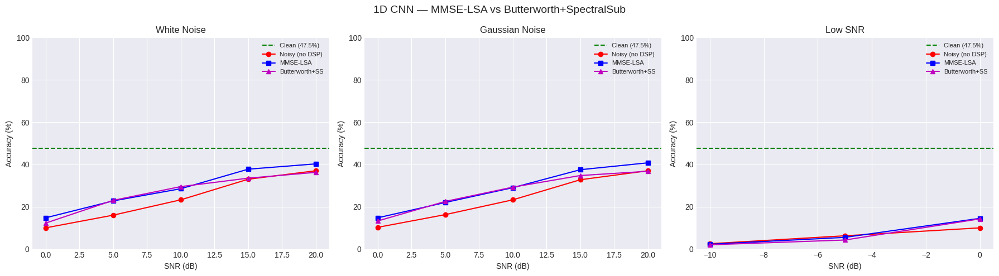


=== FILTER COMPARISON SUMMARY ===

White Noise:
  MMSE-LSA avg:        28.8%
  Butterworth+SS avg:  26.9%
  ✔ Winner: MMSE-LSA

Gaussian Noise:
  MMSE-LSA avg:        28.8%
  Butterworth+SS avg:  27.3%
  ✔ Winner: MMSE-LSA

Low SNR:
  MMSE-LSA avg:        7.4%
  Butterworth+SS avg:  6.8%
  ✔ Winner: MMSE-LSA


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("1D CNN — MMSE-LSA vs Butterworth+SpectralSub", fontsize=14)

noise_configs = [
    ("White Noise",    WHITE_SNR_LEVELS,    "white",    "white_dsp"),
    ("Gaussian Noise", GAUSSIAN_SNR_LEVELS, "gaussian", "gaussian_dsp"),
    ("Low SNR",        LOW_SNR_LEVELS,      "low_snr",  "low_snr_dsp"),
]

for ax, (title, snrs, noisy_key, dsp_key) in zip(axes, noise_configs):
    ax.axhline(clean_acc, color='green', linestyle='--', label=f'Clean ({clean_acc:.1f}%)')
    ax.plot(snrs, [results[noisy_key][s]*100 for s in snrs],     'r-o',  label='Noisy (no DSP)')
    ax.plot(snrs, [results[dsp_key][s]*100 for s in snrs],       'b-s',  label='MMSE-LSA')
    ax.plot(snrs, [results_alt[dsp_key][s]*100 for s in snrs],   'm-^',  label='Butterworth+SS')
    ax.set_title(title)
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Trial DSP/comparison_mmse_vs_butterworth.png", dpi=150, bbox_inches='tight')
plt.show()

# Print winner per condition
print("\n=== FILTER COMPARISON SUMMARY ===")
for title, snrs, _, dsp_key in noise_configs:
    print(f"\n{title}:")
    mmse_avg = np.mean([results[dsp_key][s]*100 for s in snrs])
    butt_avg = np.mean([results_alt[dsp_key][s]*100 for s in snrs])
    winner = "MMSE-LSA" if mmse_avg > butt_avg else "Butterworth+SS"
    print(f"  MMSE-LSA avg:        {mmse_avg:.1f}%")
    print(f"  Butterworth+SS avg:  {butt_avg:.1f}%")
    print(f"  ✔ Winner: {winner}")